In [3]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors as mcolors

from matplotlib.lines import Line2D


# Estilo seaborn para la figura
sns.set_style("whitegrid")
sns.set_context("talk")

In [4]:
# Que no haya límite en número de columnas
pd.set_option('display.max_columns', None)

# Ajustes opcionales para que no quiebre líneas
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Funciones

In [5]:
# Permite graficar tanto la eveluación en reconstruido como en latente
def plot_metric_grid_all(
        df_full,
        df_only_coreset,
        df_latent,
        df_latent_ft,
        df_TDColer=pd.DataFrame(),
        spaces=('original', 'latent'),
        max_ipc=100,
        metric='test_balanced',
        methods=('k-means', 'k-center', 'ag'),
        models=None,
        x_label='Instances Per Class',
        y_label='Test balanced',
        name_savefig='figura.png'
    ):
    """
    Grid dinámico metric vs IPC:
      • Filas → cada modelo de `models`.
      • Columnas → bloques por espacio (cada bloque = len(methods) columnas).
    Fondo de cada bloque coloreado según espacio (original / latent).
    Dentro de cada celda:
      - Curvas media±std de cada técnica (Original, CorVAE, TDColer).
      - Línea base full-data.
      - Cuadro con valor Full-data y máximo de CorVAE.
    """

    

    # 1) Unir DataFrames con columna 'space' y 'technique'
    df_list = []
    for space in spaces:
        d_latent = df_latent[df_latent['space'] == space]
        d_tdcol  = df_TDColer[df_TDColer['space'] == space] if not df_TDColer.empty else pd.DataFrame()
        for src, tech in [
            (df_only_coreset, 'Original'),
            (d_latent,       'CorVAE'),
            #(df_latent_ft,  'latent_ft'),
            (d_tdcol,        'TDColer'),
        ]:
            if src.empty:
                continue
            tmp = src.copy()
            tmp['technique'] = tech
            tmp['space']     = space
            df_list.append(tmp)

    df_all = pd.concat(df_list, ignore_index=True)
    df_all = df_all[df_all['IPC'] <= max_ipc]

    # 2) Preparo figura y ejes
    n_rows = len(models)
    n_cols = len(spaces) * len(methods)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4*n_cols, 3*n_rows),
        sharex=True, sharey=True
    )
    axes = np.array(axes).reshape(n_rows, n_cols)

    # Paleta fija para líneas
    tech_colors = {
        'Original': 'C0',
        'CorVAE':   'C2',
        'TDColer':  'C4',
    }
    baseline_color = 'gray'

    # Paleta pastel para fondos de espacios
    bg_palette = sns.color_palette("pastel", len(spaces))
    bg_colors  = dict(zip(spaces, bg_palette))

    remap1 = {
        'k-means':  'KM',
        'k-center': 'K-Centers',
        'ag':       'AG',
        'lc':      'LC',
    }

    remap2 = {
        'logreg': 'LR',
        'svc':    'SVC',
        'rf':     'RF',
        'xgb':    'XGBoost',
        'naive_bayes':   'NB',
        'mlp':   'MLP',
        'knn':  'KNN',
        
    }

    # 3) Rellenar cada subplot
    for i, model in enumerate(models):
        for k, space in enumerate(spaces):
            for j, method in enumerate(methods):
                col = k * len(methods) + j
                ax = axes[i, col]

                # Sombreado de fondo según espacio
                rgba = mcolors.to_rgba(bg_colors[space], alpha=0.1)
                ax.set_facecolor(rgba)

                sub = df_all[
                    (df_all['model']  == model) &
                    (df_all['method'] == method) &
                    (df_all['space']  == space)
                ]
                if sub.empty:
                    ax.set_visible(False)
                    continue

                ax.set_title(f"{remap2[model]} – {remap1[method]}", loc='left', pad=6)

                # Dibujar curvas y calcular máximo de CorVAE
                corvae_max_val = None
                corvae_max_ipc = None
                for tech, color in tech_colors.items():
                    sp = sub[sub['technique'] == tech]
                    if sp.empty:
                        continue
                    #print(sp)
                    grp = sp.groupby('IPC')[metric].agg(['mean','std']).reset_index()
                    ax.plot(grp['IPC'], grp['mean'],
                            marker='o', label=tech, color=color)
                    ax.fill_between(
                        grp['IPC'],
                        grp['mean'] - grp['std'],
                        grp['mean'] + grp['std'],
                        alpha=0.2, color=color
                    )
                    # si es CorVAE, calcular su máximo
                    if tech == 'CorVAE':
                        idx = grp['mean'].idxmax()
                        corvae_max_val = grp.at[idx, 'mean']
                        corvae_max_ipc = grp.at[idx, 'IPC']

                # Línea base full-data
                baseline = df_full[df_full['model'] == model][metric].mean()
                ax.axhline(y=baseline,
                           linestyle='--',
                           color=baseline_color,
                           label='Full-data')

                ax.grid(True, linestyle='--', alpha=0.5)
                ax.set_xlim(0, max_ipc)

    fig.supxlabel(x_label, fontsize=14)
    fig.supylabel(y_label, fontsize=14, rotation='vertical', x=0.02)


    legend_elements = [
        Line2D([0], [0], marker='o', color=tech_colors['Original'], label='Original'),
        Line2D([0], [0], marker='o', color=tech_colors['CorVAE'],   label='CorVAE'),
        Line2D([0], [0], linestyle='--', color=baseline_color,      label='Full-data'),
    ]

    if 'TDColer' in df_all['technique'].unique():
        legend_elements.append(
            Line2D([0], [0], marker='o', color=tech_colors['TDColer'], label='TDColer')
        )

    fig.legend(
        handles=legend_elements,
        loc='upper center',
        ncol=len(legend_elements),
        #title='Técnica',
        bbox_to_anchor=(0.5, 1.03),  # sube un poco más la leyenda
        fontsize=12,
        title_fontsize=13
    )

    # Ajustar layout para no solapar
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # más espacio arriba
    plt.savefig(name_savefig, dpi=300, bbox_inches='tight')
    plt.show()


In [6]:
# Permite solo graficar la evaluacion en uno de los dos espacios
def plot_metric_grid(df_random,
                     df_original,
                     df_latent,
                     df_latent_ft,
                     space='original',
                     max_ipc=100,
                     metric='test_balanced',
                     x_label='Instances Per Class',
                     y_label='Test balanced',
                     methods=['k-means',
                              'k-center',
                              'ag'
                              ]):
    """
    Dibuja en una única figura (grid) la curva de `metric` vs IPC
    para cada combinación (método, modelo).  
    Filas → modelos, Columnas → métodos.  
    Dentro de cada celda: las tres técnicas de distilación
    (original, latent, latent_ft) con media ± std, y línea base Full-data.
    """

    df_latent = df_latent[df_latent['space'] == space]
    df_latent_ft = df_latent_ft[df_latent_ft['space'] == space]

    # 1) Concatena solo los tres DataFrames de distilación
    dfs = [
        (df_original.copy(),  'original'),
        (df_latent.copy(),    'latent'),
        (df_latent_ft.copy(), 'latent_ft'),
    ]
    df_list = []
    for df, tech in dfs:
        df['technique'] = tech
        df_list.append(df)
    df_all_init = pd.concat(df_list, ignore_index=True)

    df_all = df_all_init[df_all_init['IPC'] <= max_ipc]

    # 3) Métodos y modelos para el grid
    #methods = sorted([m for m in df_all['method'].unique()
    #                  if m not in ['random', 'Full-data']])
    models  = sorted(df_all['model'].unique())

    # Swap: filas = modelos, columnas = métodos
    n_rows, n_cols = len(models), len(methods)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4*n_cols, 3*n_rows),
                             sharex=True, sharey=True)

    # 4) Paleta para las tres técnicas
    palette = {
        'original':  'C0',
        'latent':    'C2',
        'latent_ft': 'C3',
        'TDColer':   'C4',
    }

    # 5) Rellenar cada celda
    for i, model in enumerate(models):
        for j, method in enumerate(methods):
            ax = axes[i, j] if n_rows > 1 and n_cols > 1 else (
                 axes[j] if n_rows == 1 else axes[i])
            
            

            sub = df_all[
                (df_all['method'] == method) &
                (df_all['model']  == model)
            ]
            if sub.empty:
                ax.set_visible(False)
                continue

            # Título interno de cada subplot
            ax.set_title(f"{model} – {method}", loc='left', pad=10)

            # Dibujar las curvas de cada técnica
            for tech, color in palette.items():
                sp = sub[sub['technique'] == tech]
                if sp.empty:
                    continue
                grp = (sp
                       .groupby('IPC')[metric]
                       .agg(['mean', 'std'])
                       .reset_index())
                ax.plot(grp['IPC'], grp['mean'],
                        marker='o', label=tech, color=color)
                ax.fill_between(
                    grp['IPC'],
                    grp['mean'] - grp['std'],
                    grp['mean'] + grp['std'],
                    alpha=0.2, color=color
                )

            # Línea base para 'Full-data'
            baseline_df = df_all_init[
                (df_all_init['method'] == 'Full-data') &
                (df_all_init['model']  == model)
            ]
            if not baseline_df.empty:
                baseline_val = baseline_df[metric].mean()
                ax.axhline(
                    y=baseline_val,
                    linestyle='--',
                    color='gray',
                    label='Full-data'
                )

            ax.grid(True, linestyle='--', alpha=0.5)
            ax.set_xlim(0, max_ipc)

    # 6) Etiquetas globales de ejes
    # Para Matplotlib >= 3.4 puedes usar:
    fig.supxlabel(x_label, fontsize=14)
    fig.supylabel(y_label, fontsize=14, rotation='vertical', x=0)

    # 7) Leyenda común arriba
    # Tomamos los handles/labels del último ax válido
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='upper center', ncol=len(palette)+1,
               title="Técnica")
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [7]:
import sys
# Insertamos al principio para que tenga prioridad
sys.path.insert(0, 'utils')

from sklearn.metrics import silhouette_score
import tqdm
from distill import (
    distill_with_agglomerative,
    distill_with_kcenters,
    distill_least_confidence,
    distill_with_kmeans
    
)

def plot_silhouette_vs_ipc_all_methods(
    X_original: np.ndarray,
    y:           np.ndarray,
    ipc_values:  list[int] = list(range(10, 101, 10)),
    seeds:       list[int] = [5, 6, 7, 8, 9],
    model=None,           # solo para LC
    flat:        bool = True,
    figname = None,
    z_root_path: str ='results/checkpoint/checkpoint_shoppers_Dlatent_ft_F/vae',
):
    """
    Traza en una figura 2×2 la Silhouette vs IPC para:
      - AG  (Agglomerative)
      - K-Centers
      - LC  (Least Confidence)
      - KM  (KMeans-based distillation)
    """

    methods = ['AG', 'K-Centers', 'LC', 'KM']
    n_meth, n_seeds, n_ipc = len(methods), len(seeds), len(ipc_values)

    # Resultados: [método, seed, ipc]
    sil_orig = np.zeros((n_meth, n_seeds, n_ipc))
    sil_lat  = np.zeros_like(sil_orig)

    # --- Cálculo de Silhouette por método / semilla / IPC ---
    for m_idx, method in enumerate(methods):
        for i, seed in enumerate(seeds):
            # carga y prepara latente
            Z = np.load(f'{z_root_path}/train_z_seed_{seed}.npy')
            if flat and Z.ndim == 3:
                n, t, d = Z.shape
                Z = Z.reshape(n, t * d)
            elif not flat and Z.ndim == 3:
                Z = Z[:, 0, :]
            # else, Z ya es 2D

            for j, ipc in enumerate(tqdm.tqdm(ipc_values, desc=f'{method} seed {seed}')):
                if method == 'AG':
                    Xo, yo = distill_with_agglomerative(  X_original, y, num_clusters=ipc, seed=seed)
                    Xl, yl = distill_with_agglomerative(       Z, y, num_clusters=ipc, seed=seed)

                elif method == 'K-Centers':
                    Xo, yo = distill_with_kcenters(  X_original, y, num_centroids=ipc, seed=seed)
                    Xl, yl = distill_with_kcenters(       Z, y, num_centroids=ipc, seed=seed)

                elif method == 'LC':
                    Xo, yo = distill_least_confidence(  X_original, y, num_samples=ipc, model=model, seed=seed)
                    Xl, yl = distill_least_confidence(       Z, y, num_samples=ipc, model=model, seed=seed)

                elif method == 'KM':
                    Xo, yo = distill_with_kmeans(  X_original, y, num_centroids=ipc, seed=seed)
                    Xl, yl = distill_with_kmeans(       Z, y, num_centroids=ipc, seed=seed)

                else:
                    raise ValueError(f"Método desconocido: {method!r}")

                # silhouette_score exige ≥2 clusters
                sil_orig[m_idx, i, j] = (
                    silhouette_score(Xo, yo)
                    if len(np.unique(yo)) > 1 else np.nan
                )
                sil_lat[m_idx, i, j] = (
                    silhouette_score(Xl, yl)
                    if len(np.unique(yl)) > 1 else np.nan
                )

    # --- Estadísticos sobre semillas ---
    mean_orig = np.nanmean(sil_orig, axis=1)  # [método, ipc]
    std_orig  = np.nanstd( sil_orig, axis=1)
    mean_lat  = np.nanmean(sil_lat,  axis=1)
    std_lat   = np.nanstd( sil_lat,  axis=1)

    # --- Dibujar los 4 subplots ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Puntaje de silueta', fontsize=16)

    for m_idx, method in enumerate(methods):
        ax = axes.flat[m_idx]

        # Original
        ax.plot(ipc_values, mean_orig[m_idx], marker='o', label='Original')
        ax.fill_between(
            ipc_values,
            mean_orig[m_idx] - std_orig[m_idx],
            mean_orig[m_idx] + std_orig[m_idx],
            alpha=0.2
        )

        # Latente
        ax.plot(ipc_values, mean_lat[m_idx], marker='o', label='Latente')
        ax.fill_between(
            ipc_values,
            mean_lat[m_idx] - std_lat[m_idx],
            mean_lat[m_idx] + std_lat[m_idx],
            alpha=0.2
        )

        ax.set_title(method)
        if m_idx in (2, 3):
            ax.set_xlabel('IPC')
        if m_idx in (0, 2):
            ax.set_ylabel('Silueta')

        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # deja espacio para el suptitle

    if figname:
        plt.savefig(figname)
    plt.show()

/mnt/d/home-2/Documentos/master/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
from sklearn.metrics import pairwise_distances
from utils import reconstruct_data, load_reconstructed_data  
import json
from sklearn.manifold import TSNE

def plot_kmeans_distill_and_reconstruct_tsne_seaborn(
    X_original: np.ndarray,
    Z:            np.ndarray,
    y:            np.ndarray,
    ipc:          int,
    seed:         int,
    metadata_path: str,
    vae_dir:       str,
    device:        str,
    num_scaler,
    cat_encoder,
    label_encoder,
    concat_label:  bool,
    hyperparams_vae_path: str,
    figname:       str = None,
    method=None
):
    """
    - Distilla con KMeans(ipc) por clase en original y latente.
    - Reconstruye las muestras latentes seleccionadas al espacio original.
    - Aplica t-SNE a [X_original; Xo; X_rec].
    - Grafica con seaborn:
      • Puntos originales (suaves rojo/azul, alpha bajo).
      • Centroides originales (marker 'X', verde/green-yellow).
      • Reconstruidas (marker 'P', turquesa/violeta).
      • Leyenda separada para clases y para tipos de puntos.
    """

    if method == 'AG':
        Xo, yo = distill_with_agglomerative(  X_original, y, num_clusters=ipc, seed=seed)
        distill_z, distill_y = distill_with_agglomerative(Z, y, num_clusters=ipc, seed=seed)
    if method == 'KM':
        # 1) Distilación Original
        Xo, yo = distill_with_kmeans(
            X_original, y, num_centroids=ipc, seed=seed, get_closest=False
        )
        # 2) Distilación Latente
        distill_z, distill_y = distill_with_kmeans(
            Z, y, num_centroids=ipc, seed=seed, get_closest=False
        )
    elif method == 'K-Centers':
        Xo, yo = distill_with_kcenters(  X_original, y, num_centroids=ipc, seed=seed)
        distill_z, distill_y = distill_with_kcenters(       Z, y, num_centroids=ipc, seed=seed)

    elif method == 'LC':
        Xo, yo = distill_least_confidence(  X_original, y, num_samples=ipc, model=None, seed=seed)
        distill_z, distill_y = distill_least_confidence(       Z, y, num_samples=ipc, model=None, seed=seed)

    # 3) Cargar hiperparámetros VAE
    with open(hyperparams_vae_path, 'r', encoding='utf-8') as f:
        hyperparams_vae = json.load(f)['best_params']
    # 4) Reconstruir latente → original
    df_recon, _ = reconstruct_data(
        distill_z, distill_y,
        models_paths=vae_dir, device=device,
        json_config_path=metadata_path,
        latent_space=True, hyperparams=hyperparams_vae,
        method='k-means', ipc=ipc,
        concat_label=concat_label, seed=seed
    )
    X_rec, y_rec = load_reconstructed_data(
        df_recon, metadata_path,
        num_scaler=num_scaler,
        cat_encoder=cat_encoder,
        label_encoder=label_encoder
    )
    # 5) TSNE sobre combinado
    X_comb = np.vstack([X_original, Xo, X_rec])
    tsne = TSNE(n_components=2, random_state=seed)
    emb = tsne.fit_transform(X_comb)
    n = X_original.shape[0]
    m = Xo.shape[0]
    emb_orig = emb[:n]
    emb_o    = emb[n:n+m]
    emb_rec  = emb[n+m:]
    # 6) Paletas
    palette_cls = {0: 'deepskyblue', 1: 'darkgreen'}
    palette_o   = {0: 'darkblue', 1: 'purple'}
    palette_r   = {0: 'hotpink', 1: 'darkorange'}
    # 7) Plot
    sns.set_style('white')
    fig, ax = plt.subplots(figsize=(8, 6))
    # Original: suavizado
    sns.scatterplot(
        x=emb_orig[:,0], y=emb_orig[:,1],
        hue=y, palette=palette_cls,
        legend='brief', alpha=0.3, s=15, ax=ax
    )
    # Capturar leyenda de clases
    handles_cls, labels_cls = ax.get_legend_handles_labels()

        # Reconstruidas
    for cls in np.unique(y_rec):
        idx_cls = np.where(y_rec == cls)[0]
        ax.scatter(
            emb_rec[idx_cls,0], emb_rec[idx_cls,1],
            marker='o', s=80,
            edgecolors=palette_r[cls],          # borde rojo
    linewidths=3, 
            label=f'Recons {cls}'
        )
    
    # Centroides originales
    for cls in np.unique(yo):
        idx_cls = np.where(yo == cls)[0]
        ax.scatter(
            emb_o[idx_cls,0], emb_o[idx_cls,1],
            marker='X',
            s=80,
            #c=palette_o[cls],
            linewidths=0.5,              # grosor de línea más fino
            edgecolors=palette_o[cls],   # asegúrate que se dibuje el borde
            label=f'Orig {cls}'
        )

    # Leyendas separadas
    leg1 = ax.legend(handles=handles_cls, labels=labels_cls,
                     title='Clase', loc='upper left')
    # Obtener solo los handles de centroides y reconstruidas
    handles2, labels2 = [], []
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if 'Orig' in label or 'Recon' in label:
            handles2.append(handle)
            labels2.append(label)
    leg2 = ax.legend(handles=handles2, labels=labels2,
                     title='Tipo de punto', loc='upper right')
    ax.add_artist(leg1)
    ax.set_title(f't-SNE - {method} (IPC={ipc})')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.grid(False)
    plt.tight_layout()
    if figname:
        plt.savefig(figname)
        print(f'Figura guardada en: {figname}')
    plt.show()

In [9]:
def load_latent(seed, flat, z_root_path, cls=False):
    Z = np.load(f'{z_root_path}/train_z_seed_{seed}.npy')
    if flat and Z.ndim == 3:
        n, t, d = Z.shape
        return Z.reshape(n, t * d)
    elif cls:
        return Z[:, 0, :]
    else:
        return Z



In [10]:
# Funciones para renombrar y adecuar los nombres de los 
# resultados de TDCoLER

def rename_rows(df, column, mapping):
    """
    Renombra las filas de un DataFrame para que coincidan con el método.
    """
    df = df.copy()

    # Aplicamos el cambio en el DataFrame
    df[column] = (df[column]
                .replace(mapping)                # reemplaza los que estén en el dict
                #.str.lower()                     # opcional: pasar todo a minúsculas
                )
    return df

def preprocess_baseline(df):
    df = df[['Classifier','Encoder','Data Parse Mode','Distill Method','Distill Space',
             'Output Space','Convert Binary','Cluster Center','N','Score']]
    
    mapping_classifier = {
        'XGBClassifier':       'xgb',
        'MLPClassifier':  'mlp',
        'KNeighborsClassifier':'knn',
        'GaussianNB': 'naive_bayes',
        'LogisticRegression': 'logreg',
    }

    mapping_method = {
        'KMeans':       'k-means',
        'Agglo':  'ag',
    }

    mapping_space = {
        'decoded':       'original',
        'encoded':  'latent',

    }

    df = rename_rows(df, 'Classifier', mapping_classifier)
    df = rename_rows(df, 'Distill Method', mapping_method)
    df = rename_rows(df, 'Output Space', mapping_space)

    df.rename(columns={'N': 'IPC',
                       'Distill Method':'method',
                       'Classifier':'model',
                       'Score':'test_balanced',
                       'Output Space':'space'
                       
                       }, inplace=True)

    df_full = df[
                        (df['Data Parse Mode'] == 'mixed') &
                        (df['method'] == 'Original') &
                        (df['Convert Binary'] == False)
                    ]
    
    df_only_coreset = df[
                        (df['method'].isin(['k-means', 'ag'])) &
                        (df['Distill Space'] == 'original') &
                        (df['space'] == 'original') &
                        (df['Convert Binary'] == False) &
                        (df['Cluster Center'] == 'centroid') 
                    ]
                    
    df_latent = df[
                        (df['method'].isin(['k-means', 'ag'])) &
                        (df['Distill Space'] == 'encoded') &
                        (df['Convert Binary'] == False) &
                        (df['Encoder'] == 'TF')
                    ]
    df_latent_ft = df[
                        (df['method'].isin(['k-means', 'ag'])) &
                        (df['Distill Space'] == 'encoded') &
                        (df['Convert Binary'] == False) &
                        (df['Encoder'] == 'TF-MultiHead')
                    ]

    df_full = df_full[['model','method','IPC','test_balanced','space']]
    df_only_coreset = df_only_coreset[['model','method','IPC','test_balanced','space']]
    df_latent = df_latent[['model','method','IPC','test_balanced','space']]
    df_latent_ft = df_latent_ft[['model','method','IPC','test_balanced', 'space']]

    return df_full,df_only_coreset,df_latent, df_latent_ft

In [11]:
# Contruiccion de la tabla de resumen para un IPC especifico
def summarize_two_metrics(
    ipc: float,
    df_only_coreset: pd.DataFrame,
    df_latent: pd.DataFrame,
    df_tdcoler: pd.DataFrame,
    df_latent_ft: pd.DataFrame = None
) -> pd.DataFrame:
    """
    Construye una tabla resumen con las métricas test_balanced y test_roc_auc,
    filtrando por un valor específico de IPC y combinando varias técnicas.

    La salida es un DataFrame con índices (technique, space, model) y
    columnas multiíndice donde el primer nivel es la métrica
    (test_balanced a la izquierda, test_roc_auc a la derecha) y
    el segundo nivel los métodos ('KM','AG','K-center','LC').
    """
    # 0) Combinar DataFrames de las técnicas
    df_list = []
    # Only-Coreset (original)
    tmp = df_only_coreset.copy()
    tmp['technique'] = 'Only-Coreset'
    tmp['space']     = 'original'
    df_list.append(tmp)
    # CorVAE reconstruido
    tmp = df_latent.copy()
    tmp['technique'] = 'CorVAE-recon'
    df_list.append(tmp)
    # CorVAE fine-tuned (opcional)
    if df_latent_ft is not None and not df_latent_ft.empty:
        tmp = df_latent_ft.copy()
        tmp['technique'] = 'CorVAE-latent'
        df_list.append(tmp)
    # TDColer
    if not df_tdcoler.empty:
        tmp = df_tdcoler.copy()
        tmp['technique'] = 'TDColer'
        df_list.append(tmp)
    df_all = pd.concat(df_list, ignore_index=True)
    # Filtrar métodos y modelos no deseados
    df_all = df_all[~df_all['method'].isin(['craig', 'random'])]
    df_all = df_all[df_all['model'] != 'knn']
    # Filtrar por IPC
    df_ipc = df_all[df_all['IPC'] == ipc]

    # Función auxiliar para pivotar una métrica
    def pivot_metric(df: pd.DataFrame, metric: str) -> pd.DataFrame:
        stats = (
            df
            .groupby(['technique','space','model','method'])[metric]
            .agg(mean='mean', std='std')
            .reset_index()
        )
        stats['fmt'] = stats.apply(
            lambda r: f"{r['mean']:.3f}±{r['std']:.3f}", axis=1
        )
        table = (
            stats
            .pivot_table(
                index=['technique','space','model'],
                columns='method',
                values='fmt',
                aggfunc='first'
            )
        )
        return table.rename(columns={
            'k-means':  'KM',
            'ag':       'AG',
            'k-center': 'K-center',
            'lc':       'LC'
        })

    # 1) Pivot para cada métrica
    table_bal = pivot_metric(df_ipc, 'test_balanced')
    table_roc = pivot_metric(df_ipc, 'test_roc_auc')
    # 2) Concatenar lado a lado con multiíndice en columnas
    combined = pd.concat(
        [table_bal, table_roc],
        axis=1,
        keys=['test_balanced', 'test_roc_auc']
    )
    # 3) Reset del índice para obtener columnas planas de técnica, espacio y modelo
    combined = combined.reset_index()
    # 4) Traducir etiquetas
    combined['technique'] = combined['technique'].replace({
        'Only-Coreset':   'Sólo Coreset',
        'CorVAE-recon':   'CorVAE',
        'CorVAE-latent':  'CorVAE',
        'TDColer':        'TDColer'
    })
    combined['model'] = combined['model'].replace({
        'logreg':       'Regresión Logística',
        'mlp':          'Perceptrón Multicapa',
        'naive_bayes': 'Ingenuo Bayesiano',
        'xgb':          'XGBoost',
        'rf':           'Bosque Aleatorio',
        'svm':          'Máquina de Vectores de Soporte'
    })
    combined['space'] = combined['space'].replace({
        'latent':     'Latente',
        'original':  'Reconstruido'
    })

    return combined


## Preprocesamiento de los resultados de TDCOLER

In [ ]:
df_tdcoler_adult = pd.read_csv('TDCOLER_data/TDCOLER_adult.csv')
df_tdcoler_default = pd.read_csv('TDCOLER_data/TDCOLER_default.csv')

(df_tdcoler_full_adult, df_tdcoler_only_coreset_adult, 
 df_tdcoler_latent_adult, df_tdcoler_latent_ft_adult) = preprocess_baseline(df_tdcoler_adult)

(df_tdcoler_full_default, df_tdcoler_only_coreset_default, 
 df_tdcoler_latent_default, df_tdcoler_latent_ft_default) = preprocess_baseline(df_tdcoler_default)

## Dataset de Adult

In [13]:
df_only_coreset_adult = pd.read_csv('results/checkpoint/checkpoint_adult_Doriginal_G/metrics.csv')

df_full_adult = df_only_coreset_adult[df_only_coreset_adult['method'] == 'Full-data']
df_latent_adult = pd.read_csv('results/checkpoint/checkpoint_adult_Dlatent_G/metrics.csv')
df_latent_ft_adult = pd.read_csv('results/checkpoint/checkpoint_adult_Dlatent_ft_G/metrics.csv')

In [14]:
df_only_coreset_adult.head()

,model,method,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,optuna_time,train_time,test_balanced,test_macro_f1,test_weighted_f1,test_accuracy,test_roc_auc,inf_time_per_sample,space,IPC,seed,vae_pretrain_time,vae_fine_tunning_time,encoder_inference_time,decoder_inference_time,destillation_time
0,xgb,Full-data,0.798,0.815,0.869,0.872,0.004,0.005,0.004,0.004,63.222,0.318,0.802,0.818,0.871,0.875,0.927,0.000011,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,rf,Full-data,0.832,0.781,0.828,0.818,0.002,0.002,0.002,0.002,424.506,18.644,0.830,0.783,0.830,0.820,0.913,0.000066,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,svc,Full-data,0.771,0.789,0.851,0.857,0.004,0.004,0.003,0.002,31712.993,1546.034,0.768,0.785,0.848,0.853,0.883,0.001807,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,Full-data,0.766,0.784,0.847,0.853,0.007,0.007,0.005,0.005,43.102,4.998,0.762,0.779,0.844,0.849,0.902,0.000005,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp,Full-data,0.774,0.787,0.848,0.852,0.005,0.004,0.002,0.003,398.539,797.338,0.775,0.788,0.850,0.853,0.904,0.000021,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
df_full_adult.columns

Index(['model', 'method', 'cv_balanced', 'cv_macro_f1', 'cv_weighted_f1',
       'cv_accuracy', 'cv_balanced_std', 'cv_macro_f1_std',
       'cv_weighted_f1_std', 'cv_accuracy_std', 'optuna_time', 'train_time',
       'test_balanced', 'test_macro_f1', 'test_weighted_f1', 'test_accuracy',
       'test_roc_auc', 'inf_time_per_sample', 'space', 'IPC', 'seed',
       'vae_pretrain_time', 'vae_fine_tunning_time', 'encoder_inference_time',
       'decoder_inference_time', 'destillation_time'],
      dtype='object')

In [78]:
# Informacion de la evaluación con todos los datos
df_full_adult[['model','method','optuna_time','train_time']]

,model,method,optuna_time,train_time
0,xgb,Full-data,63.222,0.318
1,rf,Full-data,424.506,18.644
2,svc,Full-data,31712.993,1546.034
3,logreg,Full-data,43.102,4.998
4,mlp,Full-data,398.539,797.338
5,naive_bayes,Full-data,15.679,0.061
6,knn,Full-data,276.080,0.006


### Calculo de tablas con valor de IPC

In [79]:
tabla = summarize_two_metrics(
    ipc=10,
    df_only_coreset=df_only_coreset_adult,
    df_latent=df_latent_adult,
    df_tdcoler=df_tdcoler_latent_adult,
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.772±0.027   
1             CorVAE       Latente  Perceptrón Multicapa   0.779±0.015   
2             CorVAE       Latente     Ingenuo Bayesiano   0.614±0.032   
3             CorVAE       Latente      Bosque Aleatorio   0.742±0.023   
4             CorVAE       Latente                   svc   0.784±0.014   
5             CorVAE       Latente               XGBoost   0.641±0.029   
6             CorVAE  Reconstruido   Regresión Logística   0.765±0.013   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.774±0.006   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.664±0.044   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.718±0.016   
10            CorVAE  Reconstruido                   svc   0.748±0.030   
11            CorVAE  Reconstruido               XGBoost   0.652±0.057   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.759±0.029   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.790±0.002   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.725±0.001   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.525±0.031   
16      Sólo Coreset  Reconstruido                   svc   0.785±0.014   
17      Sólo Coreset  Reconstruido               XGBoost   0.581±0.073   
18           TDColer       Latente         FTTransformer   0.712±0.062   
19           TDColer       Latente                ResNet   0.717±0.031   
20           TDColer       Latente   Regresión Logística   0.705±0.035   
21           TDColer       Latente  Perceptrón Multicapa   0.701±0.045   
22           TDColer       Latente     Ingenuo Bayesiano   0.689±0.011   
23           TDColer       Latente               XGBoost   0.667±0.036   
24           TDColer  Reconstruido         FTTransformer   0.638±0.040   
25           TDColer  Reconstruido                ResNet   0.563±0.069   
26           TDColer  Reconstruido   Regresión Logística   0.575±0.082   
27           TDColer  Reconstruido  Perceptrón Multicapa   0.628±0.080   
28           TDColer  Reconstruido     Ingenuo Bayesiano   0.598±0.084   
29           TDColer  Reconstruido               XGBoost   0.581±0.088   

                                                           test_roc_auc  \
method     K-center           KM     k_center           LC           AG   
0       0.654±0.081  0.792±0.008          NaN  0.242±0.020  0.857±0.028   
1       0.652±0.074  0.780±0.015          NaN  0.239±0.027  0.862±0.015   
2       0.642±0.067  0.644±0.034          NaN  0.287±0.047  0.709±0.049   
3       0.680±0.056  0.670±0.039          NaN  0.255±0.027  0.824±0.021   
4       0.604±0.053  0.765±0.027          NaN  0.246±0.015  0.575±0.408   
5       0.599±0.047  0.596±0.069          NaN  0.351±0.054  0.720±0.046   
6       0.640±0.079  0.770±0.013          NaN  0.252±0.037  0.855±0.010   
7       0.650±0.072  0.783±0.019          NaN  0.218±0.006  0.856±0.007   
8       0.581±0.066  0.711±0.031          NaN  0.271±0.022  0.708±0.053   
9       0.605±0.110  0.676±0.058          NaN  0.234±0.007  0.820±0.012   
10      0.553±0.058  0.768±0.011          NaN  0.259±0.066  0.835±0.024   
11      0.625±0.077  0.555±0.077          NaN  0.237±0.010  0.782±0.022   
12              NaN  0.781±0.012  0.639±0.080  0.340±0.002  0.873±0.002   
13              NaN  0.799±0.006  0.643±0.074  0.235±0.010  0.876±0.001   
14              NaN  0.750±0.008  0.581±0.048  0.297±0.000  0.738±0.001   
15              NaN  0.500±0.000  0.656±0.056  0.228±0.004  0.856±0.008   
16              NaN  0.777±0.030  0.547±0.048  0.324±0.008  0.870±0.008   
17              NaN  0.560±0.113  0.681±0.035  0.358±0.071  0.729±0.039   
18              NaN  0.738±0.023          NaN          NaN      nan±nan   
19              NaN  0.725±0.033          NaN          NaN      nan

In [80]:
tabla = summarize_two_metrics(
    ipc=50,
    df_only_coreset=df_only_coreset_adult,
    df_latent=df_latent_adult,
    df_tdcoler=df_tdcoler_latent_adult,
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.756±0.060   
1             CorVAE       Latente  Perceptrón Multicapa   0.800±0.007   
2             CorVAE       Latente     Ingenuo Bayesiano   0.705±0.042   
3             CorVAE       Latente      Bosque Aleatorio   0.728±0.016   
4             CorVAE       Latente                   svc   0.793±0.004   
5             CorVAE       Latente               XGBoost   0.702±0.017   
6             CorVAE  Reconstruido   Regresión Logística   0.766±0.038   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.790±0.010   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.714±0.024   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.744±0.015   
10            CorVAE  Reconstruido                   svc   0.768±0.043   
11            CorVAE  Reconstruido               XGBoost   0.701±0.025   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.738±0.010   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.798±0.017   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.728±0.000   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.512±0.008   
16      Sólo Coreset  Reconstruido                   svc   0.791±0.016   
17      Sólo Coreset  Reconstruido               XGBoost   0.560±0.014   
18           TDColer       Latente         FTTransformer   0.734±0.018   
19           TDColer       Latente                ResNet   0.698±0.007   
20           TDColer       Latente   Regresión Logística   0.701±0.057   
21           TDColer       Latente  Perceptrón Multicapa   0.718±0.017   
22           TDColer       Latente     Ingenuo Bayesiano   0.737±0.010   
23           TDColer       Latente               XGBoost   0.720±0.020   
24           TDColer  Reconstruido         FTTransformer   0.690±0.017   
25           TDColer  Reconstruido                ResNet   0.598±0.110   
26           TDColer  Reconstruido   Regresión Logística   0.635±0.117   
27           TDColer  Reconstruido  Perceptrón Multicapa   0.678±0.065   
28           TDColer  Reconstruido     Ingenuo Bayesiano   0.636±0.090   
29           TDColer  Reconstruido               XGBoost   0.591±0.102   

                                                           test_roc_auc  \
method     K-center           KM     k_center           LC           AG   
0       0.697±0.056  0.731±0.059          NaN  0.204±0.006  0.839±0.062   
1       0.691±0.036  0.799±0.003          NaN  0.212±0.006  0.886±0.005   
2       0.702±0.043  0.704±0.049          NaN  0.268±0.059  0.827±0.017   
3       0.739±0.034  0.676±0.103          NaN  0.236±0.003  0.812±0.019   
4       0.673±0.067  0.795±0.004          NaN  0.208±0.009  0.426±0.416   
5       0.690±0.035  0.640±0.107          NaN  0.237±0.004  0.779±0.023   
6       0.718±0.039  0.770±0.040          NaN  0.209±0.010  0.842±0.044   
7       0.691±0.048  0.794±0.009          NaN  0.210±0.008  0.871±0.008   
8       0.589±0.068  0.711±0.054          NaN  0.255±0.021  0.751±0.025   
9       0.728±0.044  0.754±0.013          NaN  0.237±0.005  0.840±0.009   
10      0.670±0.086  0.779±0.012          NaN  0.216±0.016  0.844±0.051   
11      0.660±0.046  0.666±0.093          NaN  0.247±0.015  0.799±0.010   
12              NaN  0.719±0.013  0.694±0.063  0.220±0.004  0.837±0.011   
13              NaN  0.794±0.020  0.712±0.016  0.217±0.002  0.884±0.012   
14              NaN  0.732±0.005  0.608±0.039  0.349±0.004  0.753±0.000   
15              NaN  0.500±0.000  0.757±0.021  0.232±0.001  0.864±0.002   
16              NaN  0.786±0.015  0.664±0.102  0.220±0.009  0.875±0.015   
17              NaN  0.500±0.000  0.689±0.027  0.237±0.008  0.811±0.024   
18              NaN  0.724±0.012          NaN          NaN      nan±nan   
19              NaN  0.685±0.019          NaN          NaN      nan

In [81]:
tabla = summarize_two_metrics(
    ipc=100,
    df_only_coreset=df_only_coreset_adult,
    df_latent=df_latent_adult,
    df_tdcoler=df_tdcoler_latent_adult,
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.716±0.014   
1             CorVAE       Latente  Perceptrón Multicapa   0.800±0.007   
2             CorVAE       Latente     Ingenuo Bayesiano   0.719±0.034   
3             CorVAE       Latente      Bosque Aleatorio   0.742±0.011   
4             CorVAE       Latente                   svc   0.761±0.042   
5             CorVAE       Latente               XGBoost   0.722±0.012   
6             CorVAE  Reconstruido   Regresión Logística   0.762±0.035   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.795±0.010   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.686±0.035   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.764±0.017   
10            CorVAE  Reconstruido                   svc   0.773±0.033   
11            CorVAE  Reconstruido               XGBoost   0.712±0.029   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.738±0.007   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.801±0.005   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.731±0.001   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.578±0.026   
16      Sólo Coreset  Reconstruido                   svc   0.788±0.029   
17      Sólo Coreset  Reconstruido               XGBoost   0.579±0.050   
18           TDColer       Latente         FTTransformer   0.737±0.002   
19           TDColer       Latente                ResNet   0.714±0.010   
20           TDColer       Latente   Regresión Logística   0.726±0.051   
21           TDColer       Latente  Perceptrón Multicapa   0.746±0.003   
22           TDColer       Latente     Ingenuo Bayesiano   0.746±0.005   
23           TDColer       Latente               XGBoost   0.728±0.013   
24           TDColer  Reconstruido         FTTransformer   0.751±0.014   
25           TDColer  Reconstruido                ResNet   0.630±0.142   
26           TDColer  Reconstruido   Regresión Logística   0.694±0.096   
27           TDColer  Reconstruido  Perceptrón Multicapa   0.702±0.098   
28           TDColer  Reconstruido     Ingenuo Bayesiano   0.654±0.105   
29           TDColer  Reconstruido               XGBoost   0.645±0.137   

                                                           test_roc_auc  \
method     K-center           KM     k_center           LC           AG   
0       0.743±0.033  0.727±0.044          NaN  0.206±0.003  0.800±0.015   
1       0.717±0.016  0.803±0.002          NaN  0.208±0.008  0.887±0.006   
2       0.743±0.027  0.714±0.025          NaN  0.240±0.027  0.834±0.017   
3       0.769±0.009  0.747±0.026          NaN  0.211±0.014  0.827±0.010   
4       0.734±0.043  0.800±0.010          NaN  0.208±0.011  0.832±0.040   
5       0.719±0.014  0.696±0.037          NaN  0.214±0.007  0.802±0.009   
6       0.736±0.032  0.755±0.034          NaN  0.209±0.010  0.844±0.035   
7       0.730±0.016  0.803±0.007          NaN  0.205±0.004  0.878±0.010   
8       0.572±0.064  0.711±0.036          NaN  0.263±0.026  0.726±0.038   
9       0.758±0.026  0.773±0.022          NaN  0.223±0.007  0.859±0.007   
10      0.740±0.036  0.786±0.018          NaN  0.207±0.009  0.852±0.035   
11      0.691±0.041  0.722±0.022          NaN  0.208±0.008  0.799±0.026   
12              NaN  0.706±0.004  0.726±0.041  0.206±0.002  0.818±0.009   
13              NaN  0.776±0.022  0.725±0.020  0.206±0.006  0.885±0.004   
14              NaN  0.729±0.009  0.576±0.076  0.292±0.002  0.754±0.001   
15              NaN  0.500±0.000  0.779±0.012  0.221±0.003  0.864±0.006   
16              NaN  0.764±0.011  0.738±0.030  0.193±0.000  0.871±0.030   
17              NaN  0.501±0.001  0.705±0.026  0.221±0.000  0.800±0.007   
18              NaN  0.730±0.015          NaN          NaN      nan±nan   
19              NaN  0.718±0.018          NaN          NaN      nan

### Calculo de curvas para un rango de IPC de 10 a 100

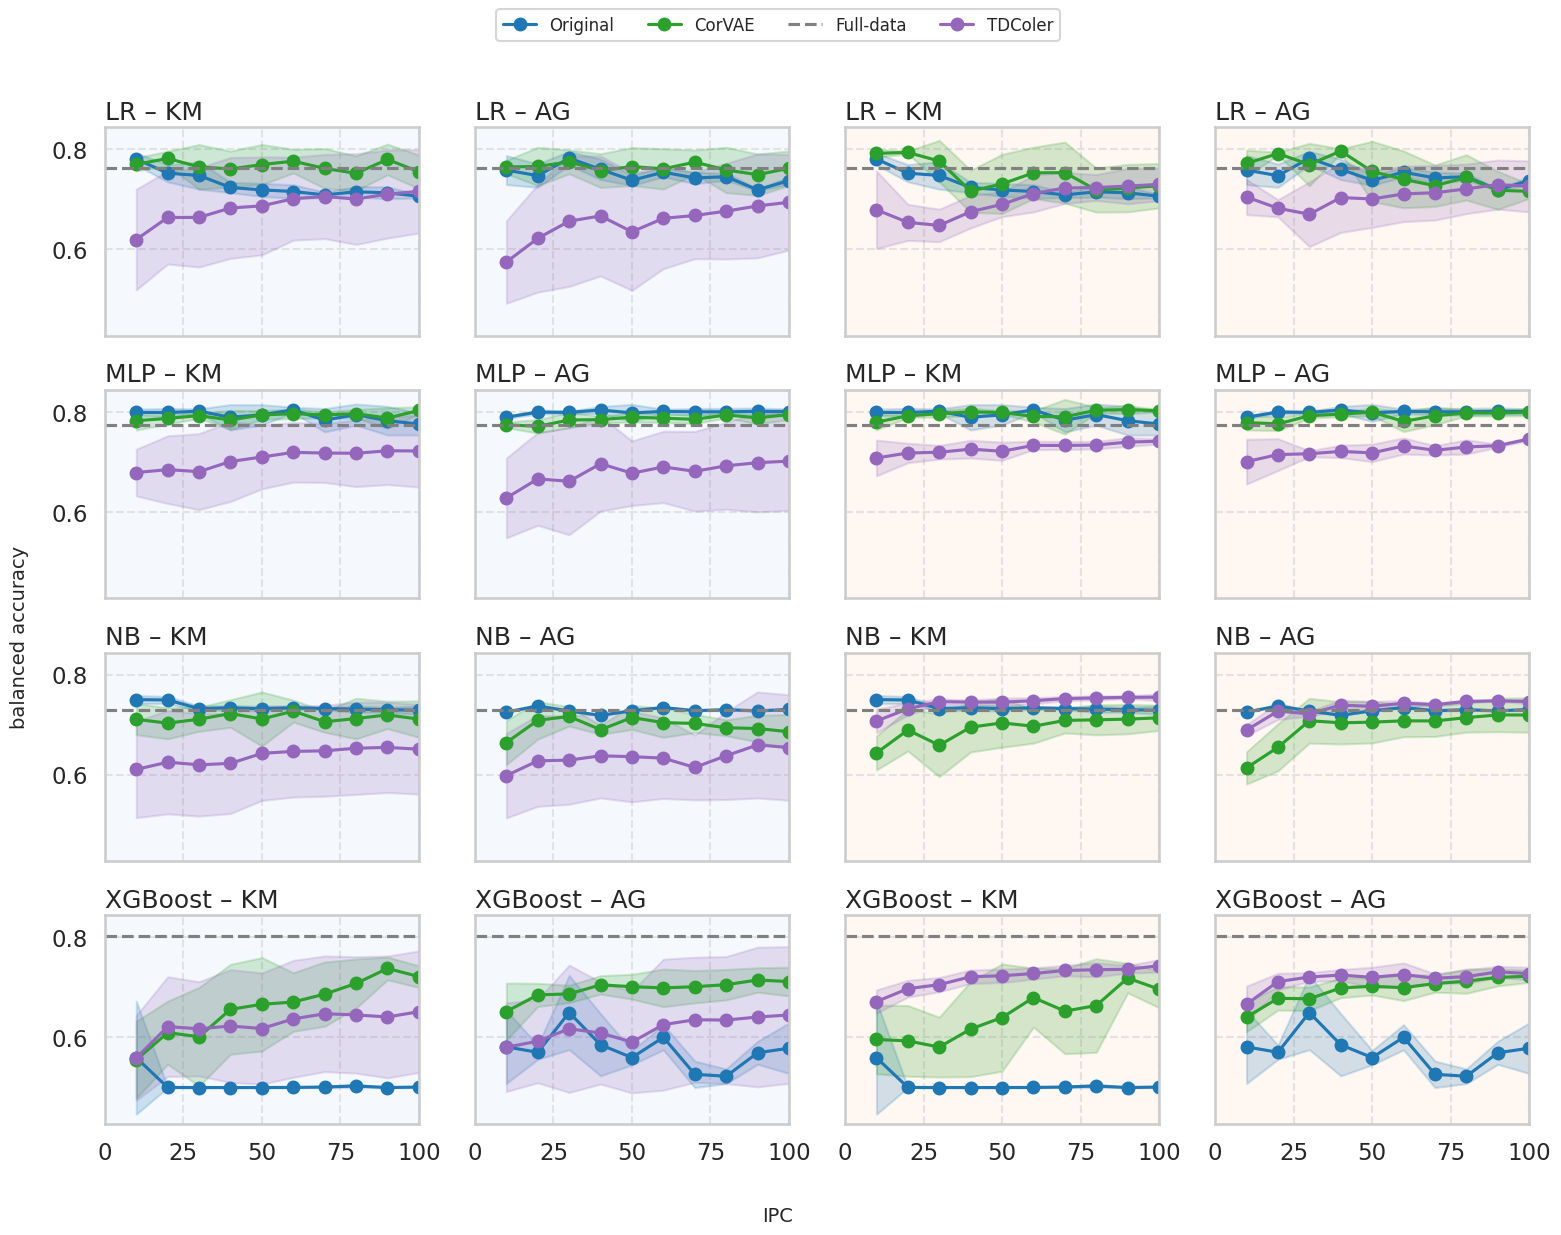

In [82]:
# Curvas de evaluación en reconstruido y latente con la metricas de balanced accuracy
# para K-means y agglomerative clustering
methods = ['k-means','ag']
models = ['logreg','mlp','naive_bayes','xgb']

compare_columns = df_tdcoler_latent_adult.columns

plot_metric_grid_all(
    df_full=df_full_adult[compare_columns],
    df_only_coreset=df_only_coreset_adult[compare_columns],
    df_latent=df_latent_adult[compare_columns],
    df_latent_ft=df_latent_ft_adult[compare_columns],
    df_TDColer=df_tdcoler_latent_adult,      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='results/curve_figures/adult_tdcoler_KM_AG_balanced_accuracy.png'
)

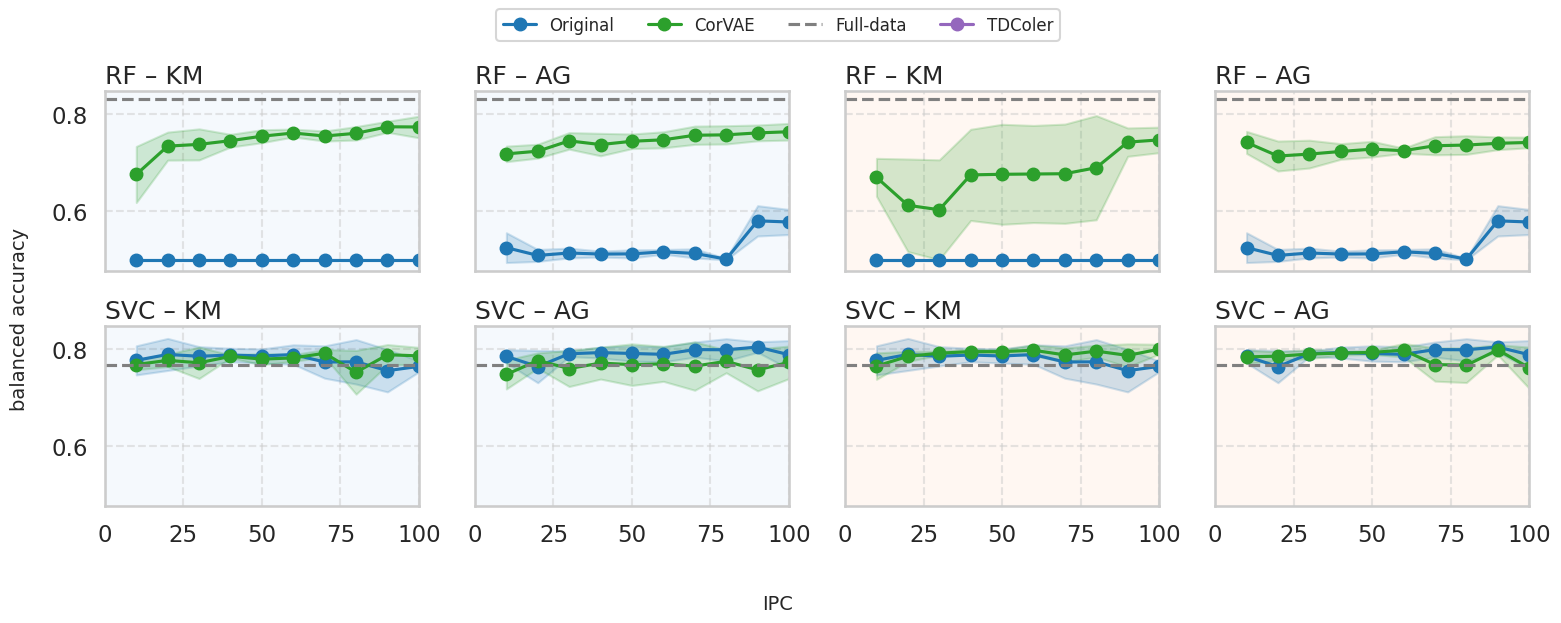

In [83]:
# Curvas de evaluación en reconstruido y latente con la metricas de balanced accuracy
# para K-means y agglomerative clustering pero para los otros modelos de SVC y RF
methods = ['k-means','ag']
models = ['rf','svc']

compare_columns = df_tdcoler_latent_adult.columns

plot_metric_grid_all(
    df_full=df_full_adult[compare_columns],
    df_only_coreset=df_only_coreset_adult[compare_columns],
    df_latent=df_latent_adult[compare_columns],
    df_latent_ft=df_latent_ft_adult[compare_columns],
    df_TDColer=df_tdcoler_latent_adult,     
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='results/curve_figures/adult_svc_rf_KM_AG_balanced_accuracy.png'
)

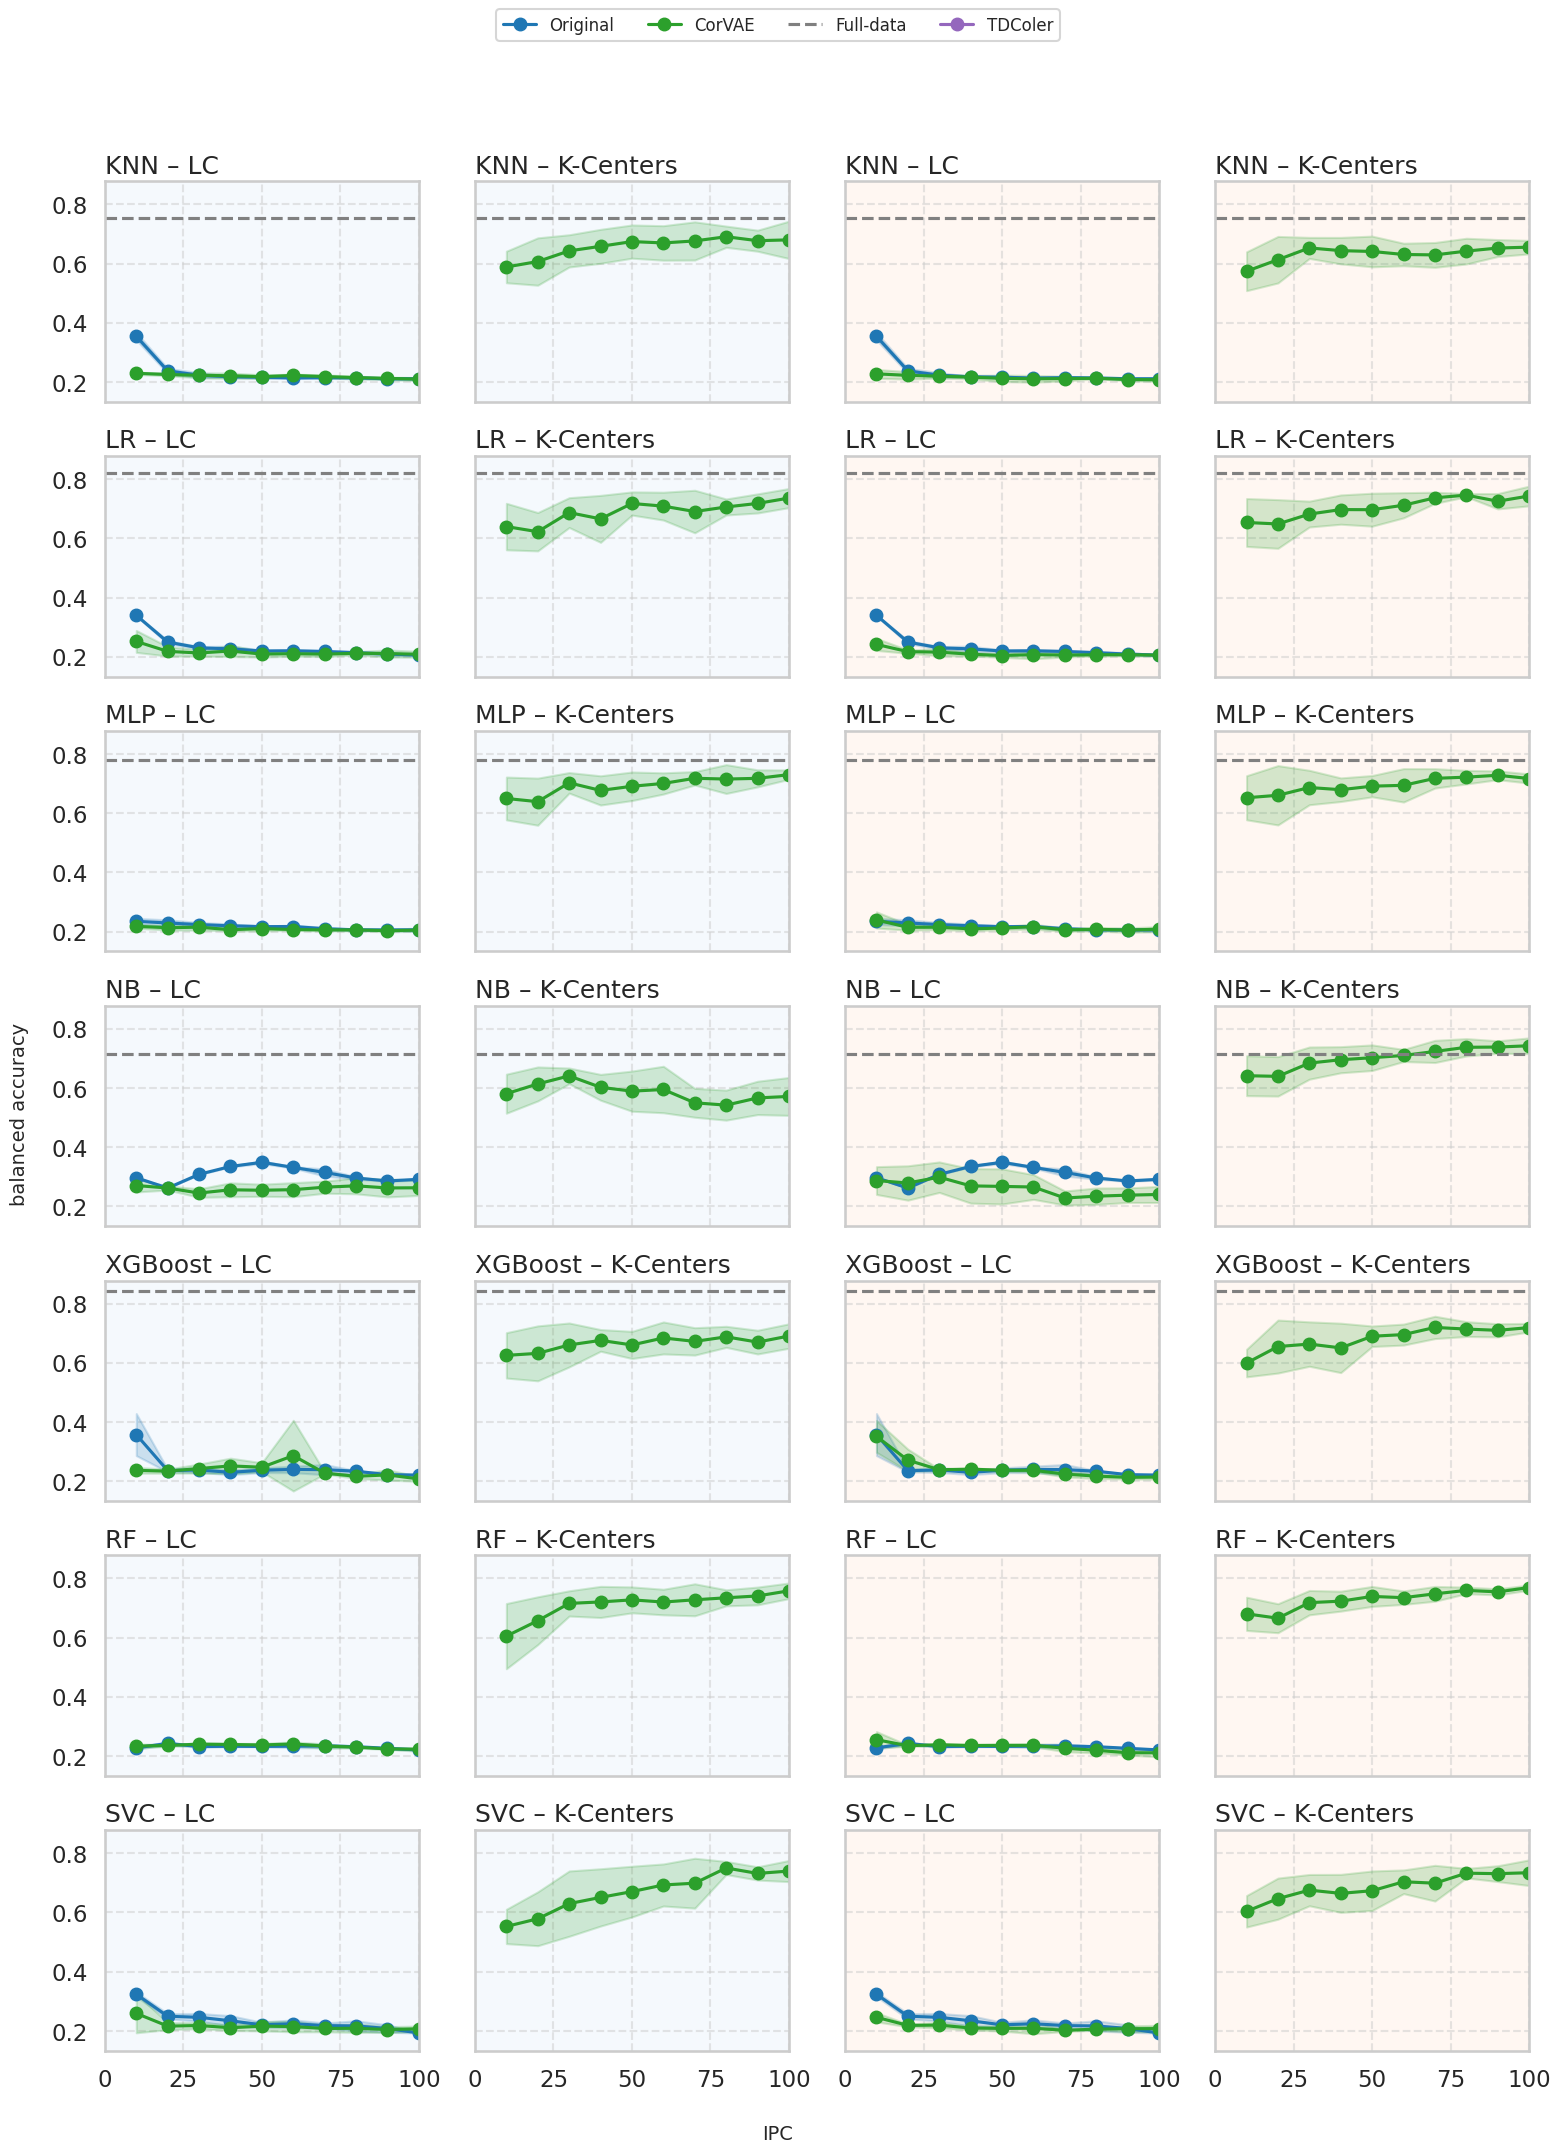

In [84]:
# Curvas de evaluación en reconstruido y latente con la metricas de balanced accuracy
# para least confidence y k-centers para todos los modelos
methods = ['lc','k-center']
models = ['knn','logreg','mlp','naive_bayes','xgb','rf','svc']

compare_columns = df_tdcoler_latent_adult.columns

plot_metric_grid_all(
    df_full=df_tdcoler_full_adult,
    df_only_coreset=df_only_coreset_adult[compare_columns],
    df_latent=df_latent_adult[compare_columns],
    df_latent_ft=df_latent_ft_adult[compare_columns],
    df_TDColer=df_tdcoler_latent_adult,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='results/curve_figures/adult_LC_KCENTERS_balanced_accuracy.png'
)

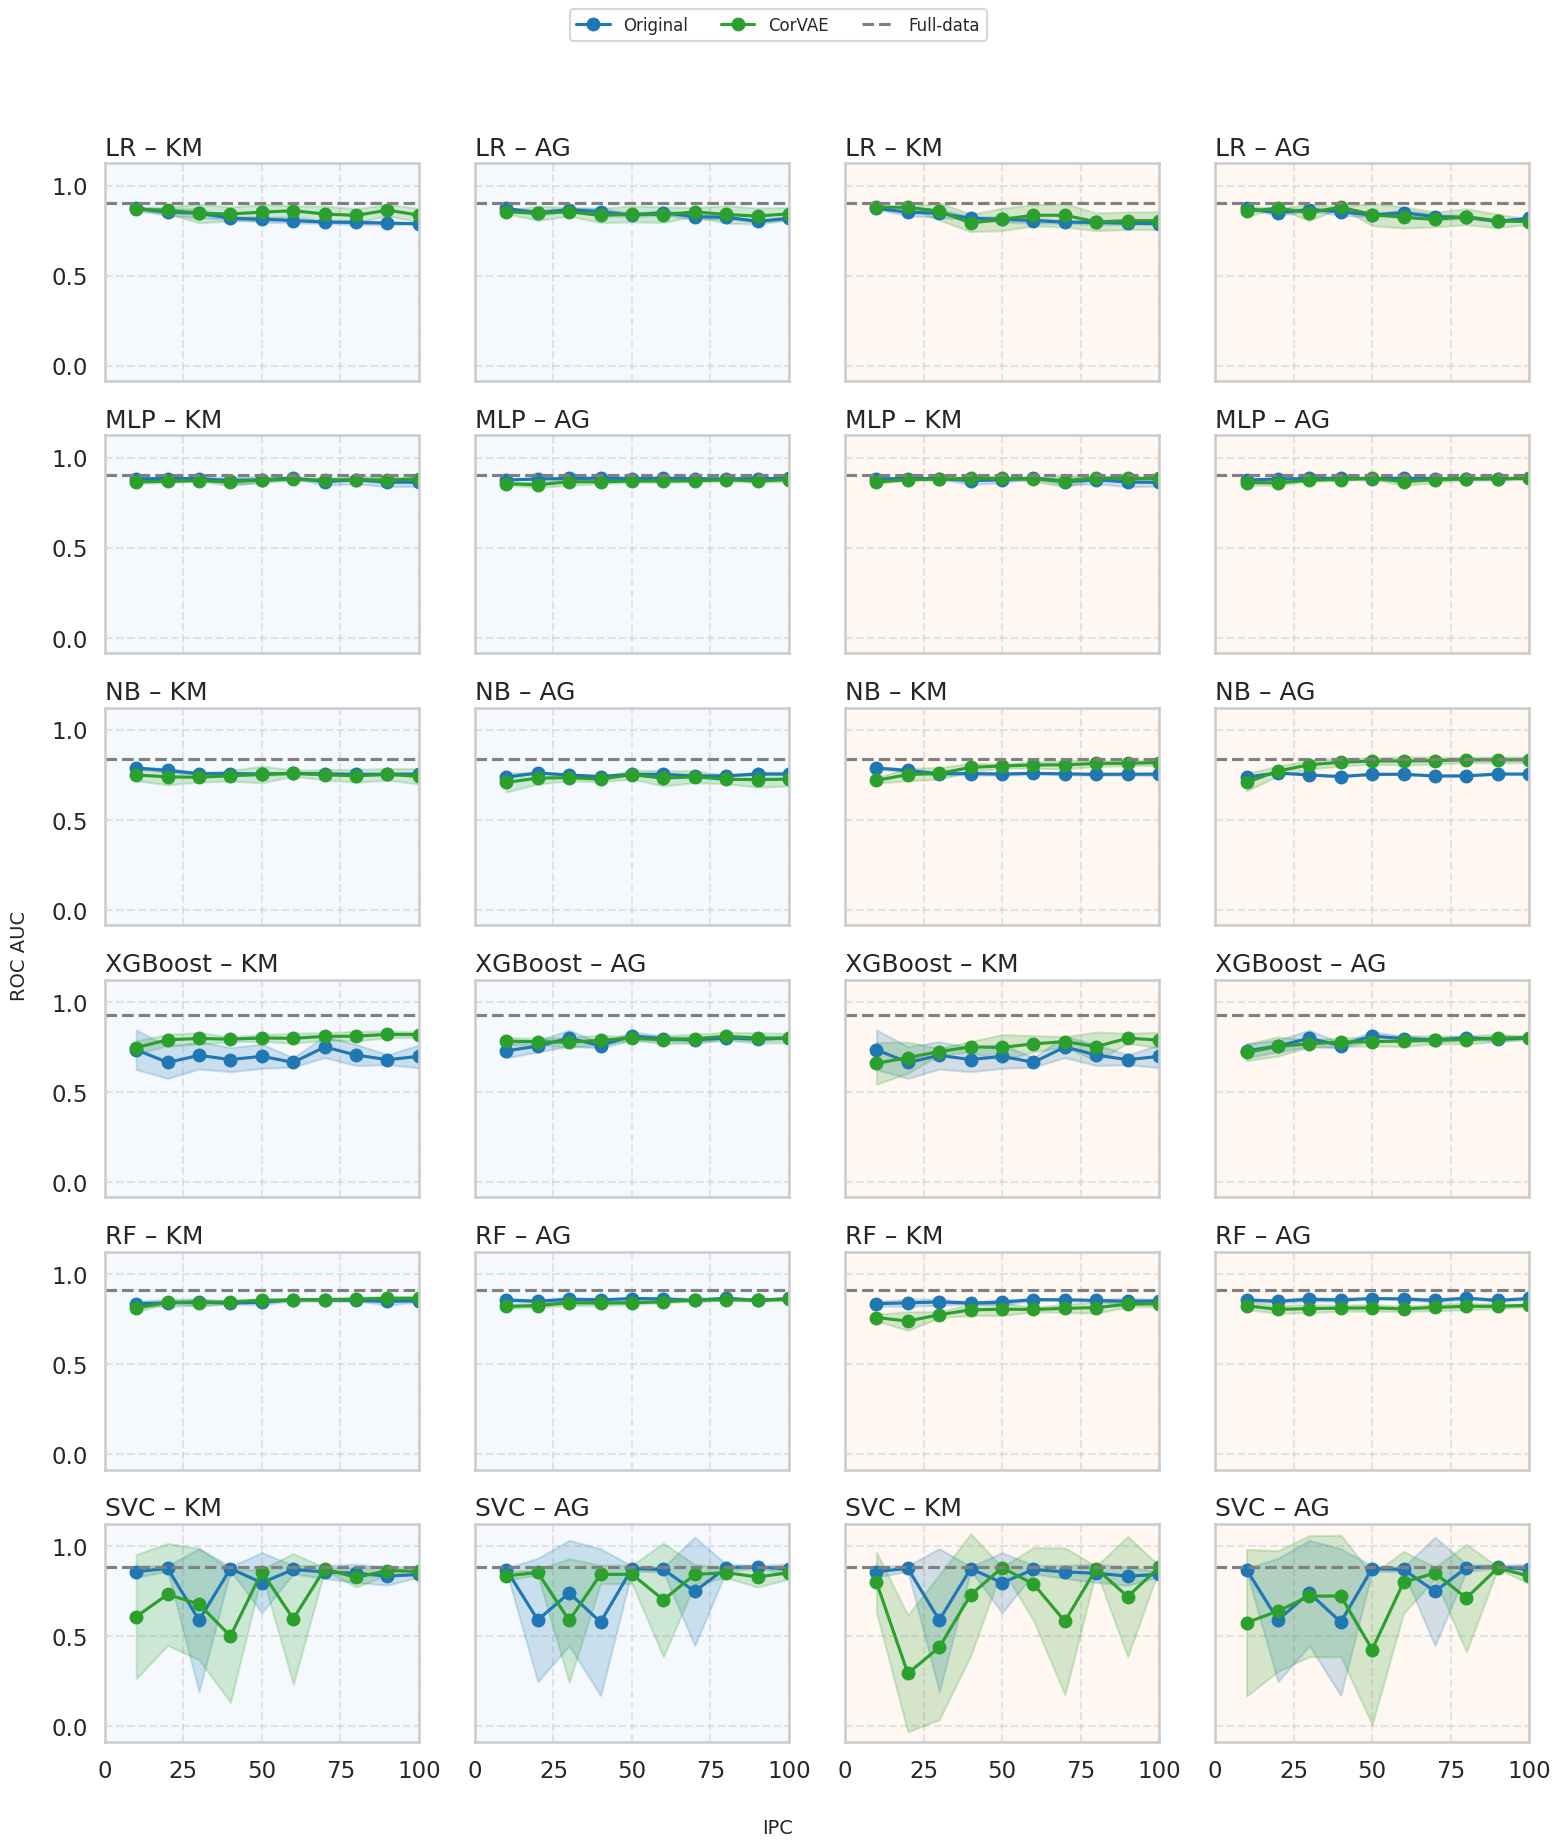

In [85]:
# Curvas de evaluación en reconstruido y latente con la metricas de ROC AUC
# para kmeans y agglomerative clustering

methods = ['k-means','ag']
models = ['logreg','mlp','naive_bayes','xgb','rf','svc']

compare_columns = df_full_adult.columns

plot_metric_grid_all(
    df_full=df_full_adult[compare_columns],
    df_only_coreset=df_only_coreset_adult[compare_columns],
    df_latent=df_latent_adult[compare_columns],
    df_latent_ft=df_latent_ft_adult[compare_columns],
   
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='results/curve_figures/adult_KM_AG_roc_auc.png'
)

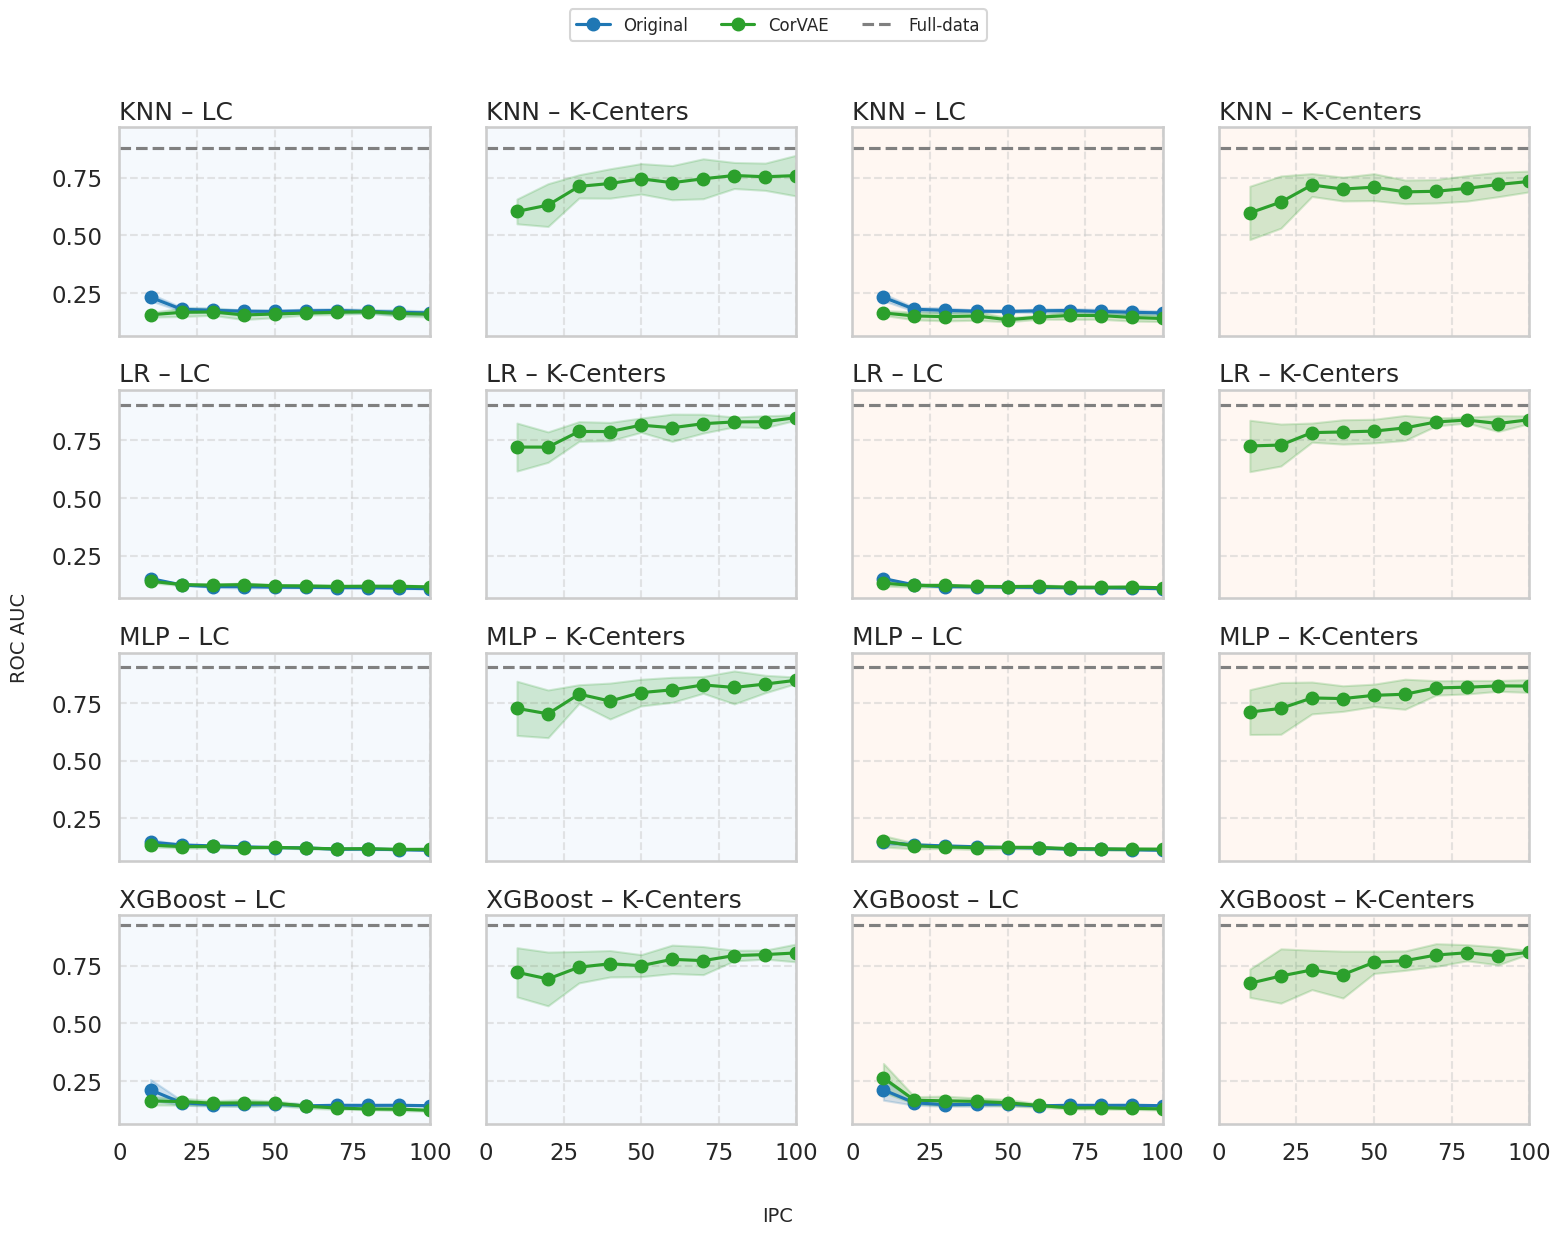

In [86]:
# Curvas de evaluación en reconstruido y latente con la metricas de ROC AUC
# para LC y K-centers para todos los modelos

methods = ['lc','k-center']
models = ['knn','logreg','mlp','xgb']
compare_columns = df_full_adult.columns

plot_metric_grid_all(
    df_full=df_full_adult[compare_columns],
    df_only_coreset=df_only_coreset_adult[compare_columns],
    df_latent=df_latent_adult[compare_columns],
    df_latent_ft=df_latent_ft_adult[compare_columns],
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='results/curve_figures/adult_LC_KCENTERS_roc_auc.png'
)

## Dataset Default

In [15]:
df_only_coreset_default = pd.read_csv('results/checkpoint/checkpoint_default_Doriginal_H/metrics.csv')

df_full_default = df_only_coreset_default[df_only_coreset_default['method'] == 'Full-data']
df_latent_default = pd.read_csv('results/checkpoint/checkpoint_default_Dlatent_G/metrics.csv')
df_latent_ft_default = pd.read_csv('results/checkpoint/checkpoint_default_Dlatent_ft_H/metrics.csv')

In [16]:
df_only_coreset_default.head()

,model,method,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,optuna_time,train_time,test_balanced,test_macro_f1,test_weighted_f1,test_accuracy,test_roc_auc,inf_time_per_sample,space,IPC,seed,vae_pretrain_time,vae_fine_tunning_time,encoder_inference_time,decoder_inference_time,destillation_time
0,xgb,Full-data,0.658,0.682,0.798,0.819,0.002,0.003,0.002,0.001,56.426,0.543,0.659,0.683,0.798,0.817,0.781,0.000008,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,rf,Full-data,0.714,0.697,0.783,0.775,0.004,0.004,0.004,0.004,387.816,16.788,0.711,0.694,0.781,0.773,0.788,0.000035,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,svc,Full-data,0.649,0.674,0.796,0.820,0.003,0.003,0.002,0.001,14212.953,670.607,0.648,0.674,0.796,0.821,0.723,0.001297,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,Full-data,0.654,0.680,0.798,0.821,0.002,0.002,0.001,0.001,34.306,8.260,0.656,0.682,0.799,0.820,0.770,0.000000,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp,Full-data,0.657,0.680,0.797,0.817,0.004,0.004,0.002,0.002,213.389,5.516,0.662,0.687,0.801,0.822,0.781,0.000010,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
# Información de la evaluación con todos los datos
df_full_default[['model','method','optuna_time']]

,model,method,optuna_time
0,xgb,Full-data,56.426
1,rf,Full-data,387.816
2,svc,Full-data,14212.953
3,logreg,Full-data,34.306
4,mlp,Full-data,213.389
5,naive_bayes,Full-data,13.921
6,knn,Full-data,221.041


In [90]:
df_only_coreset_default

,model,method,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,optuna_time,train_time,test_balanced,test_macro_f1,test_weighted_f1,test_accuracy,test_roc_auc,inf_time_per_sample,space,IPC,seed,vae_pretrain_time,vae_fine_tunning_time,encoder_inference_time,decoder_inference_time,destillation_time
0,xgb,Full-data,0.658,0.682,0.798,0.819,0.002,0.003,0.002,0.001,56.426,0.543,0.659,0.683,0.798,0.817,0.781,0.000008,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,rf,Full-data,0.714,0.697,0.783,0.775,0.004,0.004,0.004,0.004,387.816,16.788,0.711,0.694,0.781,0.773,0.788,0.000035,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,svc,Full-data,0.649,0.674,0.796,0.820,0.003,0.003,0.002,0.001,14212.953,670.607,0.648,0.674,0.796,0.821,0.723,0.001297,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,Full-data,0.654,0.680,0.798,0.821,0.002,0.002,0.001,0.001,34.306,8.260,0.656,0.682,0.799,0.820,0.770,0.000000,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp,Full-data,0.657,0.680,0.797,0.817,0.004,0.004,0.002,0.002,213.389,5.516,0.662,0.687,0.801,0.822,0.781,0.000010,original,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1752,svc,lc,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,3.777,0.006,0.361,0.189,0.146,0.196,0.248,0.000006,original,100.0,9.0,NaN,NaN,NaN,NaN,6.453051
1753,logreg,lc,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,7.379,0.006,0.352,0.192,0.154,0.197,0.250,0.000000,original,100.0,9.0,NaN,NaN,NaN,NaN,6.453051
1754,mlp,lc,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,6.746,4.172,0.362,0.187,0.142,0.195,0.264,0.000028,original,100.0,9.0,NaN,NaN,NaN,NaN,6.453051
1755,naive_bayes,lc,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,2.607,0.002,0.412,0.177,0.105,0.197,0.411,0.000001,original,100.0,9.0,NaN,NaN,NaN,NaN,6.453051


### Calculo de tablas con valor de IPC

In [91]:
tabla = summarize_two_metrics(
    ipc=10,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_default,
    df_latent=df_latent_default,
    df_tdcoler=df_tdcoler_latent_default,
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.637±0.037   
1             CorVAE       Latente  Perceptrón Multicapa   0.650±0.016   
2             CorVAE       Latente     Ingenuo Bayesiano   0.525±0.013   
3             CorVAE       Latente      Bosque Aleatorio   0.663±0.021   
4             CorVAE       Latente                   svc   0.655±0.028   
5             CorVAE       Latente               XGBoost   0.637±0.026   
6             CorVAE  Reconstruido   Regresión Logística   0.618±0.046   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.635±0.017   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.650±0.033   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.592±0.023   
10            CorVAE  Reconstruido                   svc   0.625±0.042   
11            CorVAE  Reconstruido               XGBoost   0.583±0.011   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.660±0.014   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.674±0.005   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.620±0.007   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.637±0.028   
16      Sólo Coreset  Reconstruido                   svc   0.503±0.005   
17      Sólo Coreset  Reconstruido               XGBoost   0.537±0.062   
18           TDColer       Latente   Regresión Logística   0.672±0.014   
19           TDColer       Latente  Perceptrón Multicapa   0.665±0.024   
20           TDColer       Latente     Ingenuo Bayesiano   0.625±0.027   
21           TDColer       Latente               XGBoost   0.591±0.037   
22           TDColer  Reconstruido   Regresión Logística   0.647±0.017   
23           TDColer  Reconstruido  Perceptrón Multicapa   0.651±0.017   
24           TDColer  Reconstruido     Ingenuo Bayesiano   0.630±0.053   
25           TDColer  Reconstruido               XGBoost   0.594±0.050   

                                                           test_roc_auc  \
method     K-center           KM     k_center           LC           AG   
0       0.501±0.001  0.624±0.019          NaN  0.334±0.032  0.689±0.050   
1       0.516±0.032  0.664±0.016          NaN  0.345±0.030  0.712±0.021   
2       0.502±0.014  0.561±0.053          NaN  0.408±0.014  0.613±0.028   
3       0.505±0.004  0.643±0.026          NaN  0.365±0.050  0.720±0.022   
4       0.500±0.000  0.652±0.039          NaN  0.344±0.028  0.365±0.124   
5       0.496±0.042  0.622±0.025          NaN  0.420±0.013  0.693±0.017   
6       0.500±0.000  0.607±0.026          NaN  0.415±0.048  0.673±0.062   
7       0.514±0.033  0.645±0.020          NaN  0.329±0.020  0.699±0.024   
8       0.610±0.071  0.663±0.025          NaN  0.385±0.004  0.661±0.035   
9       0.538±0.019  0.585±0.016          NaN  0.395±0.016  0.644±0.030   
10      0.500±0.000  0.618±0.029          NaN  0.410±0.019  0.432±0.183   
11      0.544±0.019  0.576±0.016          NaN  0.442±0.043  0.618±0.014   
12              NaN  0.668±0.023  0.500±0.000  0.487±0.001  0.733±0.021   
13              NaN  0.677±0.014  0.513±0.022  0.385±0.040  0.747±0.005   
14              NaN  0.690±0.011  0.548±0.083  0.382±0.000  0.656±0.007   
15              NaN  0.533±0.075  0.489±0.017  0.371±0.013  0.728±0.021   
16              NaN  0.545±0.067  0.500±0.000  0.487±0.003  0.399±0.064   
17              NaN  0.517±0.027  0.503±0.026  0.435±0.006  0.660±0.065   
18              NaN  0.654±0.030          NaN          NaN      nan±nan   
19              NaN  0.651±0.041          NaN          NaN      nan±nan   
20              NaN  0.604±0.025          NaN          NaN      nan±nan   
21              NaN  0.594±0.028          NaN          NaN      nan±nan   
22              NaN  0.627±0.030          NaN          NaN      nan±nan   
23              NaN  0.625±0.030          NaN          NaN     

In [92]:
tabla = summarize_two_metrics(
    ipc=50,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_default,
    df_latent=df_latent_default,
    df_tdcoler=df_tdcoler_latent_default,
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.673±0.040   
1             CorVAE       Latente  Perceptrón Multicapa   0.674±0.012   
2             CorVAE       Latente     Ingenuo Bayesiano   0.578±0.016   
3             CorVAE       Latente      Bosque Aleatorio   0.655±0.014   
4             CorVAE       Latente                   svc   0.669±0.015   
5             CorVAE       Latente               XGBoost   0.648±0.011   
6             CorVAE  Reconstruido   Regresión Logística   0.633±0.030   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.667±0.008   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.601±0.052   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.620±0.011   
10            CorVAE  Reconstruido                   svc   0.656±0.008   
11            CorVAE  Reconstruido               XGBoost   0.591±0.017   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.610±0.002   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.681±0.007   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.683±0.001   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.553±0.016   
16      Sólo Coreset  Reconstruido                   svc   0.562±0.086   
17      Sólo Coreset  Reconstruido               XGBoost   0.531±0.025   
18           TDColer       Latente   Regresión Logística   0.677±0.006   
19           TDColer       Latente  Perceptrón Multicapa   0.665±0.015   
20           TDColer       Latente     Ingenuo Bayesiano   0.658±0.022   
21           TDColer       Latente               XGBoost   0.619±0.024   
22           TDColer  Reconstruido   Regresión Logística   0.640±0.012   
23           TDColer  Reconstruido  Perceptrón Multicapa   0.620±0.038   
24           TDColer  Reconstruido     Ingenuo Bayesiano   0.610±0.029   
25           TDColer  Reconstruido               XGBoost   0.606±0.014   

                                                           test_roc_auc  \
method     K-center           KM     k_center           LC           AG   
0       0.506±0.001  0.625±0.033          NaN  0.351±0.013  0.731±0.049   
1       0.508±0.013  0.691±0.007          NaN  0.345±0.006  0.740±0.010   
2       0.503±0.001  0.602±0.032          NaN  0.371±0.031  0.628±0.035   
3       0.515±0.011  0.650±0.024          NaN  0.345±0.011  0.725±0.017   
4       0.503±0.002  0.673±0.015          NaN  0.361±0.011  0.748±0.012   
5       0.525±0.028  0.657±0.035          NaN  0.356±0.043  0.713±0.016   
6       0.503±0.001  0.647±0.052          NaN  0.335±0.008  0.689±0.046   
7       0.513±0.014  0.675±0.008          NaN  0.346±0.006  0.731±0.010   
8       0.538±0.037  0.602±0.073          NaN  0.369±0.011  0.702±0.007   
9       0.526±0.011  0.626±0.017          NaN  0.330±0.013  0.672±0.014   
10      0.502±0.001  0.669±0.009          NaN  0.345±0.006  0.552±0.233   
11      0.517±0.036  0.609±0.019          NaN  0.334±0.011  0.639±0.024   
12              NaN  0.621±0.014  0.504±0.001  0.340±0.003  0.628±0.008   
13              NaN  0.694±0.009  0.503±0.001  0.349±0.006  0.756±0.009   
14              NaN  0.682±0.003  0.549±0.072  0.384±0.001  0.725±0.000   
15              NaN  0.552±0.035  0.503±0.005  0.360±0.005  0.756±0.008   
16              NaN  0.630±0.044  0.502±0.001  0.360±0.005  0.399±0.184   
17              NaN  0.540±0.031  0.502±0.010  0.359±0.004  0.669±0.012   
18              NaN  0.665±0.019          NaN          NaN      nan±nan   
19              NaN  0.657±0.022          NaN          NaN      nan±nan   
20              NaN  0.658±0.018          NaN          NaN      nan±nan   
21              NaN  0.623±0.025          NaN          NaN      nan±nan   
22              NaN  0.624±0.025          NaN          NaN      nan±nan   
23              NaN  0.618±0.026          NaN          NaN     

In [93]:
tabla = summarize_two_metrics(
    ipc=100,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_default,
    df_latent=df_latent_default,
    df_tdcoler=df_tdcoler_latent_default,
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.646±0.040   
1             CorVAE       Latente  Perceptrón Multicapa   0.683±0.009   
2             CorVAE       Latente     Ingenuo Bayesiano   0.544±0.009   
3             CorVAE       Latente      Bosque Aleatorio   0.649±0.013   
4             CorVAE       Latente                   svc   0.673±0.015   
5             CorVAE       Latente               XGBoost   0.641±0.019   
6             CorVAE  Reconstruido   Regresión Logística   0.659±0.004   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.675±0.005   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.528±0.008   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.621±0.007   
10            CorVAE  Reconstruido                   svc   0.671±0.004   
11            CorVAE  Reconstruido               XGBoost   0.584±0.012   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.637±0.011   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.683±0.005   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.670±0.001   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.607±0.014   
16      Sólo Coreset  Reconstruido                   svc   0.633±0.042   
17      Sólo Coreset  Reconstruido               XGBoost   0.609±0.021   
18           TDColer       Latente   Regresión Logística   0.675±0.011   
19           TDColer       Latente  Perceptrón Multicapa   0.671±0.011   
20           TDColer       Latente     Ingenuo Bayesiano   0.668±0.006   
21           TDColer       Latente               XGBoost   0.646±0.008   
22           TDColer  Reconstruido   Regresión Logística   0.632±0.040   
23           TDColer  Reconstruido  Perceptrón Multicapa   0.636±0.021   
24           TDColer  Reconstruido     Ingenuo Bayesiano   0.576±0.063   
25           TDColer  Reconstruido               XGBoost   0.629±0.015   

                                                           test_roc_auc  \
method     K-center           KM     k_center           LC           AG   
0       0.510±0.003  0.647±0.042          NaN  0.356±0.010  0.700±0.048   
1       0.510±0.005  0.691±0.010          NaN  0.346±0.003  0.751±0.009   
2       0.505±0.001  0.541±0.006          NaN  0.348±0.032  0.616±0.050   
3       0.519±0.006  0.643±0.015          NaN  0.338±0.013  0.729±0.021   
4       0.506±0.002  0.670±0.013          NaN  0.353±0.012  0.757±0.008   
5       0.517±0.018  0.637±0.009          NaN  0.355±0.026  0.709±0.011   
6       0.506±0.001  0.657±0.027          NaN  0.341±0.005  0.720±0.008   
7       0.509±0.003  0.689±0.008          NaN  0.348±0.004  0.740±0.010   
8       0.537±0.043  0.607±0.067          NaN  0.358±0.028  0.711±0.007   
9       0.533±0.007  0.629±0.006          NaN  0.335±0.005  0.693±0.011   
10      0.503±0.001  0.679±0.002          NaN  0.347±0.003  0.725±0.007   
11      0.523±0.013  0.613±0.005          NaN  0.335±0.015  0.645±0.011   
12              NaN  0.628±0.012  0.503±0.001  0.357±0.003  0.685±0.033   
13              NaN  0.699±0.004  0.505±0.000  0.361±0.009  0.761±0.004   
14              NaN  0.669±0.006  0.537±0.023  0.412±0.000  0.722±0.000   
15              NaN  0.525±0.030  0.512±0.003  0.368±0.007  0.749±0.005   
16              NaN  0.662±0.041  0.504±0.002  0.363±0.003  0.739±0.007   
17              NaN  0.526±0.015  0.516±0.005  0.350±0.003  0.710±0.006   
18              NaN  0.677±0.013          NaN          NaN      nan±nan   
19              NaN  0.678±0.014          NaN          NaN      nan±nan   
20              NaN  0.670±0.007          NaN          NaN      nan±nan   
21              NaN  0.642±0.012          NaN          NaN      nan±nan   
22              NaN  0.630±0.028          NaN          NaN      nan±nan   
23              NaN  0.634±0.027          NaN          NaN     

### Calculo de curvas para un rango de IPC de 10 a 100

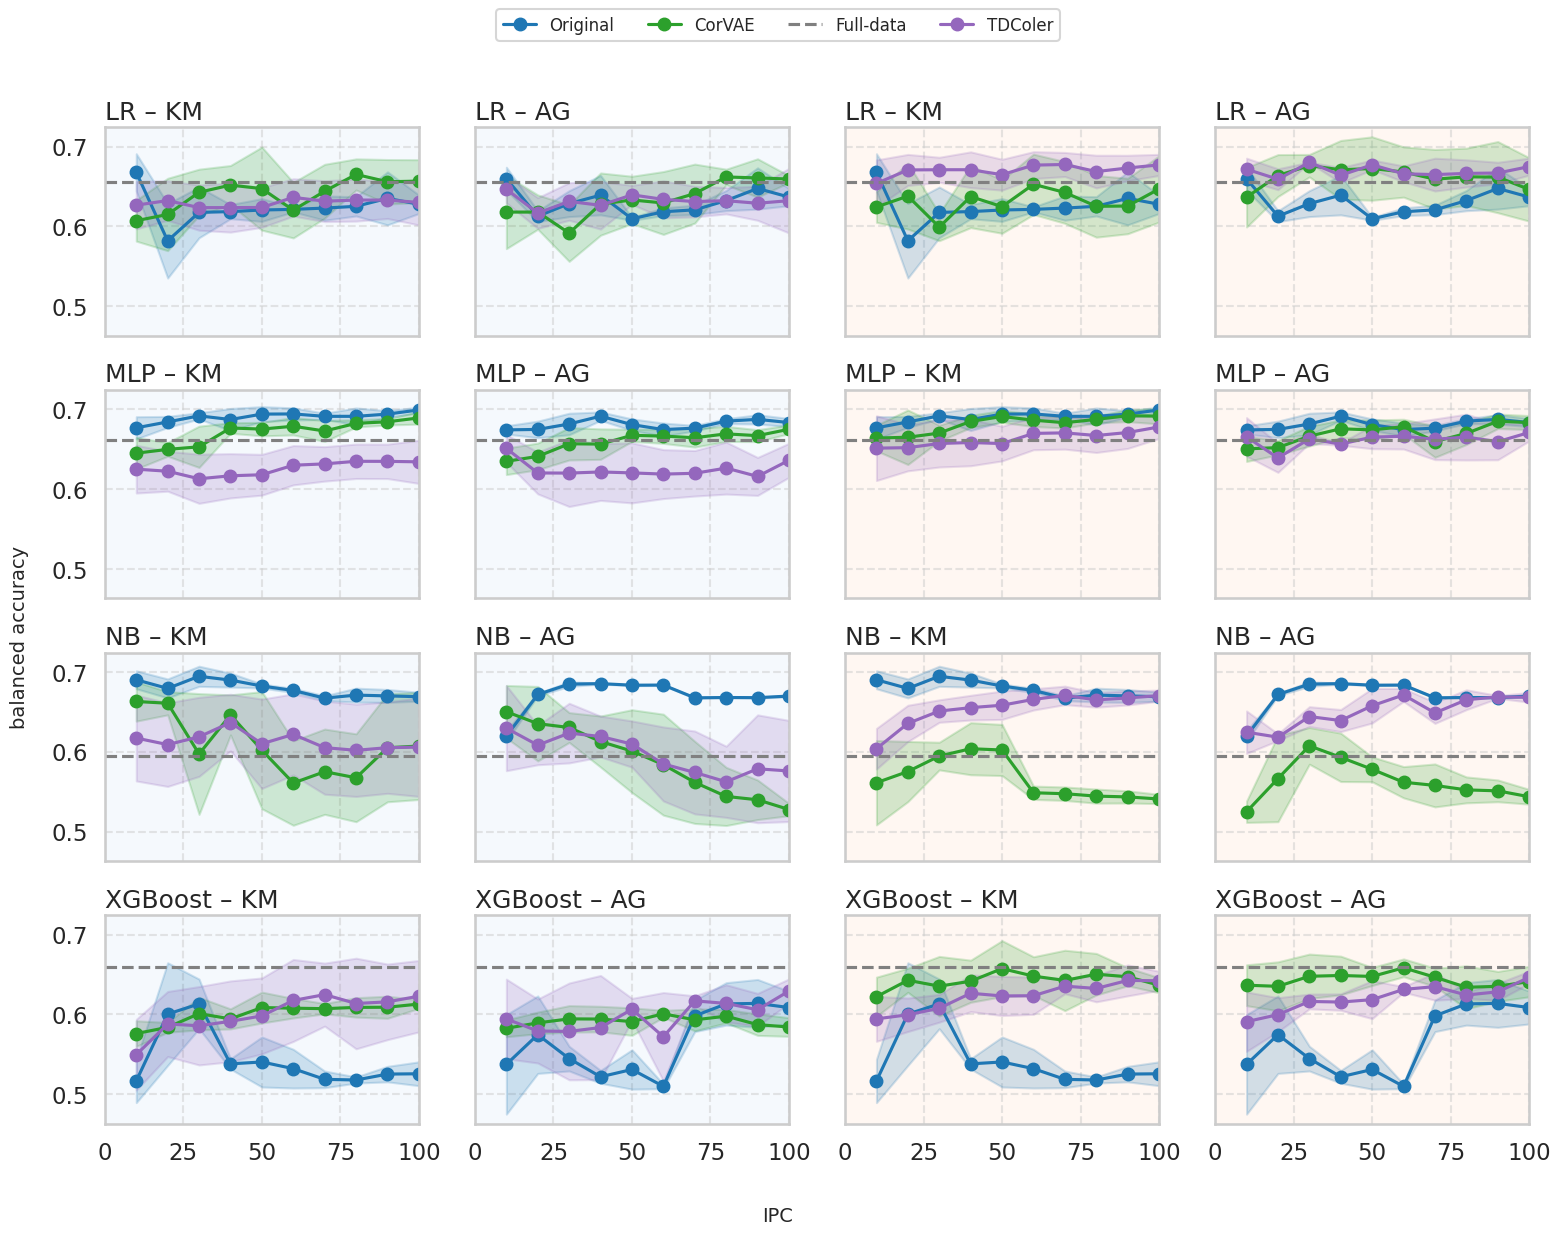

In [94]:
methods = ['k-means','ag']
models = ['logreg','mlp','naive_bayes','xgb']

compare_columns = df_tdcoler_latent_default.columns

plot_metric_grid_all(
    df_full=df_full_default[compare_columns],
    df_only_coreset=df_only_coreset_default[compare_columns],
    df_latent=df_latent_default[compare_columns],
    df_latent_ft=df_latent_ft_default[compare_columns],
    df_TDColer=df_tdcoler_latent_default,
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='results/curve_figures/default_tdcoler_KM_AG_balanced_accuracy.png'
)

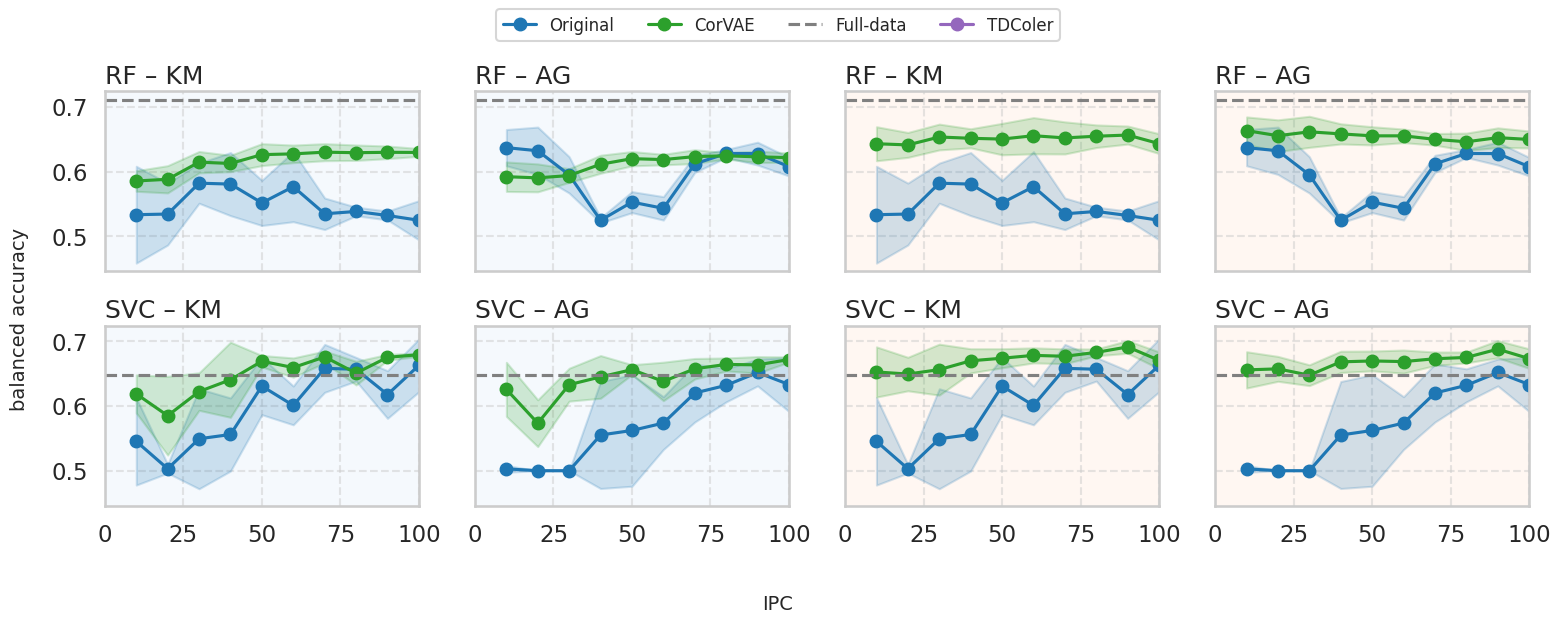

In [95]:
methods = ['k-means','ag']
models = ['rf','svc']
compare_columns = df_tdcoler_latent_default.columns

plot_metric_grid_all(
    df_full=df_full_default[compare_columns],
    df_only_coreset=df_only_coreset_default[compare_columns],
    df_latent=df_latent_default[compare_columns],
    df_latent_ft=df_latent_ft_default[compare_columns],
    df_TDColer=df_tdcoler_latent_default,
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='results/curve_figures/default_svc_rf_KM_AG_balanced_accuracy.png'
)

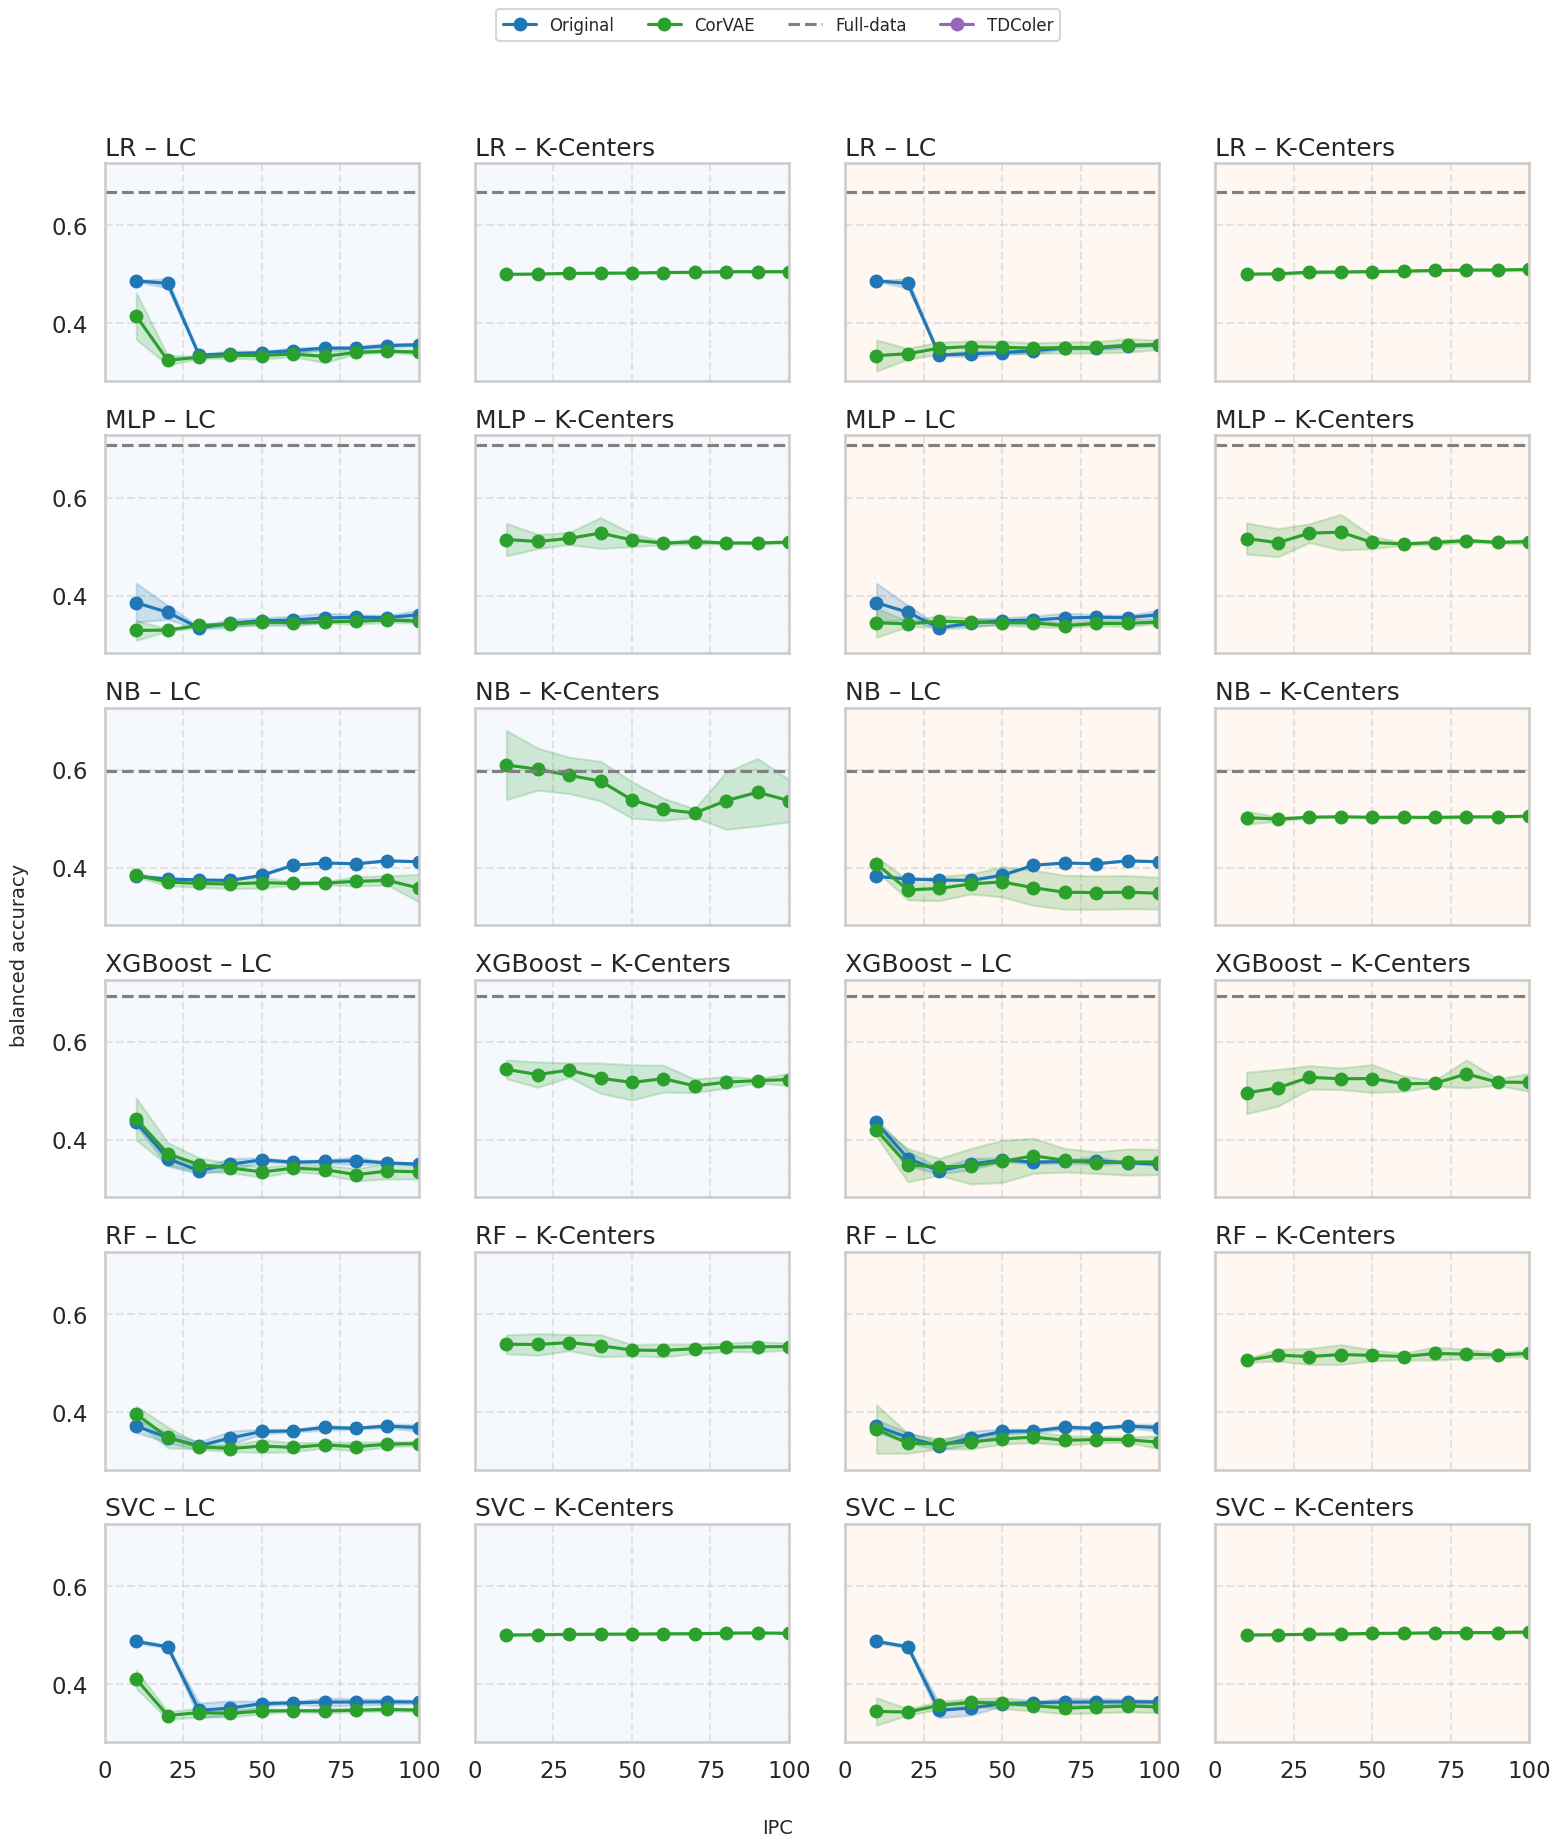

In [96]:
methods = ['lc','k-center']
models = ['logreg','mlp','naive_bayes','xgb','rf','svc']

compare_columns = df_tdcoler_latent_default.columns

plot_metric_grid_all(
    df_full=df_tdcoler_full_default,
    df_only_coreset=df_only_coreset_default[compare_columns],
    df_latent=df_latent_default[compare_columns],
    df_latent_ft=df_latent_ft_default[compare_columns],
    df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='results/curve_figures/default_LC_KCENTERS_balanced_accuracy.png'
)

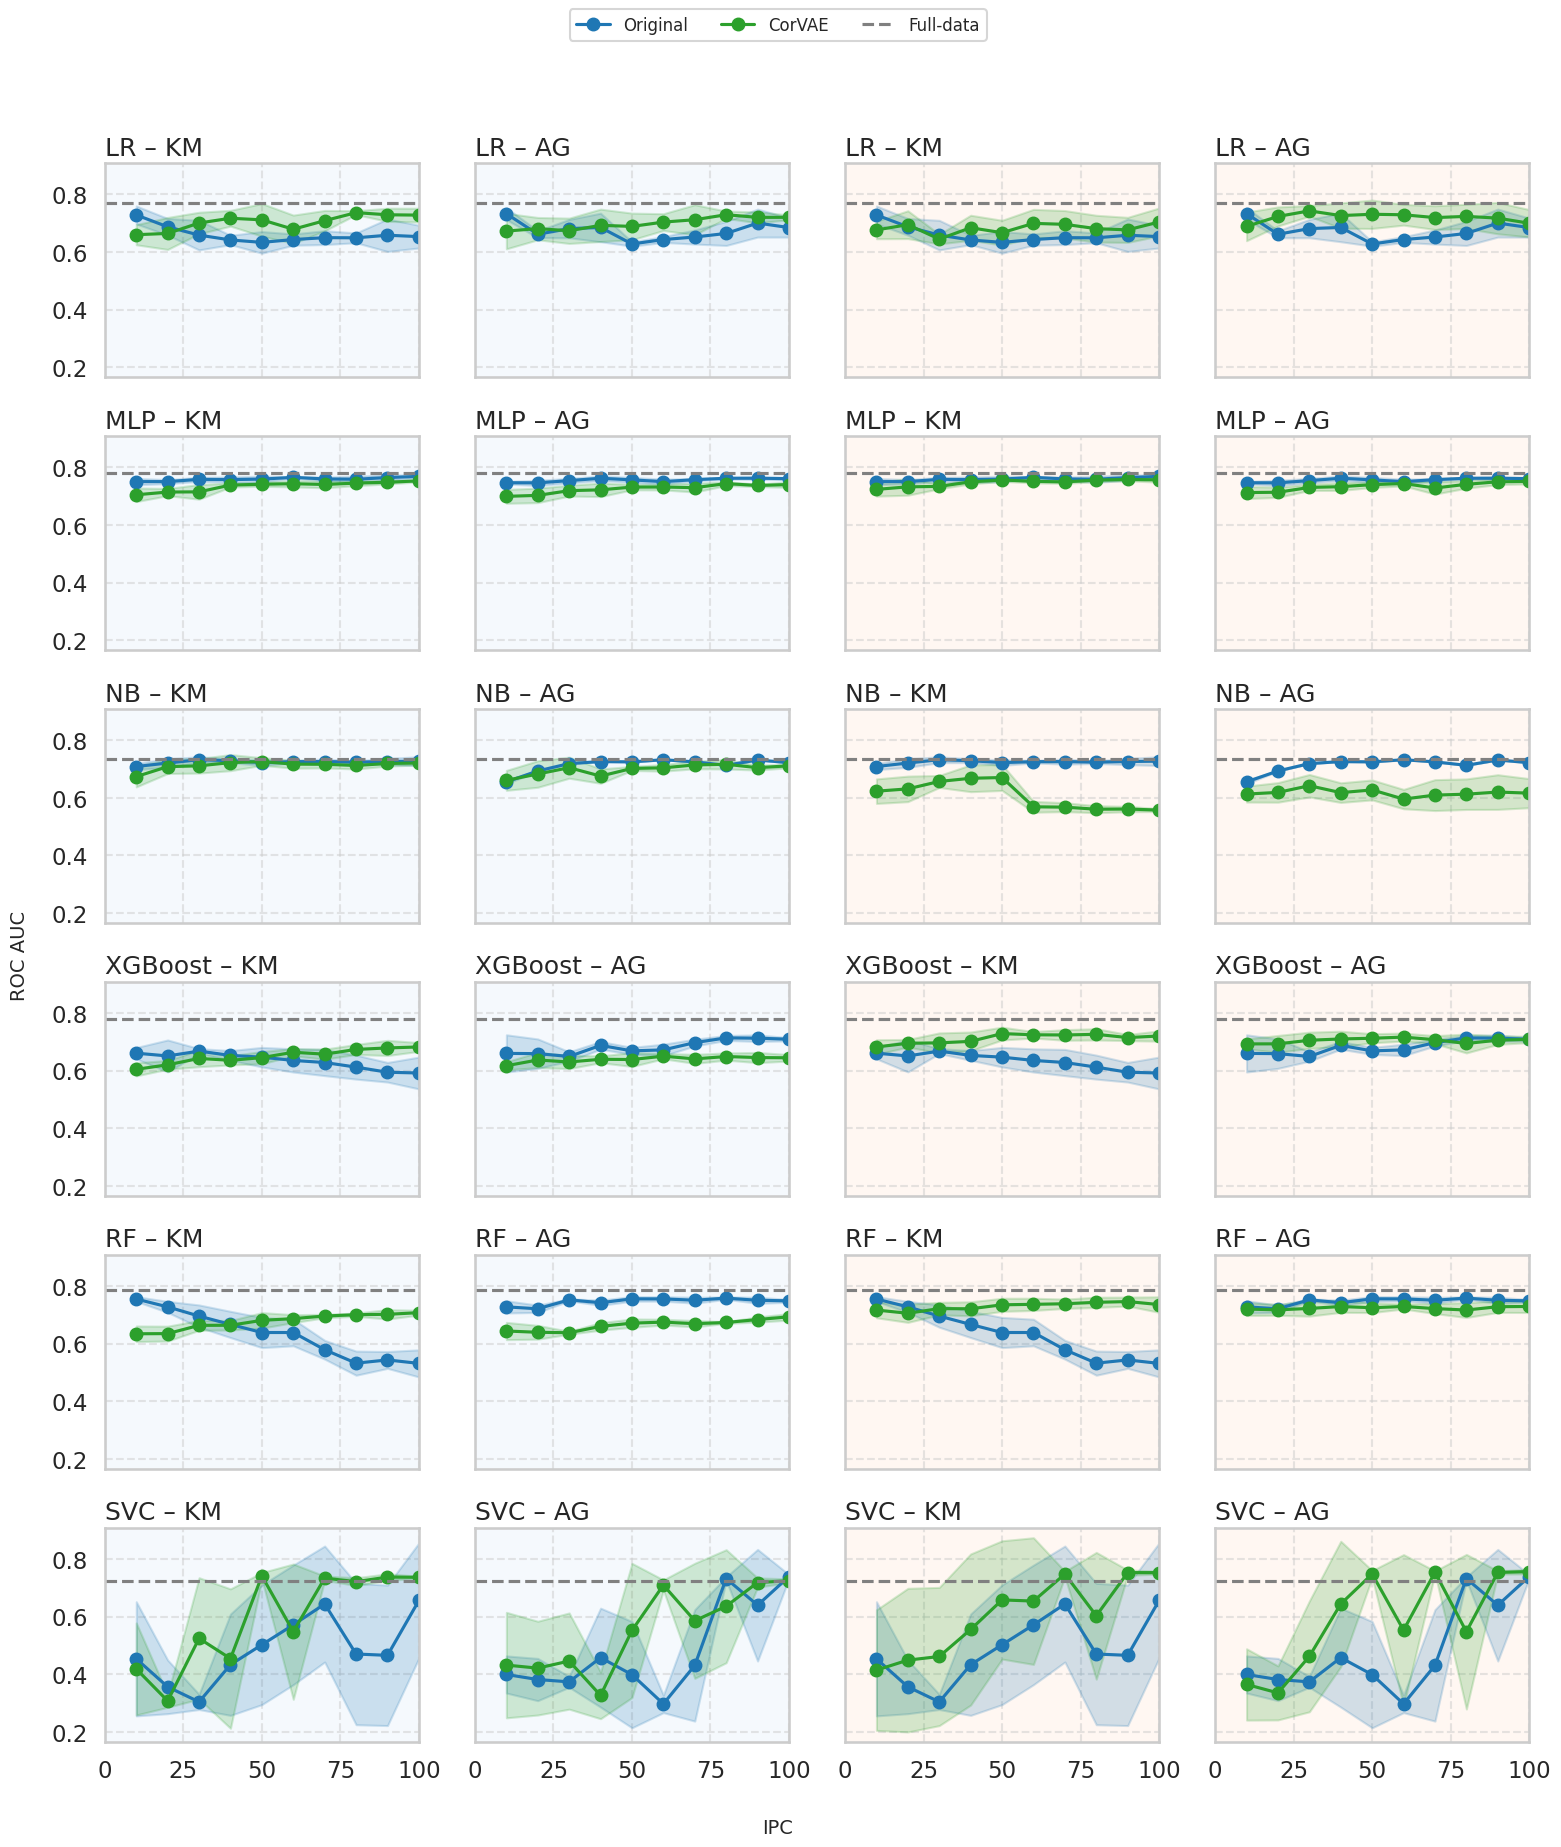

In [97]:
methods = ['k-means','ag']
models = ['logreg','mlp','naive_bayes','xgb','rf','svc']

compare_columns = df_full_default.columns

plot_metric_grid_all(
    df_full=df_full_default[compare_columns],
    df_only_coreset=df_only_coreset_default[compare_columns],
    df_latent=df_latent_default[compare_columns],
    df_latent_ft=df_latent_ft_default[compare_columns],    
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='results/curve_figures/default_KM_AG_roc_auc.png'
)

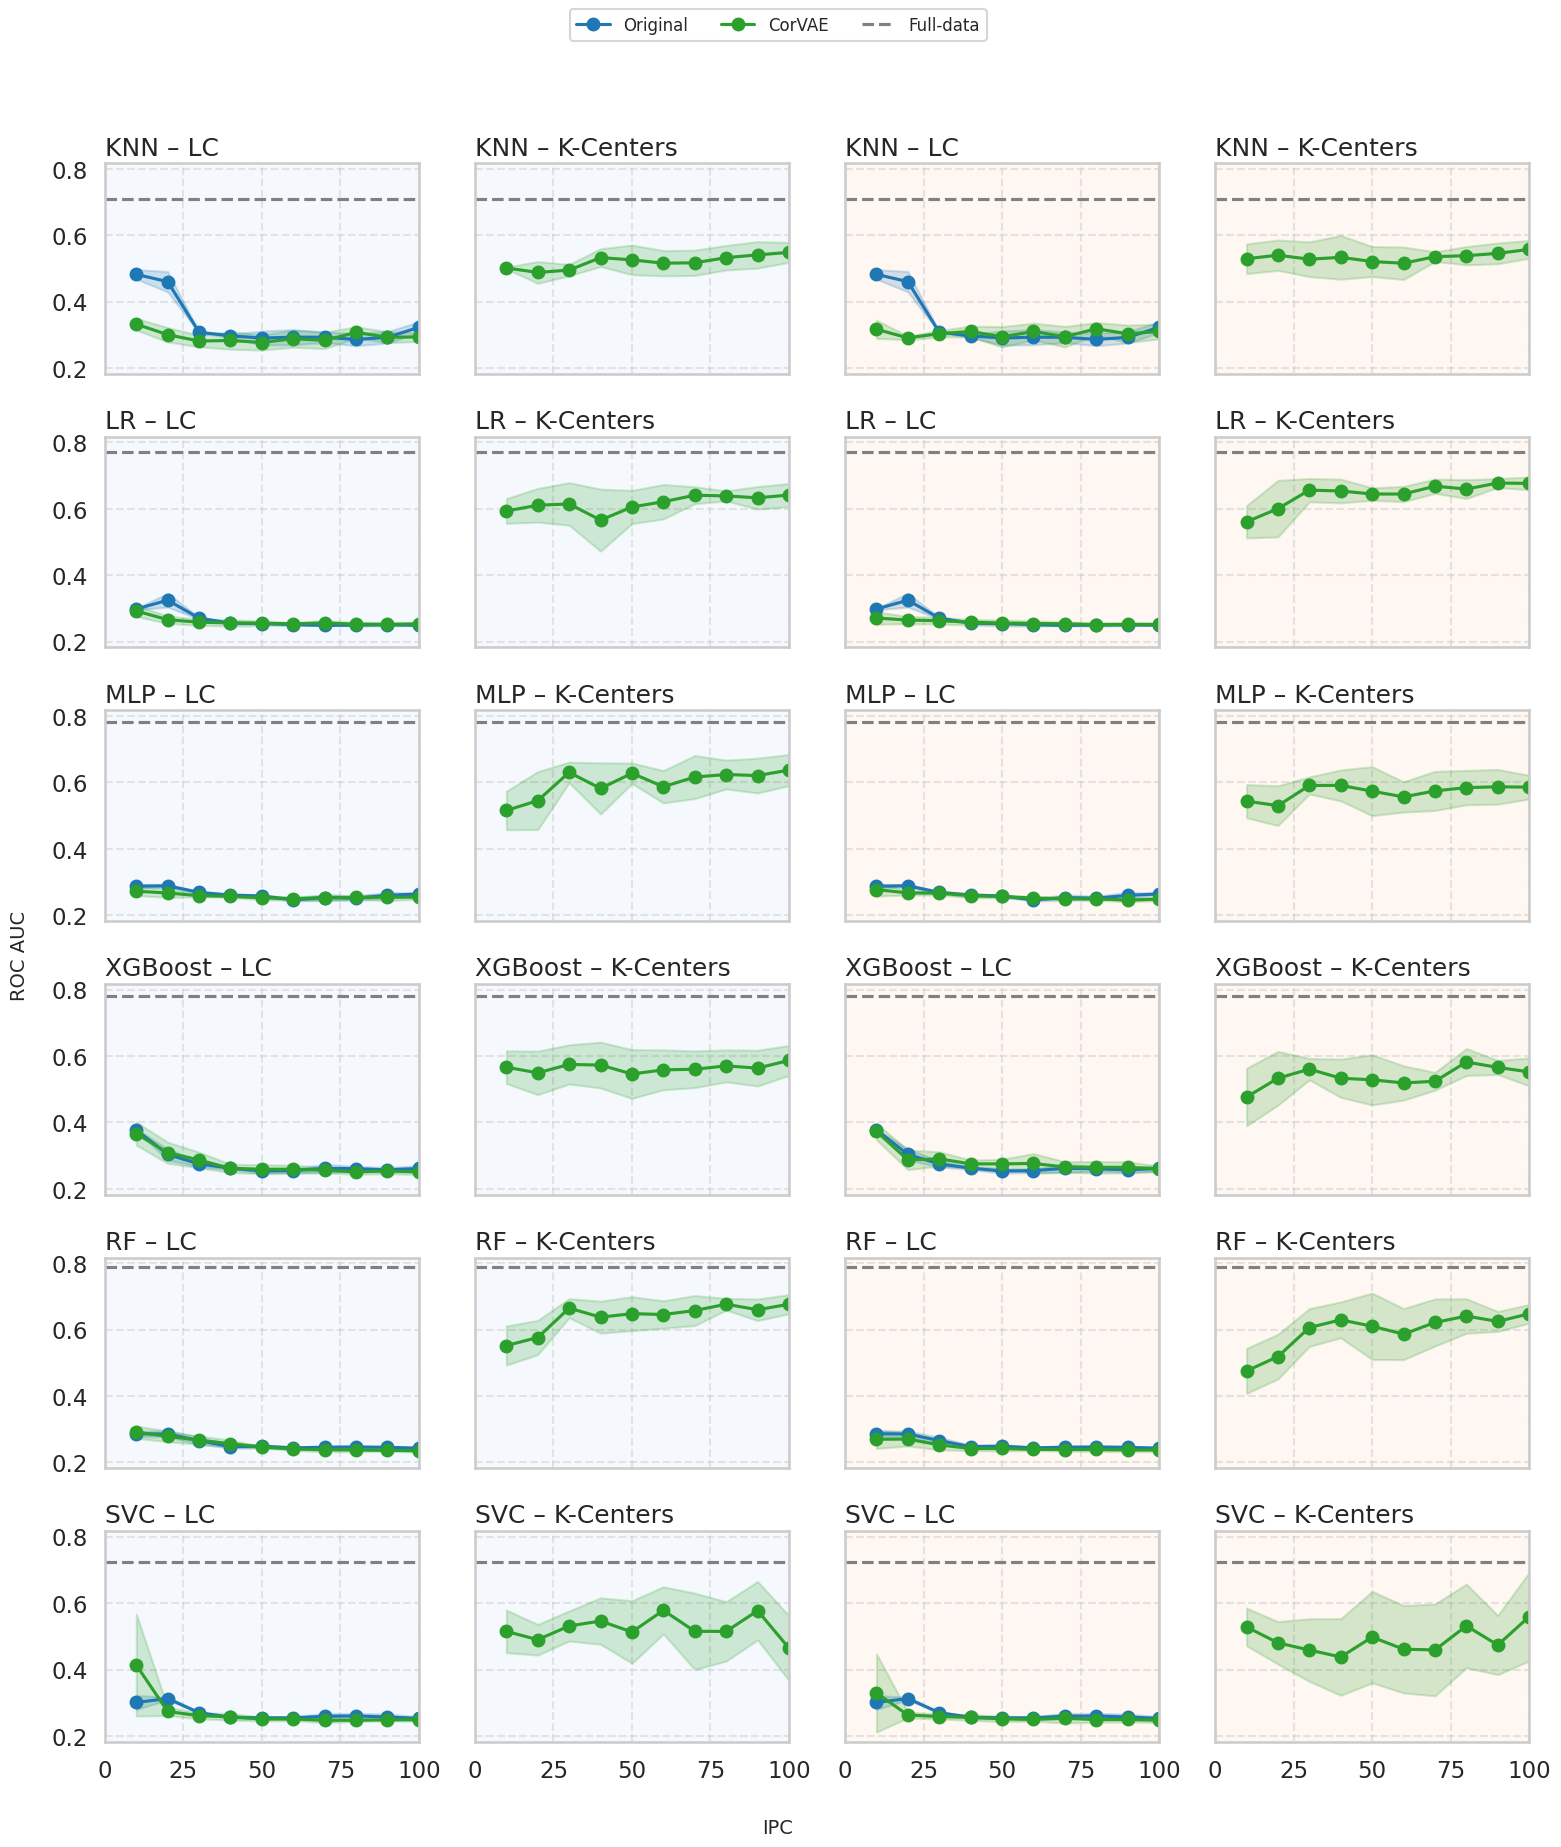

In [98]:
methods = ['lc','k-center']
models = ['knn','logreg','mlp','xgb','rf','svc']
compare_columns = df_full_default.columns

plot_metric_grid_all(
    df_full=df_full_default[compare_columns],
    df_only_coreset=df_only_coreset_default[compare_columns],
    df_latent=df_latent_default[compare_columns],
    df_latent_ft=df_latent_ft_default[compare_columns],
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='results/curve_figures/default_LC_KCENTERS_roc_auc.png'
)

### Calculo de métricas de eficiencia para default

  Model  VAE Inference (s)  Optuna Coreset (s)  Distillation Latente (s)  Optuna Full-data (s)
     LR           0.001963              7.2266                  0.704319                34.306
    MLP           0.001963              7.2313                  0.704319               213.389
     NB           0.001963              6.3193                  0.704319                13.921
     RF           0.001963             17.7141                  0.704319               387.816
XGBoost           0.001963              6.9897                  0.704319                56.426


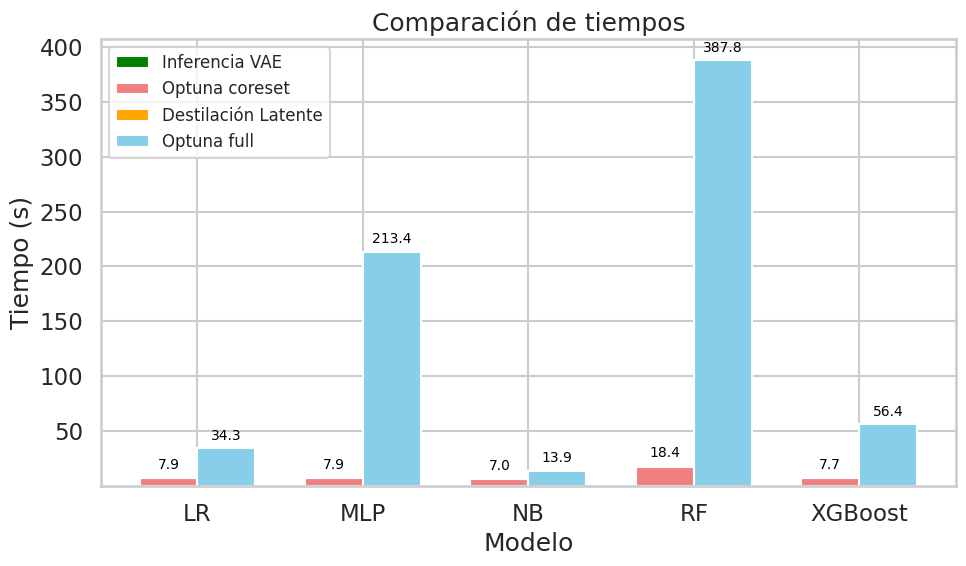

In [99]:
# 1) Filtrar y renombrar modelos
rename_map = {
    'rf': 'RF',
    'xgb': 'XGBoost',
    'mlp': 'MLP',
    'naive_bayes': 'NB',
    'logreg': 'LR'
}

# Full-data: filtrar y renombrar
df_full = (
    df_full_default
    .loc[~df_full_default['model'].isin(['svc', 'knn']), ['model', 'optuna_time']]
    .copy()
)
df_full['model'] = df_full['model'].replace(rename_map)
df_full = df_full.groupby('model', as_index=False)['optuna_time'].mean()

# Latent k-means IPC=10: filtrar, agrupar y renombrar
df_lat = (
    df_latent_default
    .loc[
        (df_latent_default['method'] == 'k-means') &
        (df_latent_default['IPC'] == 10) &
        (~df_latent_default['model'].isin(['svc', 'knn']))
    ]
    .copy()
)
df_lat = (
    df_lat
    .groupby('model', as_index=False)
    .agg({
        'encoder_inference_time': 'mean',
        'decoder_inference_time': 'mean',
        'optuna_time': 'mean',
        'destillation_time': 'mean'
    })
)
df_lat['model'] = df_lat['model'].replace(rename_map)

# 2) Componentes temporales
models      = df_lat['model'].tolist()
vae_inf     = df_lat['encoder_inference_time'] + df_lat['decoder_inference_time']
opt_coreset = df_lat['optuna_time']
dist_lat    = df_lat['destillation_time']
opt_full    = df_full.set_index('model').loc[models, 'optuna_time'].values

# 3) Mostrar tabla con los datos del gráfico
df_table = pd.DataFrame({
    'Model': models,
    'VAE Inference (s)': vae_inf,
    'Optuna Coreset (s)': opt_coreset,
    'Distillation Latente (s)': dist_lat,
    'Optuna Full-data (s)': opt_full
})
print(df_table.to_string(index=False))

# 4) Plot apilado vs full-data con etiquetas encima y negro
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

idx = np.arange(len(models))
width = 0.35

# Pipeline distil: VAE inf + Optuna coreset + Destillation Latente
bottom = np.zeros_like(vae_inf)
bars_inf = ax.bar(idx - width/2, vae_inf, width, label='Inferencia VAE', color='g')
bottom += vae_inf
bars_core = ax.bar(idx - width/2, opt_coreset, width, bottom=bottom, label='Optuna coreset', color='lightcoral')
bottom += opt_coreset
bars_dist = ax.bar(idx - width/2, dist_lat, width, bottom=bottom, label='Destilación Latente', color='orange')

# Optuna full-data
bars_full = ax.bar(idx + width/2, opt_full, width, label='Optuna full', color='skyblue')

# Añadir etiquetas encima de cada barra
for j in range(len(models)):
    total_pipeline = vae_inf[j] + opt_coreset[j] + dist_lat[j]
    ax.text(idx[j] - width/2, total_pipeline + 5, f"{total_pipeline:.1f}", ha='center', va='bottom', color='black', fontsize=10)
    ax.text(idx[j] + width/2, opt_full[j] + 5, f"{opt_full[j]:.1f}", ha='center', va='bottom', color='black', fontsize=10)

ax.set_xticks(idx)
ax.set_xticklabels(models)
ax.set_xlabel("Modelo")
ax.set_ylabel("Tiempo (s)")
ax.set_title("Comparación de tiempos")
ax.legend(fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.savefig('results/efficiency_figures/tiempos_comparacion_inferencia_modelos.png', dpi=300, bbox_inches='tight')
plt.show()


 VAE Inference (s)  Distillation Latente (s)  Distillation Original (s)
          0.001963                  0.704319                   1.334321


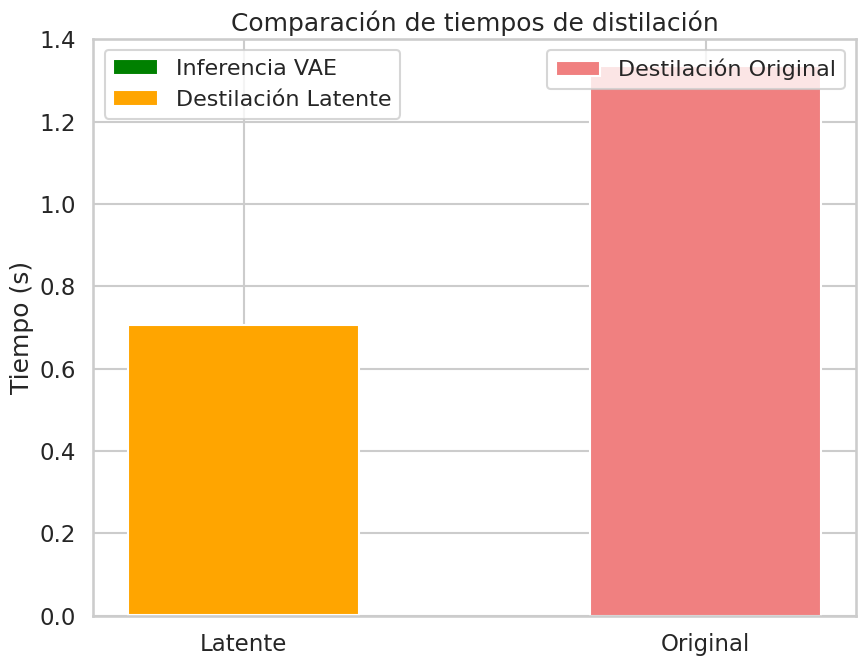

In [100]:
# 1) Filtrar tiempos para IPC=10 y método k-means, excluyendo svc/knn
df_lat = (
    df_latent_default
    .loc[
        (df_latent_default['method'] == 'k-means') &
        (df_latent_default['IPC'] == 10) &
        (~df_latent_default['model'].isin(['svc', 'knn']))
    ]
)
df_orig = (
    df_only_coreset_default
    .loc[
        (df_only_coreset_default['method'] == 'k-means') &
        (df_only_coreset_default['IPC'] == 10) &
        (~df_only_coreset_default['model'].isin(['svc', 'knn']))
    ]
)

# 2) Calcular medias globales
vae_inf_mean   = (df_lat['encoder_inference_time'] + df_lat['decoder_inference_time']).mean()
dist_lat_mean  = df_lat['destillation_time'].mean()
dist_orig_mean = df_orig['destillation_time'].mean()

# 3) Tabla resumen
df_summary = pd.DataFrame({
    'VAE Inference (s)': [vae_inf_mean],
    'Distillation Latente (s)': [dist_lat_mean],
    'Distillation Original (s)': [dist_orig_mean]
})
print(df_summary.to_string(index=False))

# 4) Gráfico de dos barras (apilada y simple) con leyendas separadas
labels = ['Latente', 'Original']
idx = np.arange(len(labels))
width = 0.5

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(9, 7))

# Barra 1: apilado VAE inf + distillation latente
ax.bar(idx[0], vae_inf_mean, width, color='g', label='Inferencia VAE')
ax.bar(idx[0], dist_lat_mean, width, bottom=vae_inf_mean, color='orange', label='Destilación Latente')

# Barra 2: distillation original
ax.bar(idx[1], dist_orig_mean, width, color='lightcoral', label='Destilación Original')

ax.set_xticks(idx)
ax.set_xticklabels(labels)
ax.set_ylabel("Tiempo (s)")
ax.set_title("Comparación de tiempos de distilación")

# Separar leyendas
handles, labels = ax.get_legend_handles_labels()
leg1 = ax.legend(handles[:2], labels[:2], title='', loc='upper left',                  
                 fontsize=16,
                 title_fontsize=16)
leg2 = ax.legend(handles[2:], labels[2:], title='', loc='upper right',              
                 fontsize=16,
                 title_fontsize=16)
ax.add_artist(leg1)

plt.tight_layout()
plt.savefig('results/efficiency_figures/tiempos_comparacion_destilacion.png', dpi=300, bbox_inches='tight')
plt.show()

   Bar  Entrenamiento VAE (s)  Inferencia VAE (s)  Destilación Latente (s)  Optuna Latente (s)  Optuna Full (s)
CorVAE              738.39774            0.001963                 0.704319              5.8459            0.000
  Full                0.00000            0.000000                 0.000000              0.0000        14212.953


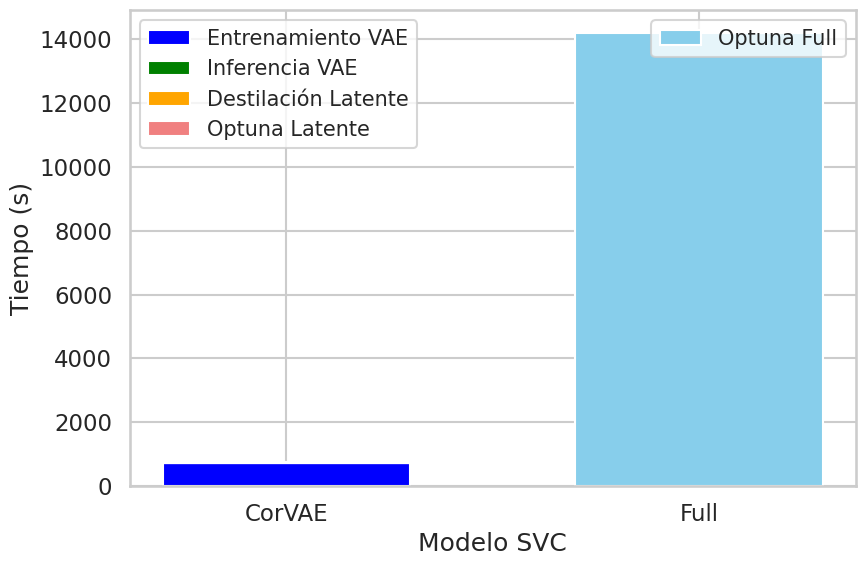

In [101]:

# 1) Extraer y promediar para SVC en espacio latente (IPC=10)
lat_svc = (
    df_latent_default
    .loc[
        (df_latent_default['model'] == 'svc') &
        (df_latent_default['method'] == 'k-means') &
        (df_latent_default['IPC'] == 10)
    ]
    .agg({
        'vae_pretrain_time': 'mean',
        'encoder_inference_time': 'mean',
        'decoder_inference_time': 'mean',
        'destillation_time': 'mean',
        'optuna_time': 'mean'
    })
)

# 2) Extraer Optuna full-data para SVC
full_svc = (
    df_full_default
    .loc[df_full_default['model'] == 'svc', 'optuna_time']
    .mean()
)

# 3) Construir tabla con dos barras
df_table = pd.DataFrame({
    'Bar': ['CorVAE', 'Full'],
    'Entrenamiento VAE (s)': [lat_svc['vae_pretrain_time'], 0.0],
    'Inferencia VAE (s)': [lat_svc['encoder_inference_time'] + lat_svc['decoder_inference_time'], 0.0],
    'Destilación Latente (s)': [lat_svc['destillation_time'], 0.0],
    'Optuna Latente (s)': [lat_svc['optuna_time'], 0.0],
    'Optuna Full (s)': [0.0, full_svc]
})
print(df_table.to_string(index=False))

# 4) Plot
sns.set_style("whitegrid")
plt.figure(figsize=(9, 6))
bars = df_table['Bar']
idx = np.arange(len(bars))
width = 0.6

# Barra 1: CorVAE pipeline
bottom = 0
plt.bar(idx[0], df_table.loc[0, 'Entrenamiento VAE (s)'], width, color='b', label='Entrenamiento VAE')
bottom += df_table.loc[0, 'Entrenamiento VAE (s)']
plt.bar(idx[0], df_table.loc[0, 'Inferencia VAE (s)'], width, bottom=bottom, color='g', label='Inferencia VAE')
bottom += df_table.loc[0, 'Inferencia VAE (s)']
plt.bar(idx[0], df_table.loc[0, 'Destilación Latente (s)'], width, bottom=bottom, color='orange', label='Destilación Latente')
bottom += df_table.loc[0, 'Destilación Latente (s)']
plt.bar(idx[0], df_table.loc[0, 'Optuna Latente (s)'], width, bottom=bottom, color='lightcoral', label='Optuna Latente')

# Barra 2: Optuna full
plt.bar(idx[1], df_table.loc[1, 'Optuna Full (s)'], width, color='skyblue', label='Optuna Full')

plt.xticks(idx, bars)
plt.xlabel("Modelo SVC")
plt.ylabel("Tiempo (s)")

# Separar leyendas
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
# Filtramos
handles_left = [h for h, lab in zip(handles, labels) if lab != 'Optuna Full']
labels_letabla = summarize_two_metrics(
    ipc=10,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_default,
    df_latent=df_latent_default,
    df_tdcoler=df_tdcoler_latent_default,
    df_latent_ft=None
)
tablaft  = [lab for lab in labels if lab != 'Optuna Full']
handles_right = [h for h, lab in zip(handles, labels) if lab == 'Optuna Full']
labels_left = [lab for lab in labels if lab != 'Optuna Full']
labels_right  = ['Optuna Full']

leg1 = ax.legend(handles_left, labels_left, title='', loc='upper left', fontsize='small', title_fontsize='small')
leg2 = ax.legend(handles_right, labels_right, title='', loc='upper right', fontsize='small', title_fontsize='small')
ax.add_artist(leg1)

plt.tight_layout()
plt.savefig('results/efficiency_figures/tiempos_comparacion_entrenamiento.png', dpi=300, bbox_inches='tight')
plt.show()

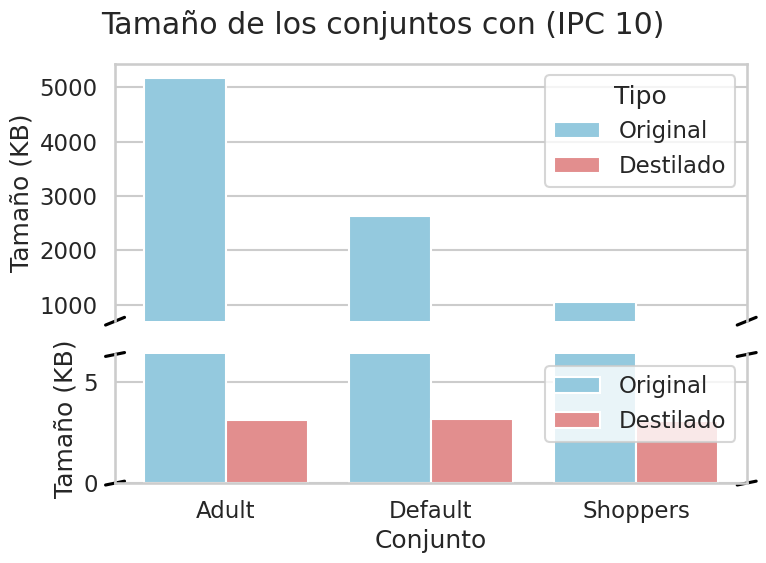

In [112]:
# Informacion para calcular el tamaño de los conjuntos de datos destilados y originales

import os
import glob

# Rutas a los archivos CSV
paths = {
    'Adult': {
        'Original': 'data/adult/dataset.csv',
        'Destilado': 'results/checkpoint/checkpoint_adult_Dlatent_G/vae/reconstructed_data/IPC_10/method_k-means_seed_5.csv'
    },
    'Default': {
        'Original': 'data/default/dataset.csv',
        'Destilado': 'results/checkpoint/checkpoint_default_Dlatent_G/vae/reconstructed_data/IPC_10/method_k-means_seed_5.csv'
    },
    'Shoppers': {
        'Original': 'data/shoppers/dataset.csv',
        'Destilado': 'results/checkpoint/checkpoint_shoppers_Dlatent_F/vae/reconstructed_data/IPC_10/method-kmeans_seed_5.csv'
    }
}

def resolve_csv(path_template):
    """
    Si el path exacto no existe, busca cualquier .csv en la carpeta padre y devuelve el primero.
    """
    if os.path.exists(path_template):
        return path_template
    parent = os.path.dirname(path_template)
    candidates = glob.glob(os.path.join(parent, '*.csv'))
    if candidates:
        return candidates[0]
    raise FileNotFoundError(f"No se encontró CSV en {parent}")

# 1) Calcular tamaños
records = []
for ds, variants in paths.items():
    for tipo, fp in variants.items():
        real_fp = resolve_csv(fp)
        size_kb = os.path.getsize(real_fp) / 1024
        records.append({'Conjunto': ds, 'Tipo': tipo, 'Tamaño_KB': size_kb})

df_sizes = pd.DataFrame(records)

# 2) Preparar ejes rotos con corte en 1000 KB
max_small = df_sizes.loc[df_sizes.Tipo=='Destilado','Tamaño_KB'].max()
max_big   = df_sizes.loc[df_sizes.Tipo=='Original','Tamaño_KB'].max()

sns.set_style("whitegrid")
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True,
    gridspec_kw={'height_ratios': [2, 1]},
    figsize=(8, 6)
)

ax_bot.set_ylim(0, max_small * 2)
ax_top.set_ylim(700, max_big * 1.05)

# Ocultar líneas de corte
ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)
ax_top.tick_params(labeltop=False)

# 3) Dibujar barplots
palette = {'Original':'skyblue','Destilado':'lightcoral'}
sns.barplot(data=df_sizes, x='Conjunto', y='Tamaño_KB', hue='Tipo',
            palette=palette, dodge=True, ax=ax_top)
sns.barplot(data=df_sizes, x='Conjunto', y='Tamaño_KB', hue='Tipo',
            palette=palette, dodge=True, ax=ax_bot)

# 4) Añadir zigzag en los ejes
d = .015
for ax in (ax_top, ax_bot):
    ax.plot((-d, +d), (-d, +d), transform=ax.transAxes, color='k', clip_on=False)
    ax.plot((1-d, 1+d), (-d, +d), transform=ax.transAxes, color='k', clip_on=False)
ax_bot.plot((-d, +d), (1-d, 1+d), transform=ax_bot.transAxes, color='k', clip_on=False)
ax_bot.plot((1-d, 1+d), (1-d, 1+d), transform=ax_bot.transAxes, color='k', clip_on=False)

# 5) Ajustes finales
ax_bot.set_xlabel('Conjunto')
ax_bot.set_ylabel('Tamaño (KB)')
ax_top.set_ylabel('Tamaño (KB)')
ax_bot.legend(loc='upper right')
plt.suptitle('Tamaño de los conjuntos con (IPC 10)', y=0.95)
plt.tight_layout()
plt.savefig('results/efficiency_figures/comparacion_tamanos_conjuntos_destilados.png', dpi=300, bbox_inches='tight')
plt.show()

## Dataset shopper

In [17]:
df_only_coreset_shoppers = pd.read_csv('results/checkpoint/checkpoint_shoppers_Doriginal_F/metrics.csv')

df_full_shoppers = df_only_coreset_shoppers[df_only_coreset_shoppers['method'] == 'Full-data']
df_latent_shoppers = pd.read_csv('results/checkpoint/checkpoint_shoppers_Dlatent_F/metrics.csv')
df_latent_ft_shoppers = pd.read_csv('results/checkpoint/checkpoint_shoppers_Dlatent_ft_F/metrics.csv')

In [18]:
# Información de la evaluación con todos los datos
df_full_shoppers[['model','method','test_balanced','test_roc_auc']]

,model,method,test_balanced,test_roc_auc
0,xgb,Full-data,0.769,0.930
1,rf,Full-data,0.860,0.923
2,svc,Full-data,0.771,0.885
3,logreg,Full-data,0.702,0.902
4,mlp,Full-data,0.774,0.921
5,naive_bayes,Full-data,0.567,0.754
6,knn,Full-data,0.686,0.782


### Calculo de tablas con valor de IPC

In [104]:
tabla = summarize_two_metrics(
    ipc=10,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_shoppers,
    df_latent=df_latent_shoppers,
    df_tdcoler=pd.DataFrame(),  # No TDColer para shoppers
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.783±0.024   
1             CorVAE       Latente  Perceptrón Multicapa   0.747±0.018   
2             CorVAE       Latente     Ingenuo Bayesiano   0.720±0.073   
3             CorVAE       Latente      Bosque Aleatorio   0.812±0.013   
4             CorVAE       Latente                   svc   0.764±0.054   
5             CorVAE       Latente               XGBoost   0.764±0.078   
6             CorVAE  Reconstruido   Regresión Logística   0.795±0.017   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.782±0.013   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.649±0.069   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.728±0.015   
10            CorVAE  Reconstruido                   svc   0.797±0.022   
11            CorVAE  Reconstruido               XGBoost   0.785±0.074   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.791±0.015   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.753±0.010   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.585±0.002   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.680±0.029   
16      Sólo Coreset  Reconstruido                   svc   0.680±0.152   
17      Sólo Coreset  Reconstruido               XGBoost   0.756±0.082   

                                                           test_roc_auc  \
method     K-center           KM     k_center           LC           AG   
0       0.492±0.004  0.788±0.036          NaN  0.275±0.024  0.865±0.029   
1       0.558±0.042  0.748±0.031          NaN  0.293±0.029  0.829±0.028   
2       0.584±0.078  0.642±0.061          NaN  0.301±0.051  0.740±0.087   
3       0.567±0.113  0.809±0.018          NaN  0.241±0.032  0.881±0.013   
4       0.499±0.003  0.789±0.050          NaN  0.298±0.050  0.637±0.343   
5       0.672±0.087  0.783±0.069          NaN  0.348±0.050  0.799±0.076   
6       0.490±0.003  0.798±0.014          NaN  0.248±0.036  0.882±0.012   
7       0.579±0.055  0.778±0.024          NaN  0.257±0.027  0.873±0.009   
8       0.559±0.043  0.627±0.034          NaN  0.411±0.045  0.659±0.079   
9       0.542±0.029  0.741±0.027          NaN  0.290±0.021  0.816±0.013   
10      0.498±0.003  0.816±0.019          NaN  0.266±0.037  0.896±0.014   
11      0.690±0.133  0.770±0.085          NaN  0.321±0.051  0.860±0.040   
12              NaN  0.804±0.006  0.489±0.006  0.449±0.008  0.875±0.016   
13              NaN  0.758±0.010  0.553±0.032  0.289±0.016  0.829±0.012   
14              NaN  0.583±0.019  0.468±0.016  0.340±0.001  0.587±0.001   
15              NaN  0.543±0.090  0.497±0.017  0.328±0.010  0.835±0.028   
16              NaN  0.647±0.154  0.500±0.000  0.418±0.038  0.641±0.340   
17              NaN  0.815±0.007  0.680±0.180  0.399±0.049  0.849±0.050   

                                                            
method     K-center           KM     k_center           LC  
0       0.496±0.030  0.872±0.031          NaN  0.185±0.033  
1       0.601±0.037  0.827±0.035          NaN  0.225±0.027  
2       0.623±0.128  0.647±0.066          NaN  0.273±0.054  
3       0.701±0.101  0.885±0.020          NaN  0.155±0.025  
4       0.468±0.025  0.751±0.290          NaN  0.294±0.199  
5       0.732±0.096  0.823±0.053          NaN  0.284±0.081  
6       0.514±0.051  0.883±0.013          NaN  0.127±0.010  
7       0.645±0.071  0.859±0.023          NaN  0.180±0.025  
8       0.553±0.041  0.637±0.038          NaN  0.400±0.042  
9       0.692±0.076  0.826±0.022          NaN  0.194±0.021  
10      0.441±0.071  0.895±0.011          NaN  0.250±0.251  
11      0.702±0.160  0.859±0.046          NaN  0.227±0.067  
12              NaN  0.878±0.006  0.473±0.035  0.108±0.008  
13              NaN  0.842±0.008  0.622±0.063  0.177±0.005  
14              NaN  0.587±0.022  0.488±0.019  0.374±

In [105]:
tabla = summarize_two_metrics(
    ipc=50,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_shoppers,
    df_latent=df_latent_shoppers,
    df_tdcoler=pd.DataFrame(),  # No TDColer para shoppers
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.776±0.049   
1             CorVAE       Latente  Perceptrón Multicapa   0.784±0.023   
2             CorVAE       Latente     Ingenuo Bayesiano   0.748±0.044   
3             CorVAE       Latente      Bosque Aleatorio   0.825±0.005   
4             CorVAE       Latente                   svc   0.803±0.023   
5             CorVAE       Latente               XGBoost   0.824±0.005   
6             CorVAE  Reconstruido   Regresión Logística   0.813±0.006   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.813±0.015   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.641±0.044   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.801±0.019   
10            CorVAE  Reconstruido                   svc   0.829±0.007   
11            CorVAE  Reconstruido               XGBoost   0.818±0.005   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.638±0.032   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.746±0.025   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.547±0.004   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.625±0.046   
16      Sólo Coreset  Reconstruido                   svc   0.755±0.005   
17      Sólo Coreset  Reconstruido               XGBoost   0.794±0.003   

                                                           test_roc_auc  \
method     K-center           KM     k_center           LC           AG   
0       0.580±0.042  0.805±0.011          NaN  0.230±0.012  0.858±0.054   
1       0.620±0.048  0.796±0.018          NaN  0.270±0.009  0.869±0.018   
2       0.581±0.022  0.771±0.028          NaN  0.210±0.021  0.818±0.037   
3       0.805±0.045  0.818±0.010          NaN  0.222±0.047  0.896±0.007   
4       0.493±0.005  0.821±0.013          NaN  0.235±0.014  0.884±0.018   
5       0.795±0.052  0.822±0.006          NaN  0.230±0.077  0.869±0.030   
6       0.533±0.046  0.812±0.008          NaN  0.226±0.027  0.894±0.011   
7       0.603±0.015  0.794±0.013          NaN  0.244±0.019  0.887±0.008   
8       0.527±0.025  0.686±0.022          NaN  0.340±0.046  0.681±0.030   
9       0.807±0.033  0.795±0.015          NaN  0.241±0.030  0.875±0.008   
10      0.559±0.074  0.812±0.010          NaN  0.224±0.020  0.898±0.010   
11      0.779±0.067  0.819±0.007          NaN  0.252±0.064  0.883±0.005   
12              NaN  0.680±0.067  0.553±0.041  0.335±0.015  0.680±0.047   
13              NaN  0.770±0.017  0.608±0.040  0.267±0.005  0.813±0.016   
14              NaN  0.582±0.021  0.527±0.028  0.261±0.000  0.548±0.002   
15              NaN  0.500±0.000  0.739±0.037  0.256±0.008  0.875±0.009   
16              NaN  0.781±0.016  0.504±0.023  0.300±0.017  0.838±0.009   
17              NaN  0.563±0.105  0.737±0.025  0.219±0.018  0.882±0.006   

                                                            
method     K-center           KM     k_center           LC  
0       0.694±0.041  0.889±0.010          NaN  0.138±0.019  
1       0.714±0.065  0.877±0.017          NaN  0.188±0.023  
2       0.776±0.038  0.823±0.028          NaN  0.157±0.026  
3       0.876±0.020  0.893±0.005          NaN  0.107±0.007  
4       0.336±0.127  0.892±0.013          NaN  0.140±0.012  
5       0.862±0.034  0.870±0.014          NaN  0.155±0.021  
6       0.687±0.031  0.889±0.008          NaN  0.105±0.012  
7       0.734±0.031  0.878±0.009          NaN  0.166±0.019  
8       0.587±0.034  0.737±0.039          NaN  0.253±0.050  
9       0.879±0.014  0.872±0.006          NaN  0.131±0.014  
10      0.369±0.193  0.885±0.011          NaN  0.108±0.013  
11      0.863±0.024  0.882±0.011          NaN  0.115±0.021  
12              NaN  0.748±0.077  0.601±0.008  0.099±0.009  
13              NaN  0.856±0.028  0.681±0.050  0.146±0.008  
14              NaN  0.572±0.029  0.559±0.030  0.218±

In [106]:
tabla = summarize_two_metrics(
    ipc=100,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_shoppers,
    df_latent=df_latent_shoppers,
    df_tdcoler=pd.DataFrame(),  # No TDColer para shoppers
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.806±0.009   
1             CorVAE       Latente  Perceptrón Multicapa   0.799±0.012   
2             CorVAE       Latente     Ingenuo Bayesiano   0.738±0.036   
3             CorVAE       Latente      Bosque Aleatorio   0.832±0.005   
4             CorVAE       Latente                   svc   0.817±0.010   
5             CorVAE       Latente               XGBoost   0.834±0.005   
6             CorVAE  Reconstruido   Regresión Logística   0.821±0.005   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.812±0.011   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.640±0.033   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.815±0.006   
10            CorVAE  Reconstruido                   svc   0.828±0.009   
11            CorVAE  Reconstruido               XGBoost   0.826±0.005   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.651±0.024   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.766±0.009   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.558±0.007   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.734±0.020   
16      Sólo Coreset  Reconstruido                   svc   0.774±0.005   
17      Sólo Coreset  Reconstruido               XGBoost   0.806±0.017   

                                                           test_roc_auc  \
method     K-center           KM     k_center           LC           AG   
0       0.641±0.059  0.802±0.021          NaN  0.221±0.022  0.884±0.013   
1       0.628±0.030  0.802±0.006          NaN  0.232±0.012  0.880±0.006   
2       0.594±0.021  0.762±0.022          NaN  0.177±0.022  0.817±0.032   
3       0.833±0.003  0.829±0.006          NaN  0.207±0.037  0.898±0.006   
4       0.616±0.038  0.818±0.006          NaN  0.221±0.025  0.888±0.010   
5       0.785±0.031  0.826±0.004          NaN  0.201±0.024  0.892±0.009   
6       0.602±0.025  0.820±0.002          NaN  0.219±0.027  0.896±0.010   
7       0.649±0.020  0.805±0.015          NaN  0.220±0.009  0.892±0.005   
8       0.533±0.017  0.691±0.026          NaN  0.368±0.035  0.719±0.021   
9       0.826±0.015  0.811±0.013          NaN  0.237±0.049  0.882±0.003   
10      0.582±0.083  0.823±0.007          NaN  0.223±0.029  0.900±0.006   
11      0.804±0.043  0.824±0.007          NaN  0.217±0.045  0.890±0.013   
12              NaN  0.755±0.025  0.557±0.074  0.289±0.009  0.708±0.029   
13              NaN  0.774±0.004  0.613±0.035  0.248±0.009  0.845±0.015   
14              NaN  0.574±0.014  0.551±0.018  0.253±0.003  0.574±0.007   
15              NaN  0.500±0.000  0.799±0.027  0.245±0.006  0.897±0.004   
16              NaN  0.768±0.018  0.532±0.074  0.262±0.010  0.847±0.006   
17              NaN  0.504±0.011  0.781±0.016  0.215±0.006  0.897±0.002   

                                                            
method     K-center           KM     k_center           LC  
0       0.762±0.052  0.887±0.020          NaN  0.112±0.008  
1       0.731±0.033  0.891±0.010          NaN  0.144±0.006  
2       0.776±0.022  0.843±0.016          NaN  0.124±0.030  
3       0.896±0.008  0.899±0.010          NaN  0.103±0.005  
4       0.703±0.119  0.893±0.016          NaN  0.109±0.007  
5       0.864±0.026  0.889±0.024          NaN  0.169±0.025  
6       0.740±0.046  0.896±0.008          NaN  0.093±0.003  
7       0.774±0.016  0.888±0.008          NaN  0.115±0.010  
8       0.624±0.039  0.748±0.030          NaN  0.194±0.058  
9       0.891±0.009  0.880±0.004          NaN  0.110±0.006  
10      0.500±0.298  0.896±0.008          NaN  0.093±0.003  
11      0.870±0.028  0.885±0.026          NaN  0.106±0.005  
12              NaN  0.834±0.022  0.665±0.018  0.085±0.007  
13              NaN  0.855±0.007  0.701±0.038  0.113±0.006  
14              NaN  0.576±0.010  0.611±0.007  0.164±

### Calculo de métricas de eficiencia para shopper

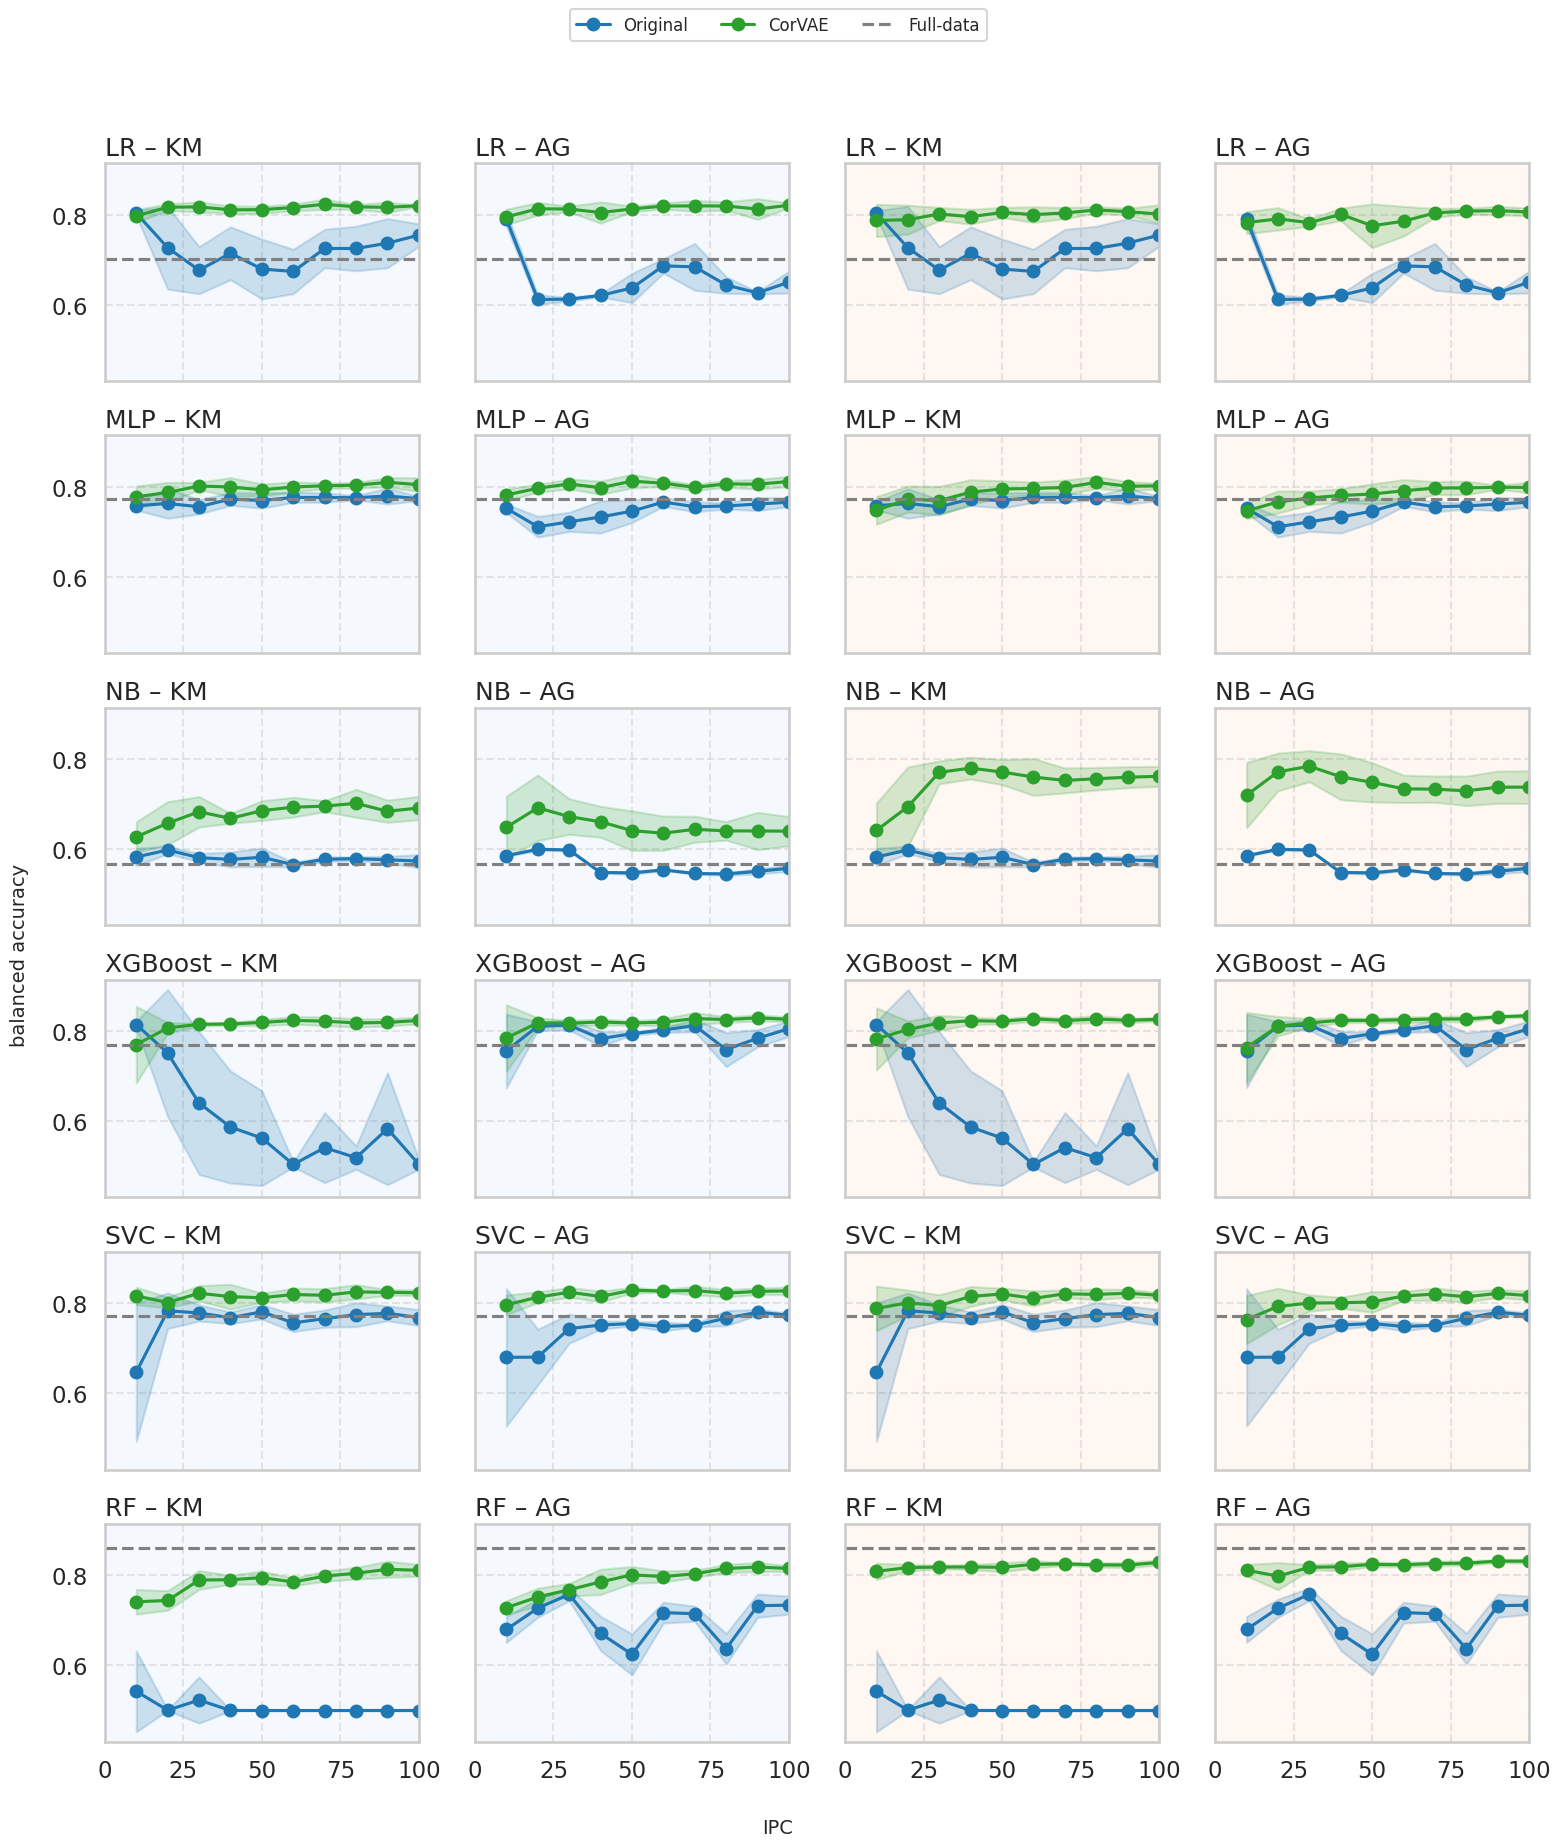

In [107]:
methods = ['k-means','ag']
models = ['logreg','mlp','naive_bayes','xgb','svc','rf']

compare_columns = df_full_shoppers.columns

plot_metric_grid_all(
    df_full=df_full_shoppers[compare_columns],
    df_only_coreset=df_only_coreset_shoppers[compare_columns],
    df_latent=df_latent_shoppers[compare_columns],
    df_latent_ft=df_latent_ft_shoppers[compare_columns],
    #df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='results/curve_figures/shopper_KM_AG_balanced_accuracy.png'
)

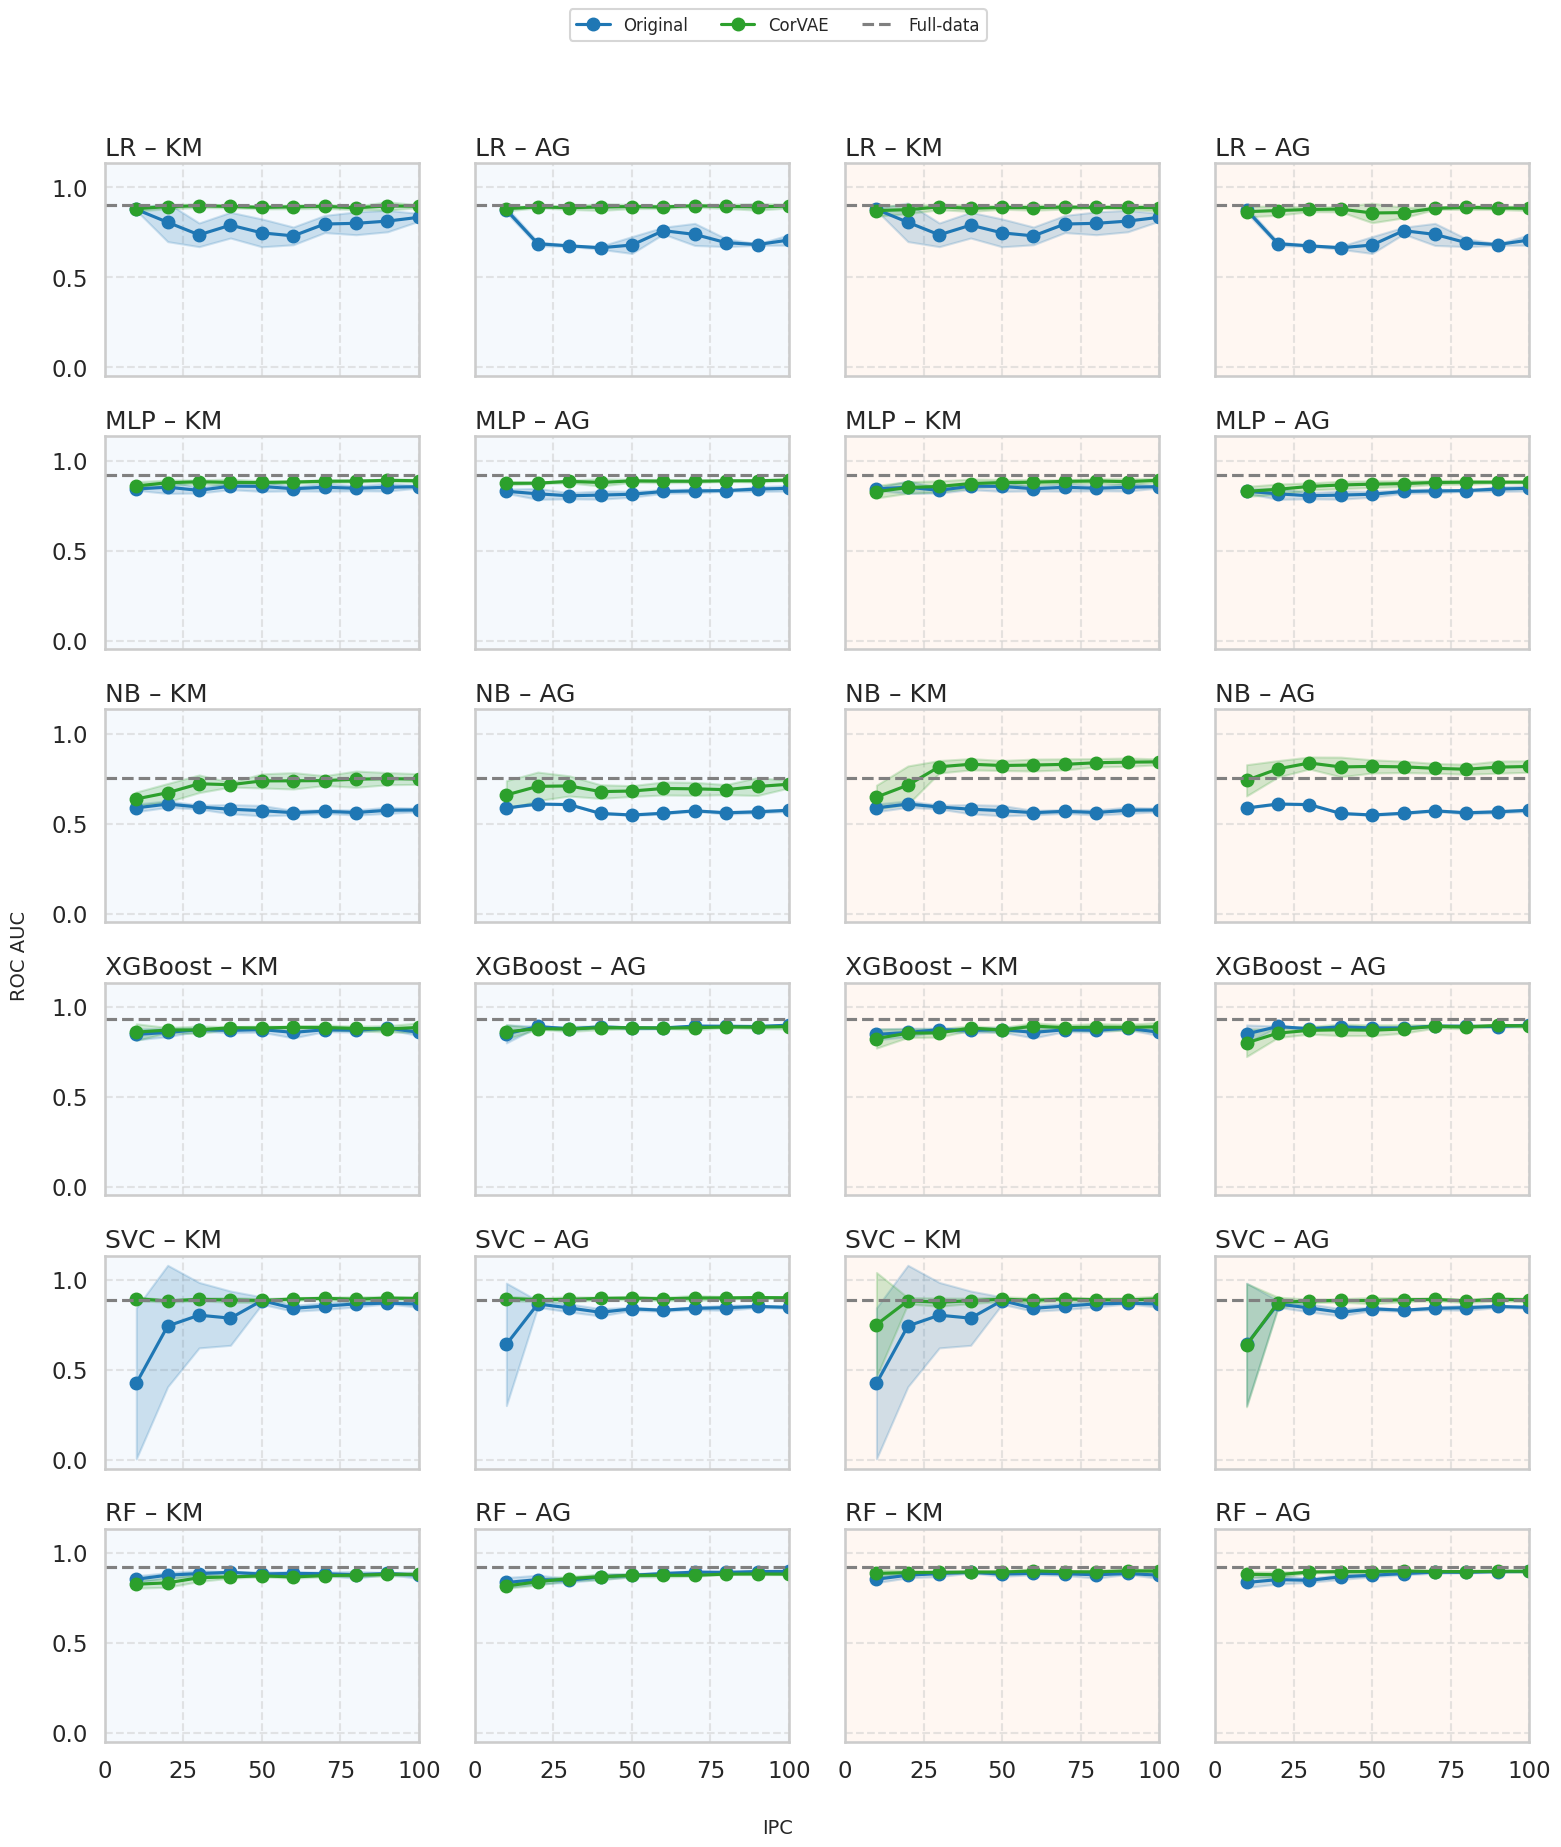

In [108]:
methods = ['k-means','ag']
models =['logreg','mlp','naive_bayes','xgb','svc','rf']
compare_columns = df_full_shoppers.columns

plot_metric_grid_all(
    df_full=df_full_shoppers[compare_columns],
    df_only_coreset=df_only_coreset_shoppers[compare_columns],
    df_latent=df_latent_shoppers[compare_columns],
    df_latent_ft=df_latent_ft_shoppers[compare_columns],
    #df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/shoppers_KM_AG_roc_auc.png'
)

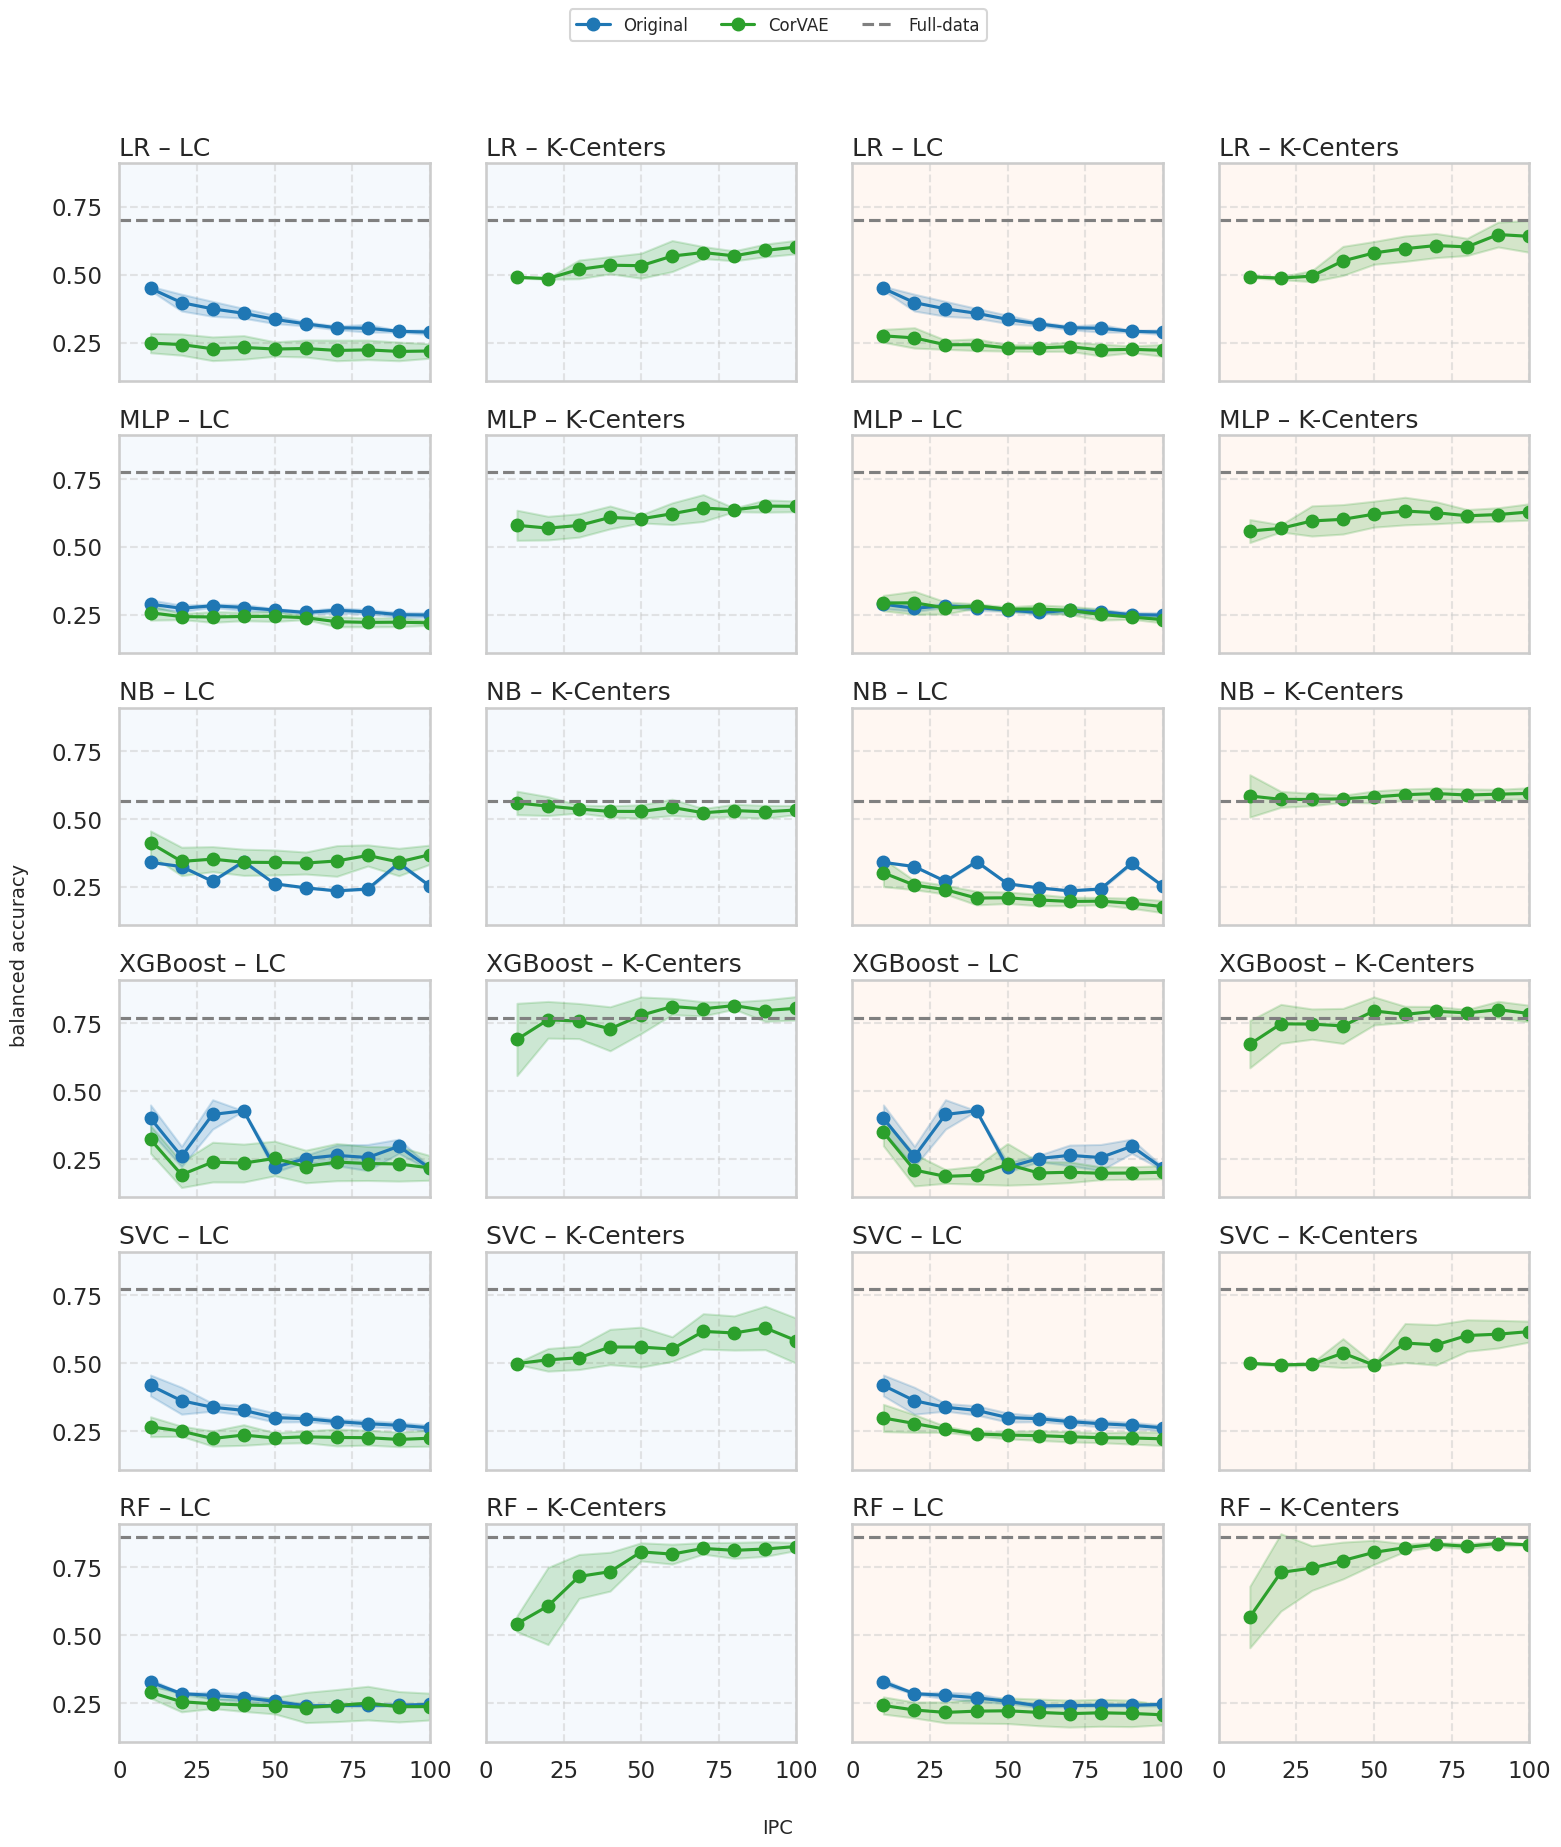

In [109]:
methods = ['lc','k-center']
models = ['logreg','mlp','naive_bayes','xgb','svc','rf']
compare_columns = df_full_shoppers.columns

plot_metric_grid_all(
    df_full=df_full_shoppers[compare_columns],
    df_only_coreset=df_only_coreset_shoppers[compare_columns],
    df_latent=df_latent_shoppers[compare_columns],
    df_latent_ft=df_latent_ft_shoppers[compare_columns],
    #df_TDColer=df_tdcoler_latent_shoppers,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/shoppers_LC_KCENTERS_balanced_accuracy.png'
)

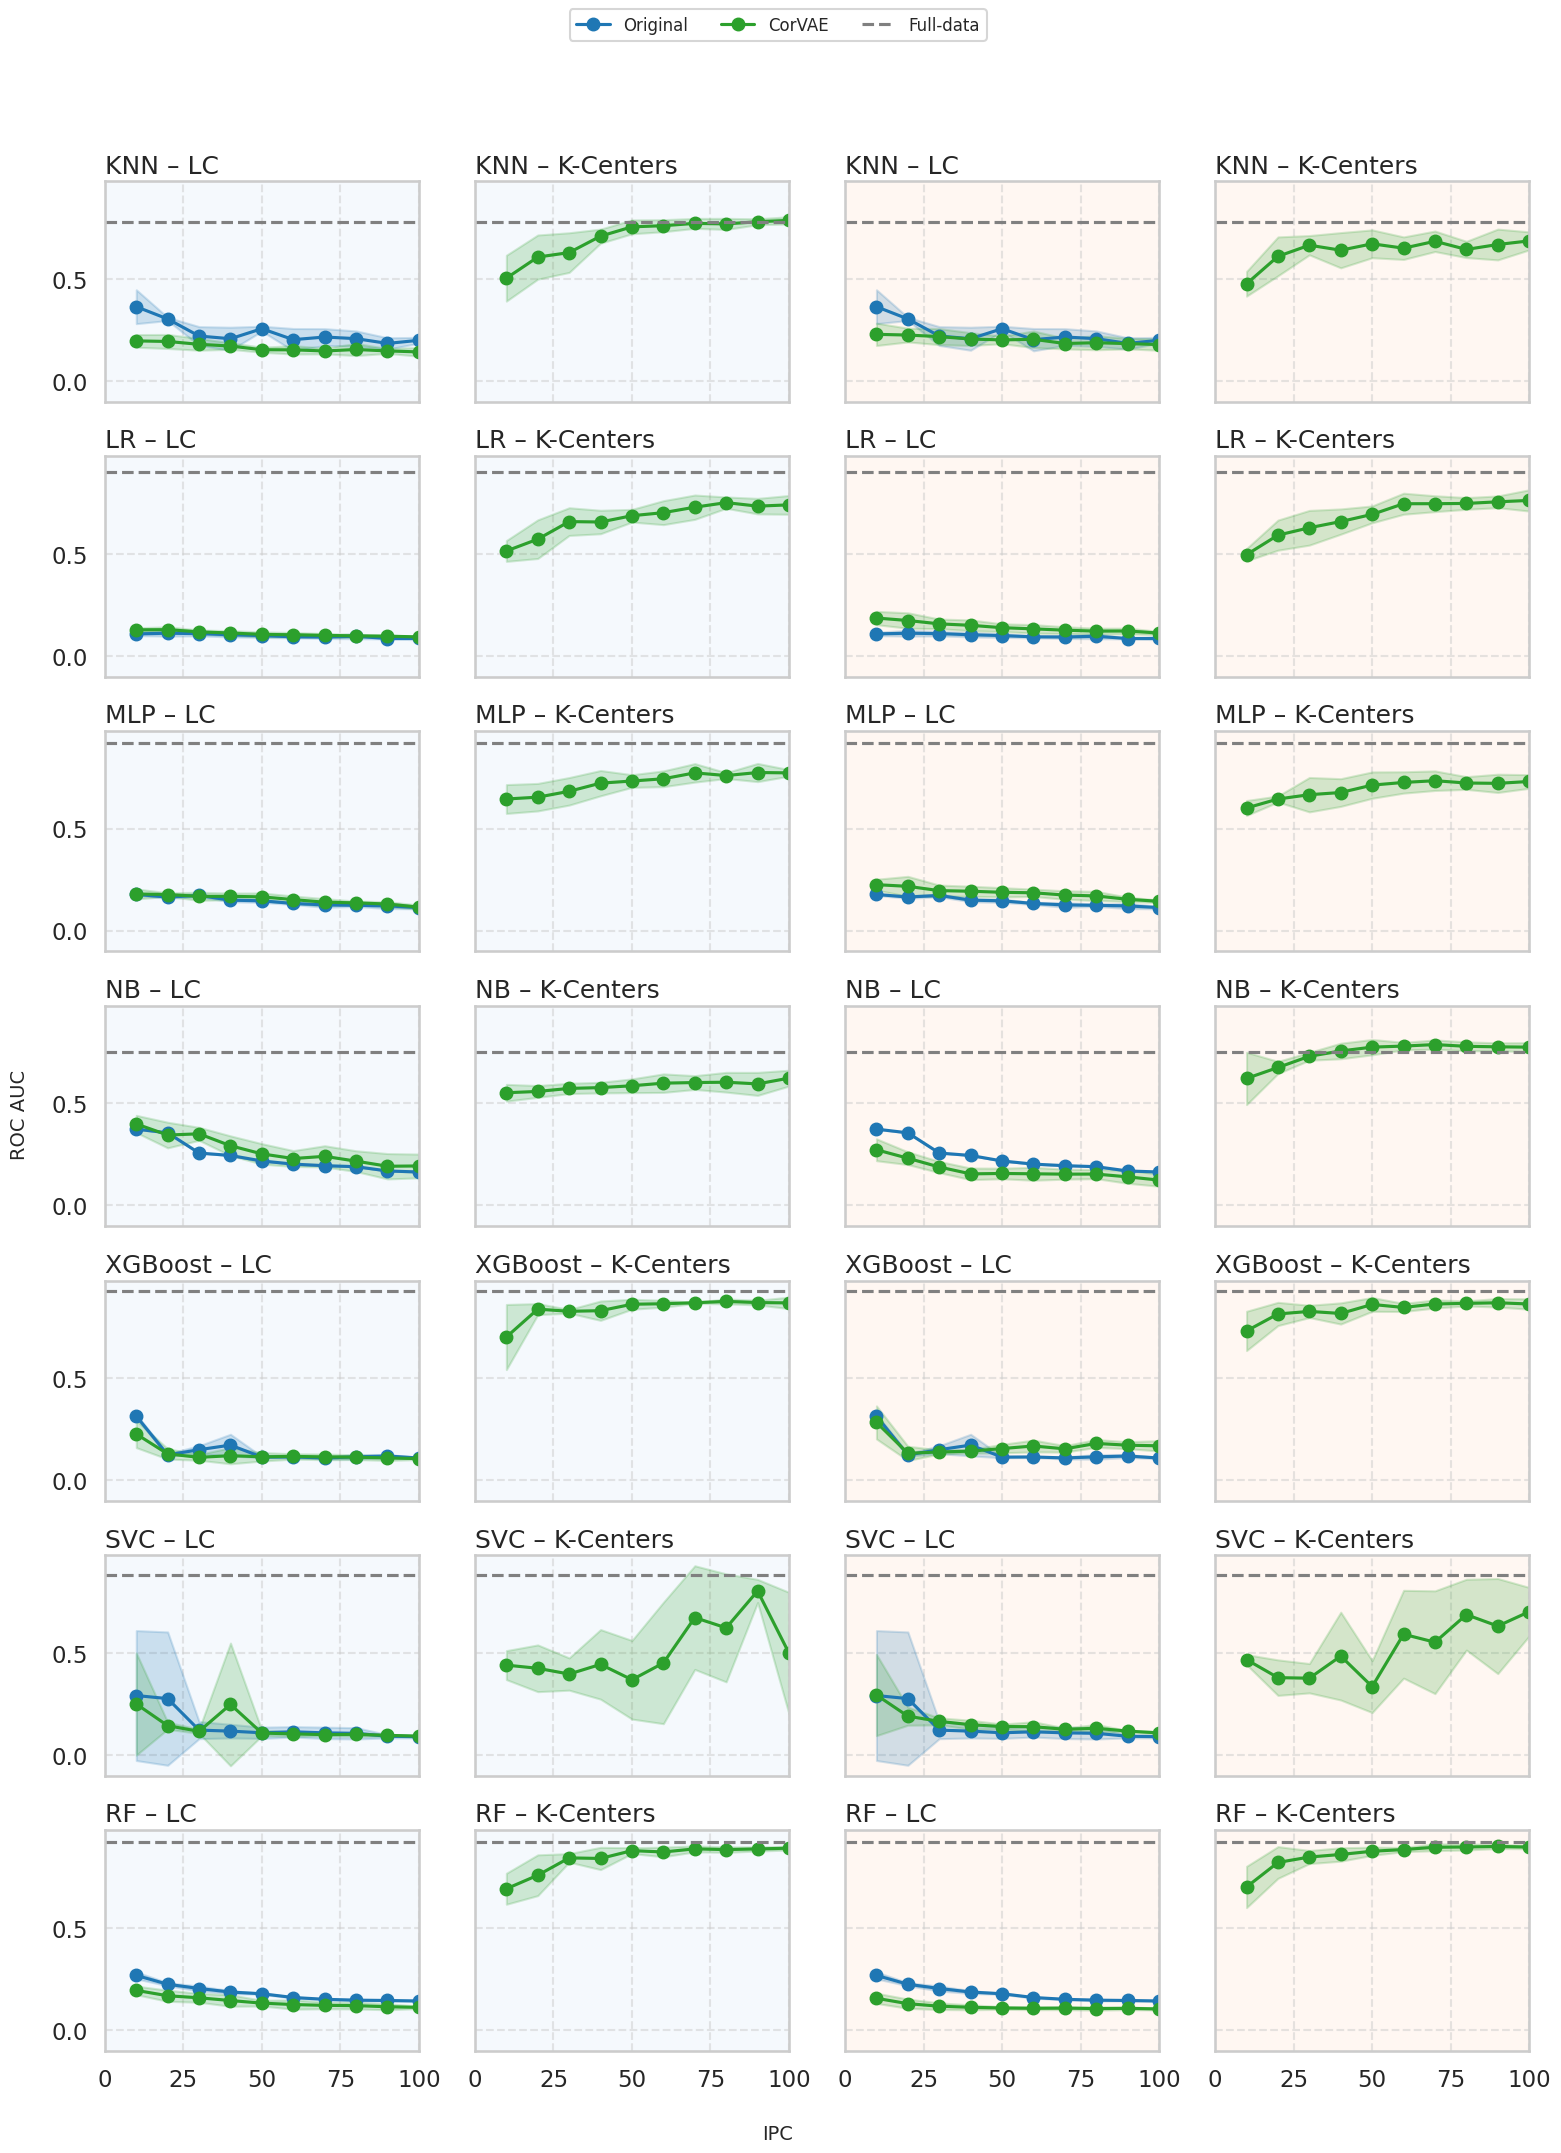

In [110]:
methods = ['lc','k-center']
models = ['knn','logreg','mlp','naive_bayes','xgb','svc','rf']
compare_columns = df_full_shoppers.columns

plot_metric_grid_all(
    df_full=df_full_shoppers[compare_columns],
    df_only_coreset=df_only_coreset_shoppers[compare_columns],
    df_latent=df_latent_shoppers[compare_columns],
    df_latent_ft=df_latent_ft_shoppers[compare_columns],
    #df_TDColer=df_tdcoler_latent_shoppers,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/shoppers_LC_KCENTERS_roc_auc.png'
)

## Explicabilidad de eficiencia del espacio latente para mejorar la destilación de las técnicas de coreset

In [29]:
# Carga de datos para visualización 

from utils import preprocessing, split_train_test_custom, read_json_config
import os

metadata_path = 'data/shoppers/metadata.json'

config = read_json_config(metadata_path)
base_dir = os.path.dirname(metadata_path)

STATIC_SEED = 0
SEED = 0

# Se utiliza un test de 0.1 porque luego se aplicar validacion cruzada que ya incluye validacion
X_train_init, y_train_init, X_test_init, y_test_init = split_train_test_custom(config, base_dir, test_size=0.1, random_state=STATIC_SEED)

set_data = (X_train_init, y_train_init, X_test_init, y_test_init)

(
    X_train_pre, X_test_pre,
    y_train_pre, y_test_pre,
    num_scaler,  cat_encoder,
    label_encoder
                    ) = preprocessing(config, X_train_init, y_train_init, X_test_init, y_test_init, encoding='one-hot', concat=True, random_state=SEED)



No se encontraron caracteres extranos en la columna target
Datos de train y test guardados en data/shoppers


In [ ]:
# Calculo del coeficiente de silueta para analizar la cohesion de los clusters
z_root_path = 'results/checkpoint/checkpoint_shoppers_Dlatent_F/vae'
plot_silhouette_vs_ipc_all_methods(
X_train_pre,  y_train_pre,
    ipc_values = list(range(10, 101, 10)),
    seeds      = [5, 6, 7, 8, 9],
    model      = None,
    flat       = True,
    figname    = 'results/explainability_latent_effect/silhouette_analysis.png',
    z_root_path = z_root_path
)

AG seed 5:  50%|█████     | 5/10 [01:26<01:28, 17.79s/it]

In [ ]:
# Visualización de t-SNE para comparar el espacio original y el latente

from sklearn.manifold import TSNE

X_original, y = X_train_pre,  y_train_pre

# — Ajusta estas rutas/variables —
seed = 5
ipc = 1000
flat = True
Z = load_latent(seed, flat, z_root_path)

# Parámetros
seed = 42
palette = {0: 'blue', 1: 'red'}  # ajusta si tus clases son otras

# Calcula t-SNE en cada espacio
tsne = TSNE(n_components=2, random_state=seed)
emb_o = tsne.fit_transform(X_original)
emb_l = tsne.fit_transform(Z)

# Prepara figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Estilo sencillo: sin grilla
sns.set_style('white')

# Original
sns.scatterplot(
    x=emb_o[:, 0], y=emb_o[:, 1],
    hue=y, palette=palette, legend=False,
    ax=axes[0], alpha=0.4, s=20,
)
axes[0].set_title('Original')
axes[0].grid(False)

# Latente
sns.scatterplot(
    x=emb_l[:, 0], y=emb_l[:, 1],
    hue=y, palette=palette, legend=False,
    ax=axes[1], alpha=0.4, s=20,
)
axes[1].set_title('Latente')
axes[1].grid(False)

plt.tight_layout()
plt.savefig('results/explainability_latent_effect/tsne_original_vs_latente_simple.png')
plt.show()

KeyboardInterrupt: 

Figura guardada en: results/explainability_latent_effect/tsne_kmeans_distillation.png


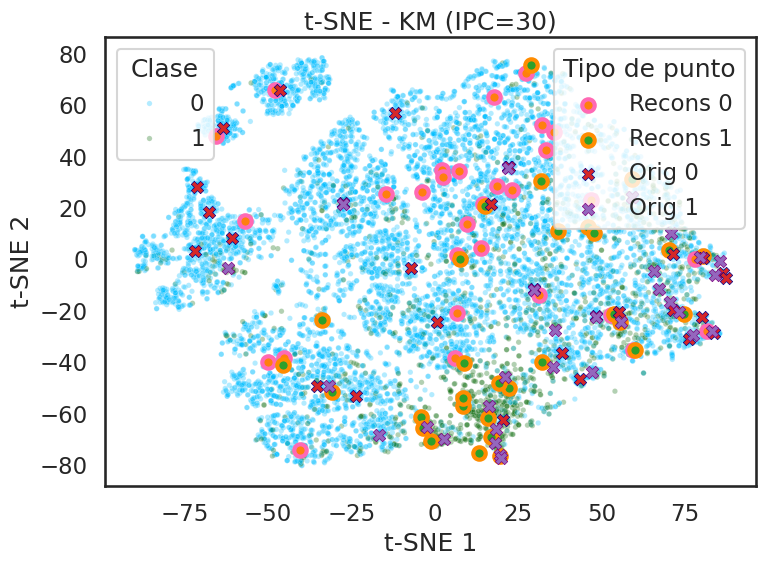

In [35]:
# Observar visualmente las muestras destiladas en el espacio original y latente para KMEANS
hyperparams_vae_path = 'tune_vae/tune_vae_AAC/tune_shoppers/best_hyperparams.json'

X_original, y = X_train_pre,  y_train_pre
Z = load_latent(5, False, z_root_path)

plot_kmeans_distill_and_reconstruct_tsne_seaborn(
    X_original=X_original,
    Z=Z,
    y=y,
    ipc=30,
    seed=5,
    metadata_path=metadata_path,
    vae_dir='results/checkpoint/checkpoint_shoppers_Dlatent_F/vae/',
    device='cuda',
    num_scaler=num_scaler,
    cat_encoder=cat_encoder,
    label_encoder=label_encoder,
    concat_label=False,
    hyperparams_vae_path=hyperparams_vae_path,
    figname='results/explainability_latent_effect/tsne_kmeans_distillation.png',
    method='KM'
)

Figura guardada en: results/explainability_latent_effect/tsne_AG_distillation.png


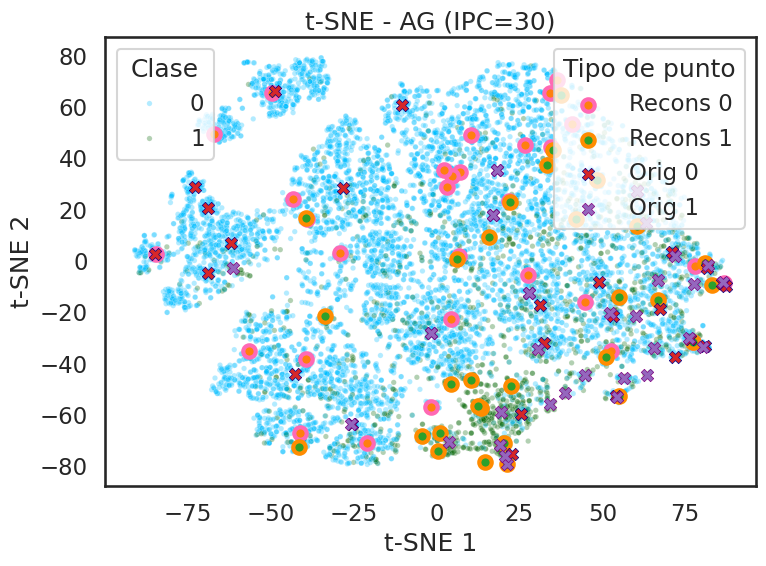

In [36]:
# Observar visualmente las muestras destiladas en el espacio original y latente para Agglomerative Clustering

plot_kmeans_distill_and_reconstruct_tsne_seaborn(
    X_original=X_original,
    Z=Z,
    y=y,
    ipc=30,
    seed=5,
    metadata_path=metadata_path,
    vae_dir='results/checkpoint/checkpoint_shoppers_Dlatent_F/vae/',
    device='cuda',
    num_scaler=num_scaler,
    cat_encoder=cat_encoder,
    label_encoder=label_encoder,
    concat_label=False,
    hyperparams_vae_path=hyperparams_vae_path,
    figname='results/explainability_latent_effect/tsne_AG_distillation.png',
    method='AG'
)

Figura guardada en: results/explainability_latent_effect/tsne_LC_distillation.png


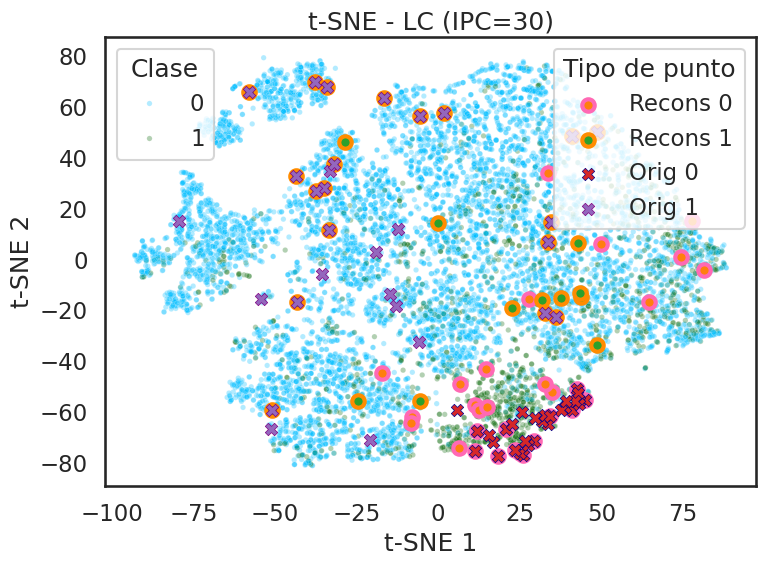

In [37]:
# Observar visualmente las muestras destiladas en el espacio original y latente para least confidence

plot_kmeans_distill_and_reconstruct_tsne_seaborn(
    X_original=X_original,
    Z=Z,
    y=y,
    ipc=30,
    seed=5,
    metadata_path=metadata_path,
    vae_dir='results/checkpoint/checkpoint_shoppers_Dlatent_F/vae/',
    device='cuda',
    num_scaler=num_scaler,
    cat_encoder=cat_encoder,
    label_encoder=label_encoder,
    concat_label=False,
    hyperparams_vae_path=hyperparams_vae_path,
    figname='results/explainability_latent_effect/tsne_LC_distillation.png',
    method='LC'
)

Figura guardada en: results/explainability_latent_effect/tsne_KC_distillation.png


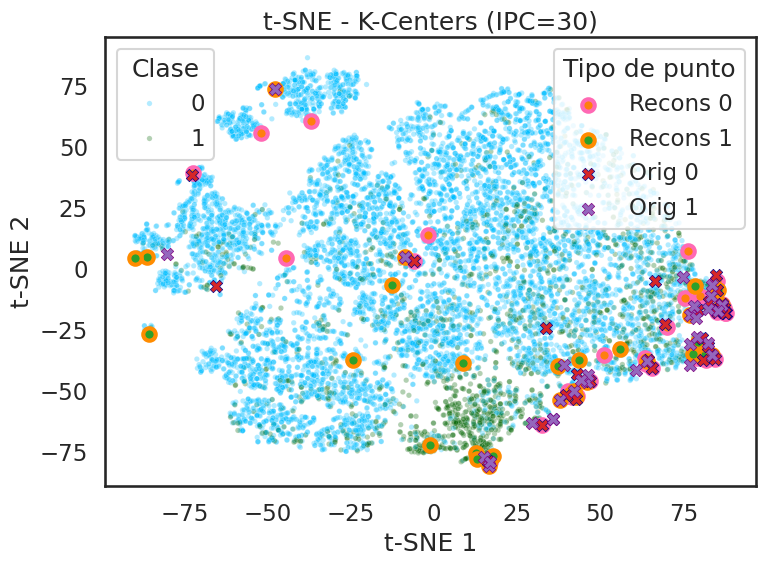

In [38]:
# Observar visualmente las muestras destiladas en el espacio original y latente para K-Centers

plot_kmeans_distill_and_reconstruct_tsne_seaborn(
    X_original=X_original,
    Z=Z,
    y=y,
    ipc=30,
    seed=5,
    metadata_path=metadata_path,
    vae_dir='results/checkpoint/checkpoint_shoppers_Dlatent_F/vae/',
    device='cuda',
    num_scaler=num_scaler,
    cat_encoder=cat_encoder,
    label_encoder=label_encoder,
    concat_label=False,
    hyperparams_vae_path=hyperparams_vae_path,
    figname='results/explainability_latent_effect/tsne_KC_distillation.png',
    method='K-Centers'
)